# CUTEst

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from data.CUTEst.check_CUTEst_problems import problemsToRun
from qnlab.experiment.for_cutest_run import (
    CUTEstTask,
    load_npz_with_metadata,
    run_tasks,
)
from qnlab.experiment.for_cutest_vis import draw_data_profile, draw_pp
from qnlab.util.method import COLORS, LINE_STYLES, Method, get_methods

## Experiment workflow

This single workflow covers the floating-point experiments and all explicit-noise experiments reported in the paper. Results are stored under `data/temp/<scenario>/seed_<seed>/`. With `OVERWRITE_EXISTING = False`, existing result files are kept and only missing tasks are run, so an interrupted experiment can be continued. With `OVERWRITE_EXISTING = True`, every selected task is rerun and its existing result is replaced; use this after changing solver settings or implementation details so that incompatible old and new results are not mixed. A full run is long-running.

In [2]:
working_directory = Path.cwd().resolve()
if (working_directory / "pyproject.toml").exists():
    repository_root = working_directory
elif (working_directory.parent / "pyproject.toml").exists():
    repository_root = working_directory.parent
else:
    raise RuntimeError("Open this notebook from the repository root or notebooks/.")
os.chdir(repository_root)
print(repository_root)

/home/hirok/University/qnlab


In [3]:
PRECISION_FUNCTION_ERRORS = {
    64: np.finfo(np.float64).eps * 1e7,
    32: np.finfo(np.float32).eps * 1e4,
    16: np.finfo(np.float16).eps * 1e2,
}

SCENARIOS = {
    "float64": {
        "precision": 64,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[64],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float32": {
        "precision": 32,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[32],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float16": {
        "precision": 16,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[16],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    # Theory-aligned experiment: the gradient oracle is exact.
    "function_only": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    # Deliberately adverse stress test outside the exact-gradient theorem.
    "joint_noise": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 1e-3,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_under": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-4,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_nominal": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_over": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-1,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
}

# SAFETY: the checked-in default is an intentionally tiny pilot, never the full suite.
MEMORY_SIZE = 10
OFFO_SQUARED_OFFSET = 1e-20
OFFO_THETA = 1.0
RESTART_THRESHOLD = 1.0
MAX_RESTARTS = 10
SCENARIOS_TO_RUN = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_over",
    # "eps_nominal" is unnecessary
]
RESULT_SCENARIO_ALIASES = {"eps_nominal": "function_only"}
NOISY_SEEDS = list(range(5))
NOISY_SEEDS = NOISY_SEEDS[:1]  # Pilot: comment out this line for all five seeds.
PROBLEMS_TO_RUN = 50
METHODS_TO_RUN = None
TIME_LIMIT = 600.0
MAX_ITERATIONS = 1500
OVERWRITE_EXISTING = False
ERROR_CAUSING_TASKS = [
    (16, "INDEFM", "SciPy"),
    (16, "INDEFM", "NTRQN"),
    (16, "INDEFM", "NTRQN-MS"),
    (16, "INDEFM", "Reg-Sec"),
    (16, "OSCIGRAD", "NTRQN-MS"),
    (32, "INDEFM", "NTRQN"),
    (32, "INDEFM", "NTRQN-MS"),
    (32, "OSCIGRAD", "NTRQN-MS"),
]

## Methods and execution


In [4]:
STANDARD_LABELS = {
    "NTRQN",
    "NTRQN-MS",
    "Line",
    "Line-MS",
    "OFFO",
    "Reg",
    "Reg-Sec",
    "SciPy",
    "NTQN",
}
SCENARIO_DEFAULT_LABELS = {
    "function_only": STANDARD_LABELS
    | {"NTRQN-OFFO", "NTRQN-Restart", "NTQN-Default-Termination"},
    "joint_noise": STANDARD_LABELS | {"NTQN-Default-Termination"},
    "eps_under": {"NTRQN", "NTRQN-MS"},
    "eps_nominal": {"NTRQN", "NTRQN-MS"},
    "eps_over": {"NTRQN", "NTRQN-MS"},
}
for scenario in ("float64", "float32", "float16"):
    SCENARIO_DEFAULT_LABELS[scenario] = STANDARD_LABELS

In [5]:
def get_experiment_methods(max_iterations, solver_gtol=None):
    common = {"m": MEMORY_SIZE, "max_iterations": max_iterations}
    methods = [
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
            },
        ),
        (
            Method("NTRQN", "cautious", "damped_modified", "bfgs", label="NTRQN-MS"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
            },
        ),
        (Method("Line", "raw", "raw", "bfgs", label="Line"), common),
        (
            Method("Line", "raw", "modified", "bfgs", label="Line-MS"),
            common,
        ),
        (Method("Kanzow", "raw", "raw", "bfgs", label="Reg"), common),
        (
            Method("KanzowSec", "raw", "raw", "bfgs", label="Reg-Sec"),
            common,
        ),
        (
            Method("SciPy", scipy_method="L-BFGS-B", label="SciPy"),
            {"maxcor": MEMORY_SIZE, "maxiter": max_iterations, "ftol": 0},
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN"),
            common | {"terminate": 1, "stop_at_gtol": 1},
        ),
        # (
        #     Method("OFFO", label="OFFO"),
        #     {
        #         "max_iterations": max_iterations,
        #         "offo_squared_offset": OFFO_SQUARED_OFFSET,
        #         "theta": OFFO_THETA,
        #     },
        # ),
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN-OFFO"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
                "force_offo": 1,
            },
        ),
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN-Restart"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "restart_threshold": RESTART_THRESHOLD,
                "max_restarts": MAX_RESTARTS,
            },
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN-Default-Termination"),
            common | {"terminate": 3, "stop_at_gtol": 0},
        ),
    ]
    if solver_gtol is not None:
        methods = [
            (method, option | {"gtol": solver_gtol}) for method, option in methods
        ]
    return methods


def get_scenario_seeds(scenario):
    config = SCENARIOS[scenario]
    has_noise = config["function_noise"] > 0.0 or config["gradient_noise"] > 0.0
    return NOISY_SEEDS if has_noise else [0]


def make_task(scenario, seed, problem_name, method, options):
    config = SCENARIOS[scenario]
    assumed_error = config["assumed_function_error"]
    return CUTEstTask(
        problem_name=problem_name,
        method=method,
        options=options,
        precision=config["precision"],
        function_noise=np.float64(config["function_noise"]),
        gradient_noise=np.float64(config["gradient_noise"]),
        assumed_function_error=(
            None if assumed_error is None else np.float64(assumed_error)
        ),
        seed=seed,
        scenario=scenario,
    )


def result_source(scenario, seed, method):
    source_scenario = RESULT_SCENARIO_ALIASES.get(scenario, scenario)
    assert source_scenario in SCENARIOS, f"Unknown scenario: {source_scenario}"
    source_seed = (
        0
        if method.label == "OFFO"
        and SCENARIOS[source_scenario]["gradient_noise"] == 0.0
        else seed
    )
    return source_scenario, source_seed


def load_scenario_results(scenario, seeds, gtol, labels=None):
    config = SCENARIOS[scenario]
    problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        problems = problems[:PROBLEMS_TO_RUN]
    method_options = get_experiment_methods(MAX_ITERATIONS, config["solver_gtol"])
    labels = labels or METHODS_TO_RUN or SCENARIO_DEFAULT_LABELS[scenario]
    method_options = [entry for entry in method_options if entry[0].label in labels]
    alg_names = [method.label for method, _ in method_options]
    instances = [(seed, problem) for seed in seeds for problem in problems]
    calls = np.full((len(method_options), len(instances)), np.inf)
    dimensions = np.full(len(instances), np.nan)
    metadata = np.empty((len(method_options), len(instances)), dtype=object)
    metadata.fill(None)
    for instance_index, (seed, problem) in enumerate(instances):
        for method_index, (method, options) in enumerate(method_options):
            source_scenario, source_seed = result_source(scenario, seed, method)
            task = make_task(source_scenario, source_seed, problem, method, options)
            callback, run_metadata = load_npz_with_metadata(task, verbose=False)
            metadata[method_index, instance_index] = run_metadata
            if "dimension" in run_metadata:
                dimensions[instance_index] = run_metadata["dimension"]
            reached = np.flatnonzero(np.asarray(callback.gnorms) <= gtol)
            if reached.size > 0:
                calls[method_index, instance_index] = max(1, callback.calls[reached[0]])
    instance_names = [f"{problem} (seed={seed})" for seed, problem in instances]
    return alg_names, calls, instance_names, dimensions, metadata


def summarize_run_metadata(alg_names, metadata):
    rows = []
    for method_index, method in enumerate(alg_names):
        entries = [entry for entry in metadata[method_index] if entry]
        statuses = [entry["status"] for entry in entries]
        return_values = [entry.get("return_code_value") for entry in entries]
        rows.append(
            {
                "method": method,
                "result files": len(entries),
                "missing files": metadata.shape[1] - len(entries),
                "completed": statuses.count("completed"),
                "timeouts": statuses.count("timeout"),
                "exceptions": statuses.count("error"),
                "error return codes": sum(
                    value is not None and value < 0 for value in return_values
                ),
            }
        )
    return pd.DataFrame(rows).set_index("method")


def summarize_diagnostics(alg_names, metadata):
    restart_rows = []
    ntqn_rows = []
    for method_index, method in enumerate(alg_names):
        diagnostics = [
            entry.get("diagnostics", {}) for entry in metadata[method_index] if entry
        ]
        if method == "NTRQN-Restart" and diagnostics:
            counts = np.asarray(
                [entry.get("OFFO accumulator restart", 0) for entry in diagnostics]
            )
            restart_rows.append(
                {
                    "method": method,
                    "mean": counts.mean(),
                    "median": np.median(counts),
                    "maximum": counts.max(),
                    "cap reached": np.count_nonzero(counts >= MAX_RESTARTS),
                }
            )
        for entry in diagnostics:
            if "NTQN termination flag" in entry:
                ntqn_rows.append(
                    {"method": method, "flag": entry["NTQN termination flag"]}
                )
    restart_summary = pd.DataFrame(restart_rows)
    ntqn_summary = (
        pd.crosstab(
            pd.Series([row["method"] for row in ntqn_rows], name="method"),
            pd.Series([row["flag"] for row in ntqn_rows], name="flag"),
        )
        if ntqn_rows
        else pd.DataFrame()
    )
    return restart_summary, ntqn_summary

In [6]:
unknown_scenarios = sorted(set(SCENARIOS_TO_RUN) - set(SCENARIOS))
if unknown_scenarios:
    raise ValueError(f"Unknown scenarios: {unknown_scenarios}")

tasks = []
reused_task_count = 0
for scenario in SCENARIOS_TO_RUN:
    config = SCENARIOS[scenario]
    selected_problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        selected_problems = selected_problems[:PROBLEMS_TO_RUN]
    selected_method_options = get_experiment_methods(
        MAX_ITERATIONS, config["solver_gtol"]
    )
    if METHODS_TO_RUN is not None:
        selected_method_options = [
            entry
            for entry in selected_method_options
            if entry[0].label in METHODS_TO_RUN
        ]
        missing = sorted(
            set(METHODS_TO_RUN) - {entry[0].label for entry in selected_method_options}
        )
        if missing:
            raise ValueError(f"Unknown method labels: {missing}")
    else:
        selected_method_options = [
            entry
            for entry in selected_method_options
            if entry[0].label in SCENARIO_DEFAULT_LABELS[scenario]
        ]
    for seed in get_scenario_seeds(scenario):
        for problem in selected_problems:
            for method, options in selected_method_options:
                source_scenario, source_seed = result_source(scenario, seed, method)
                if (source_scenario, source_seed) != (scenario, seed):
                    reused_task_count += 1
                    continue
                tasks.append(make_task(scenario, seed, problem, method, options))

print(f"Scenarios: {SCENARIOS_TO_RUN}")
print(f"Prepared {len(tasks)} tasks.")
if reused_task_count:
    print(f"Reusing {reused_task_count} equivalent stored results.")

run_tasks(tasks, ERROR_CAUSING_TASKS, int(TIME_LIMIT), overwrite=OVERWRITE_EXISTING)

Scenarios: ['float64', 'float32', 'float16', 'function_only', 'joint_noise', 'eps_under', 'eps_over']
Prepared 2400 tasks.
Total tasks to run: 0


## Visualize saved results

Select scenarios after their runs have completed. The default empty list avoids overwriting existing figures accidentally.

Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-01.pdf


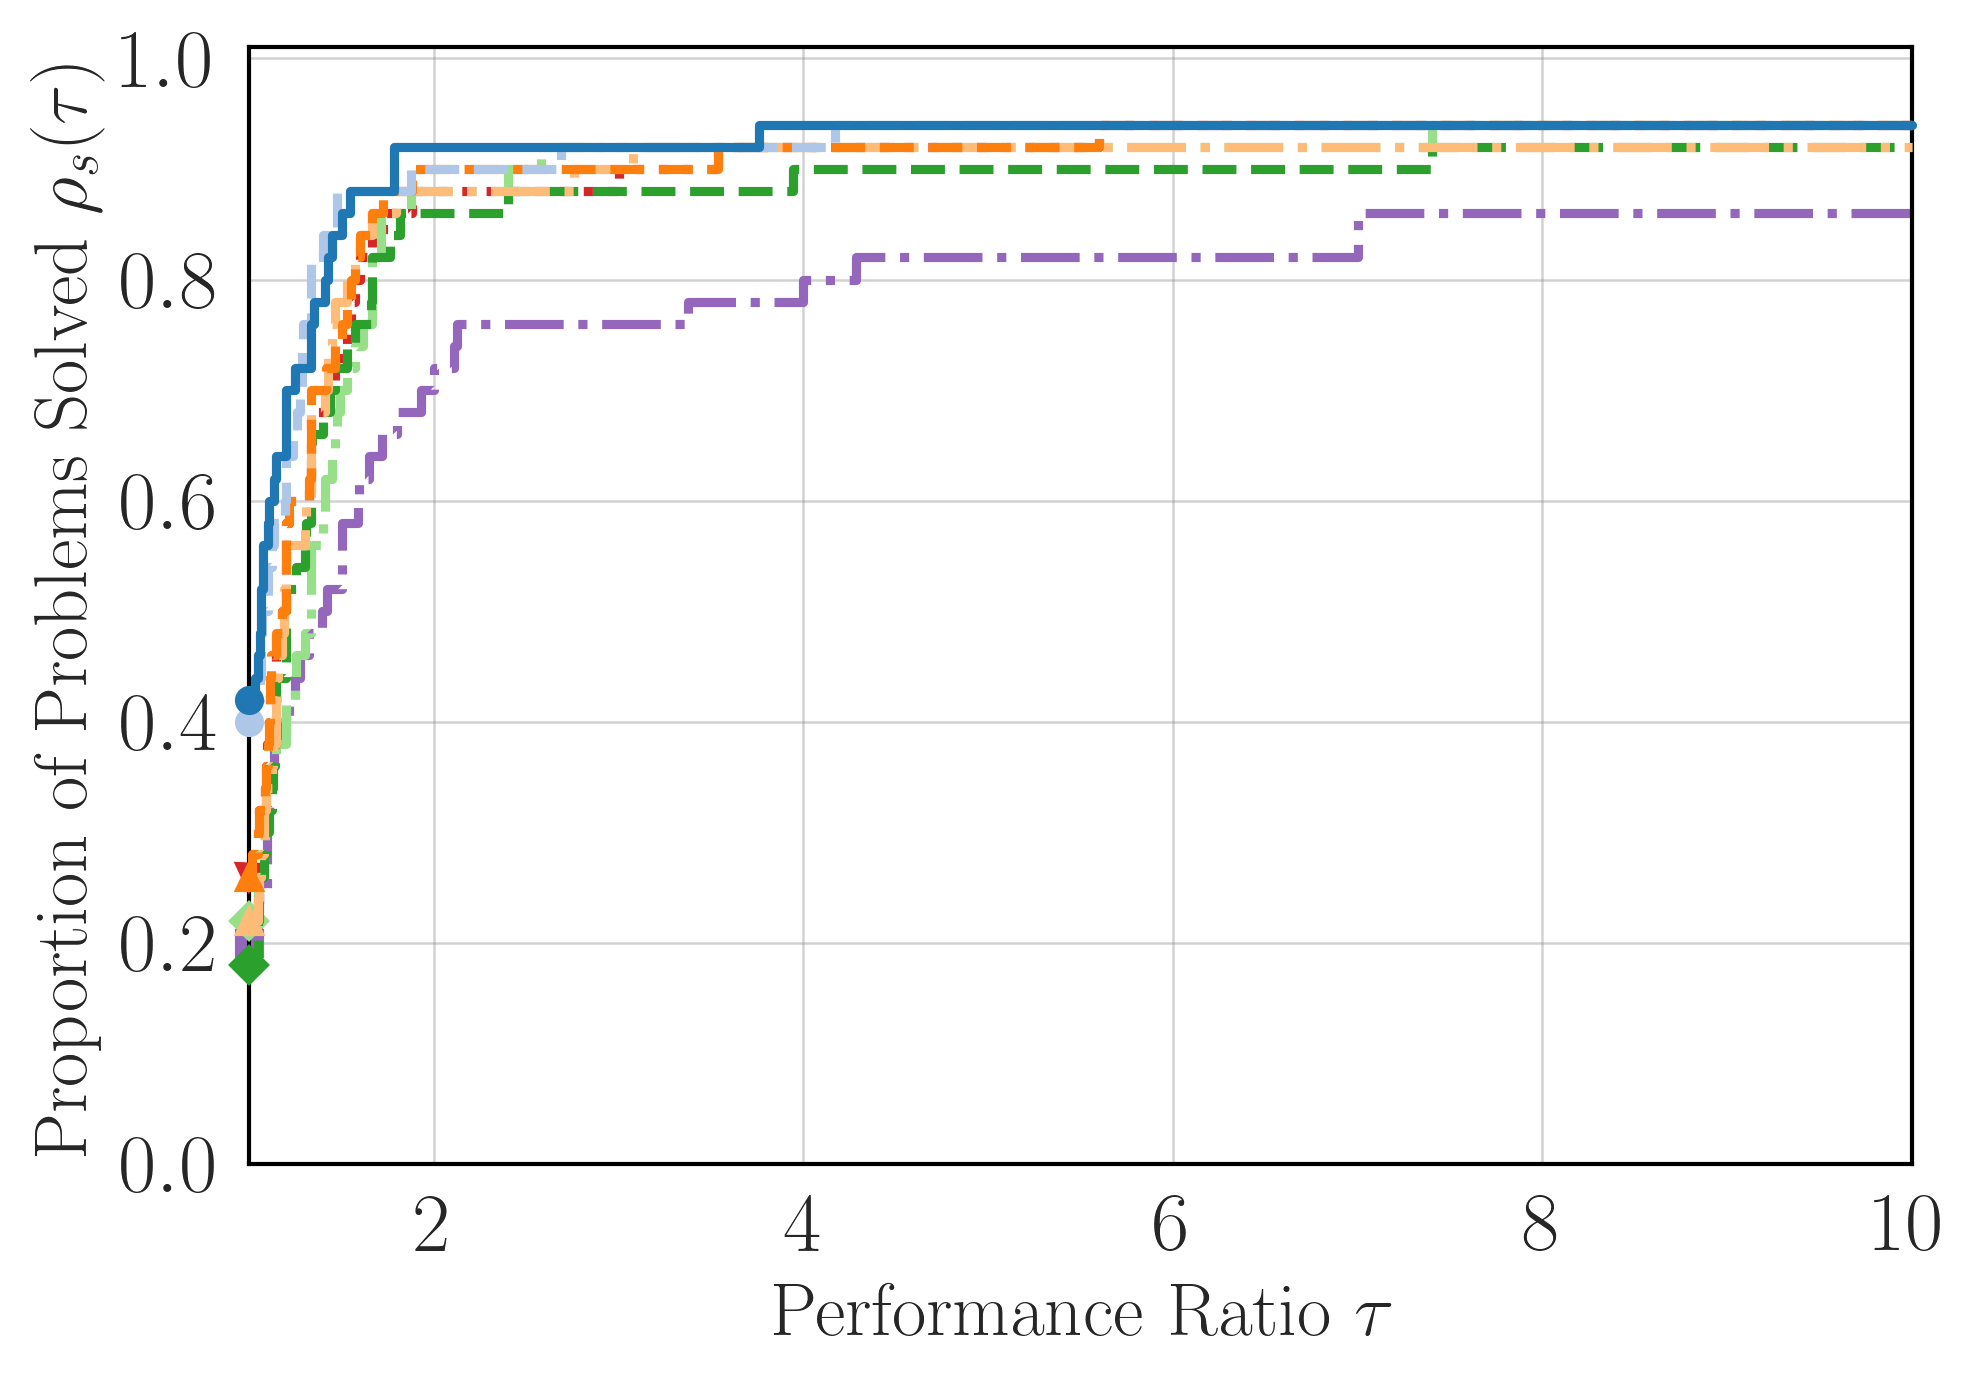

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-01.pdf


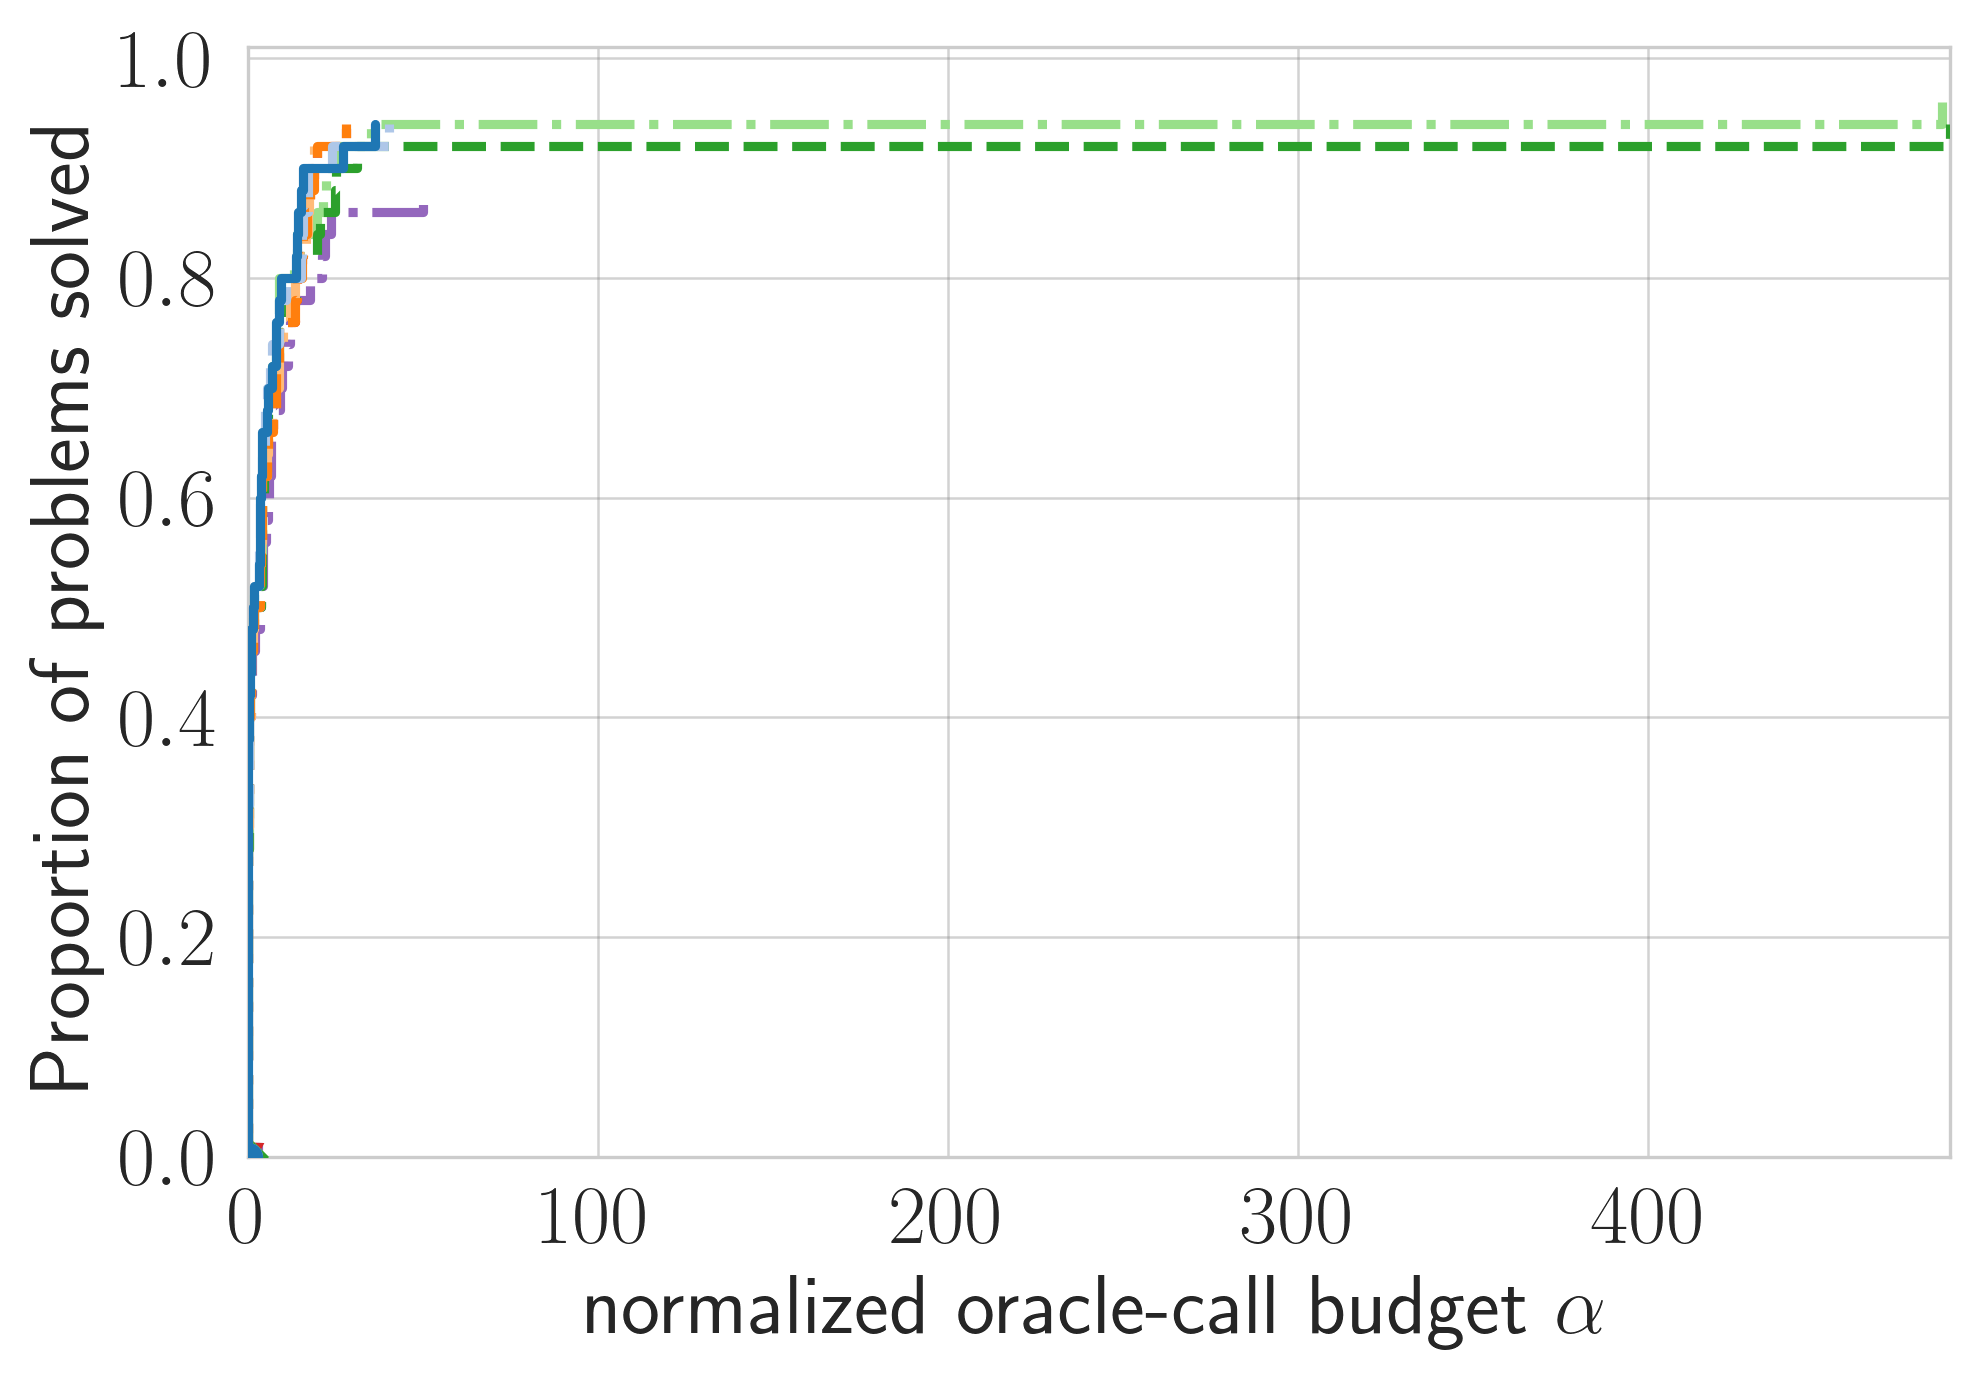

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),45.0,46.0,40.0,36.0,41.0,39.0,40.0,inf
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0
ARGLINB (seed=0),6.0,8.0,8.0,8.0,10.0,10.0,18.0,42.0
ARGLINC (seed=0),6.0,8.0,8.0,8.0,inf,10.0,8.0,42.0
ARGTRIGLS (seed=0),161.0,153.0,168.0,174.0,168.0,152.0,168.0,175.0
ARWHEAD (seed=0),8.0,8.0,8.0,8.0,8.0,8.0,8.0,27.0
BA-L1LS (seed=0),33.0,34.0,32.0,38.0,32.0,32.0,32.0,55.0
BA-L1SPLS (seed=0),42.0,39.0,46.0,44.0,51.0,55.0,46.0,62.0
BARD (seed=0),16.0,12.0,16.0,16.0,16.0,16.0,16.0,24.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,94.0,42.0
NTRQN-MS,94.0,40.0
Line,94.0,26.0
Line-MS,92.0,22.0
Reg,94.0,18.0
Reg-Sec,96.0,22.0
SciPy,94.0,26.0
NTQN,88.0,20.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-MS,50,0,49,1,0,5
Line,50,0,50,0,0,10
Line-MS,50,0,50,0,0,12
Reg,50,0,50,0,0,5
Reg-Sec,50,0,50,0,0,4
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,5


flag,0,1,6
method,,,
NTQN,41,5,4


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-03.pdf


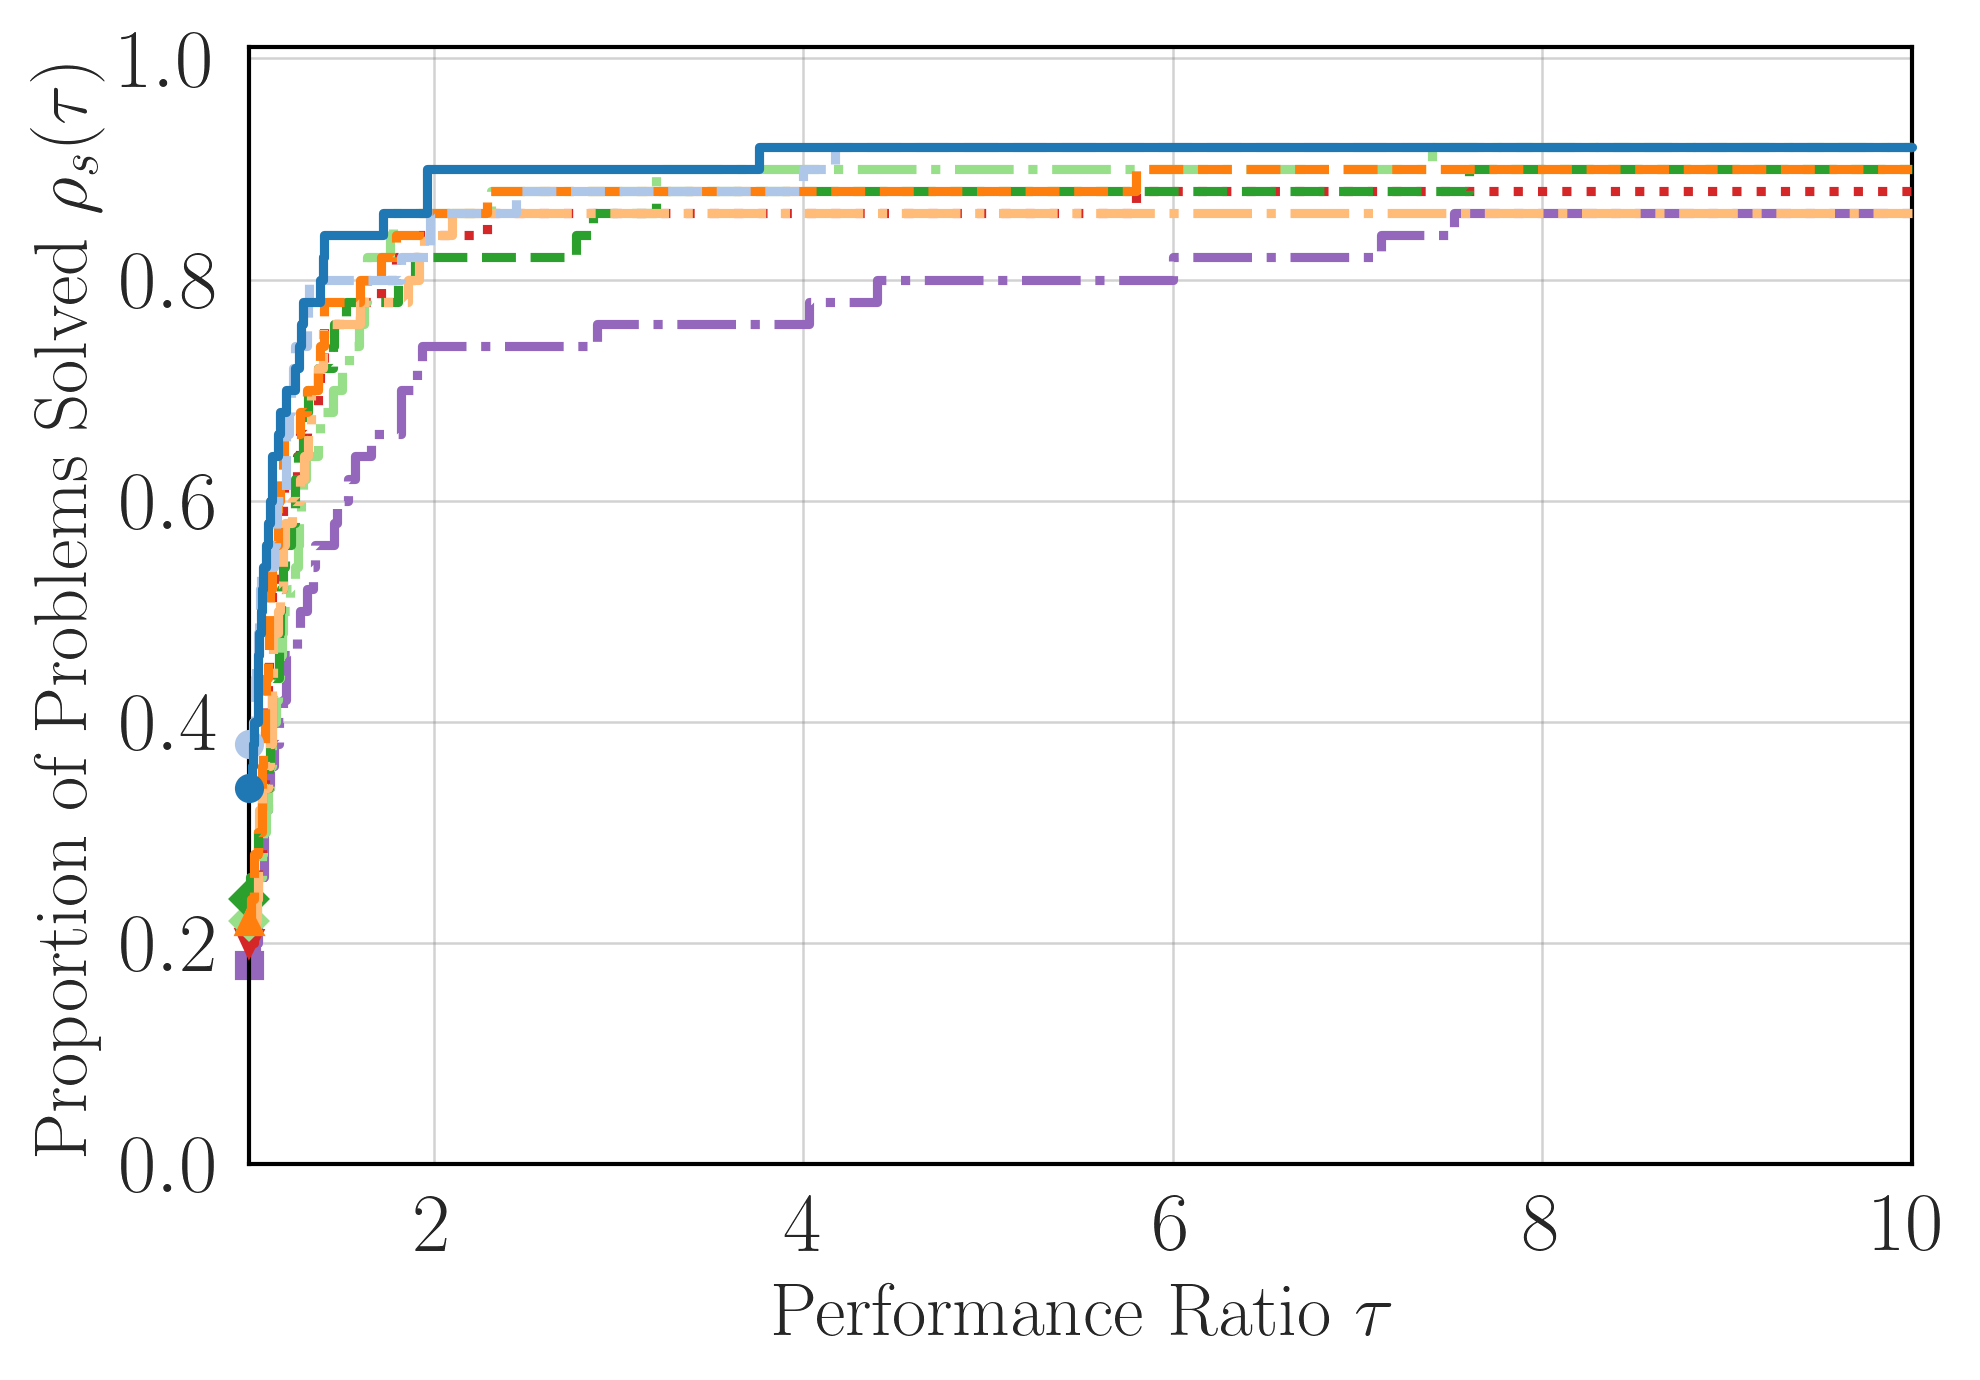

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-03.pdf


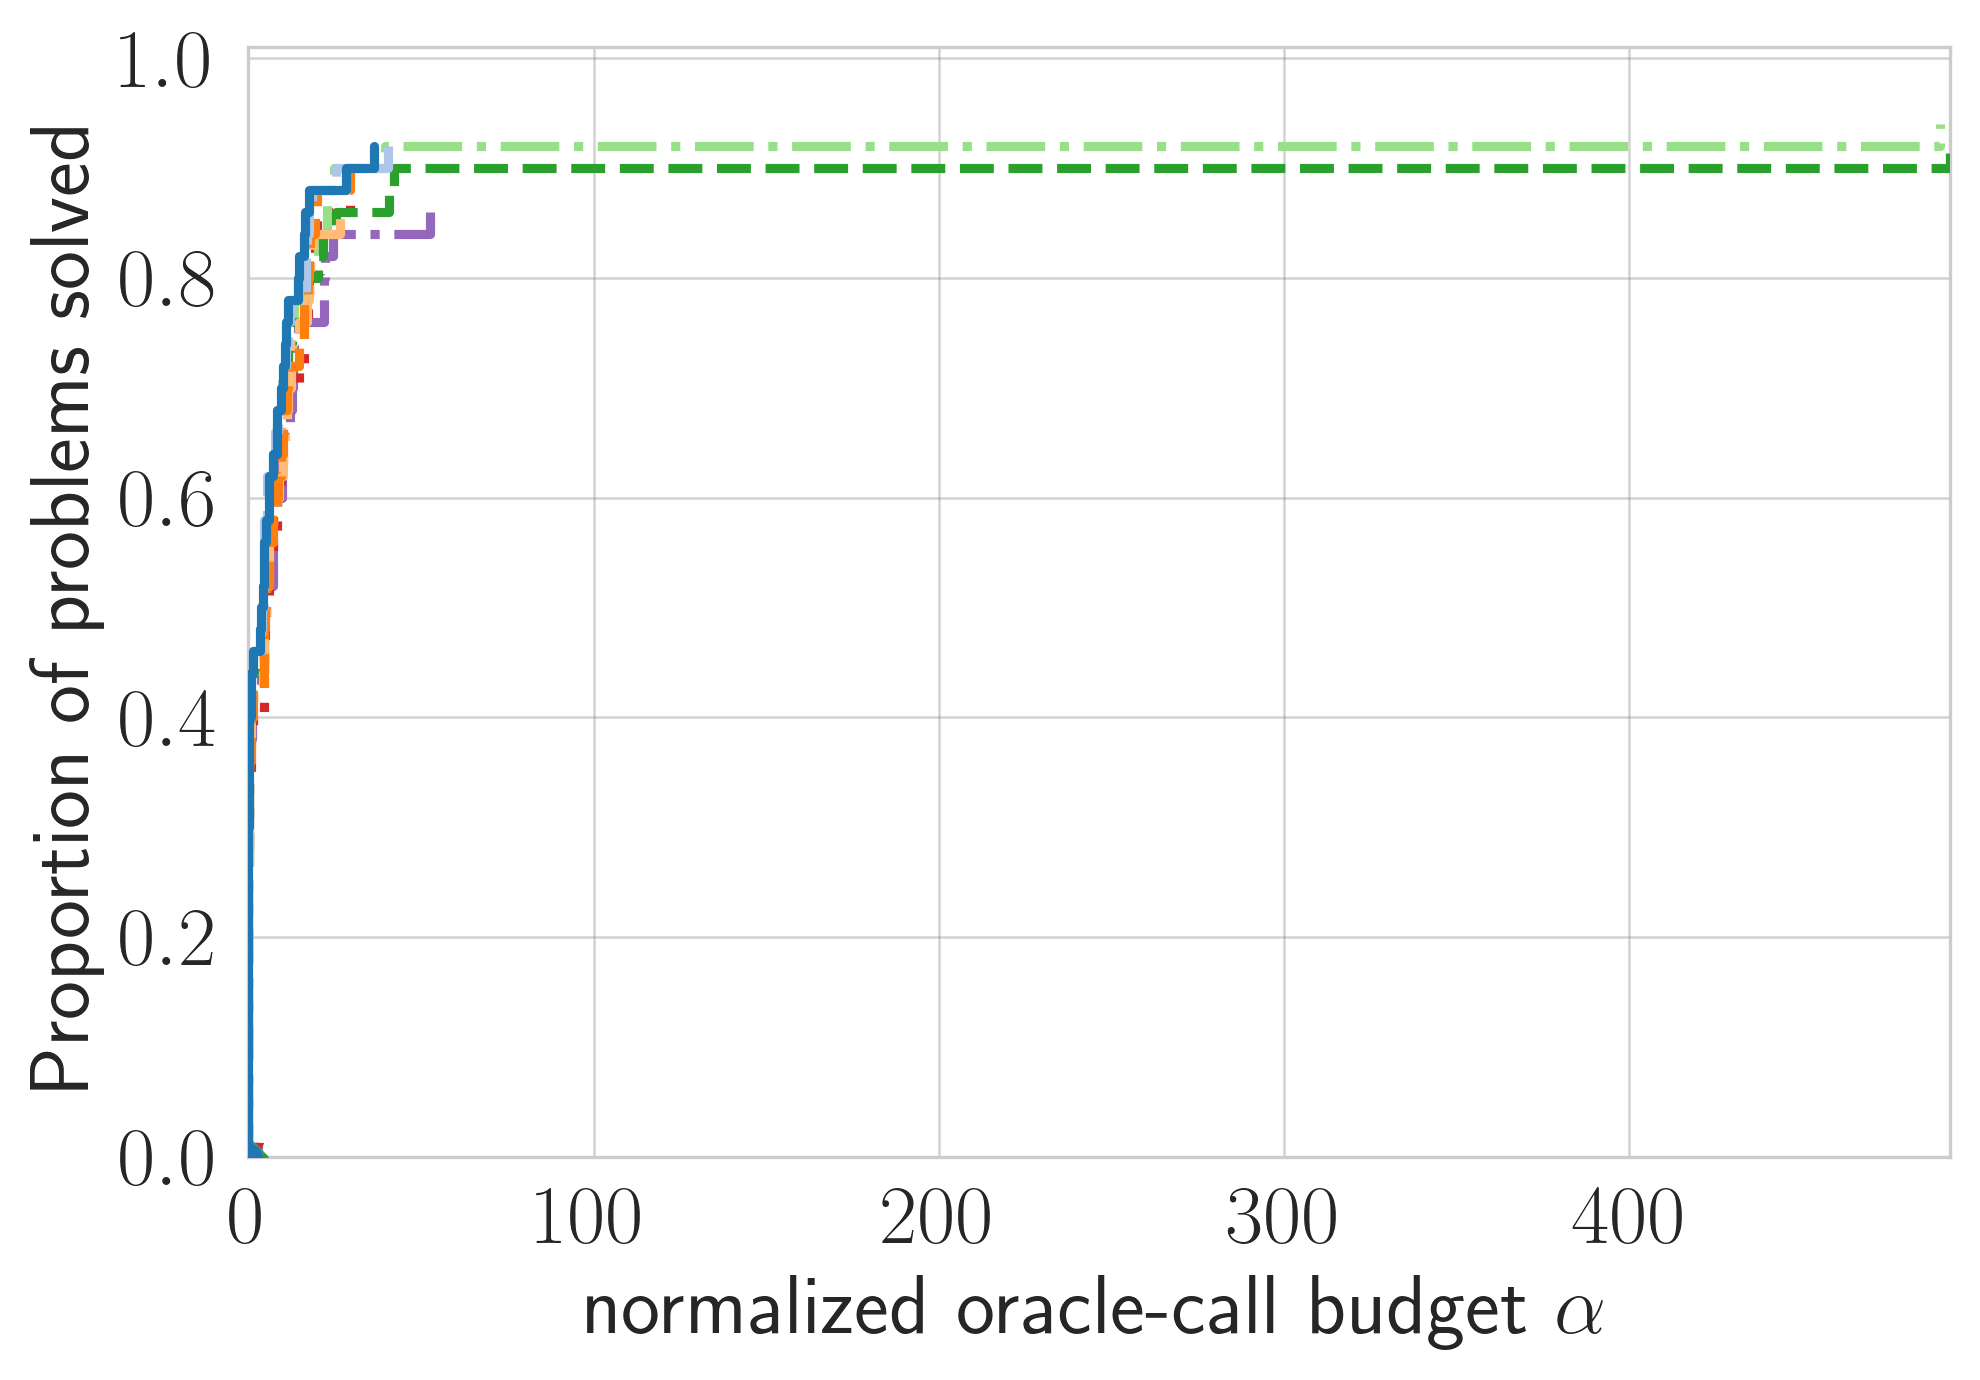

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),49.0,50.0,44.0,38.0,49.0,49.0,44.0,inf
ALLINITU (seed=0),23.0,23.0,24.0,26.0,22.0,24.0,24.0,25.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0
ARGLINB (seed=0),8.0,8.0,inf,inf,10.0,12.0,inf,57.0
ARGLINC (seed=0),14.0,12.0,10.0,10.0,inf,10.0,inf,44.0
ARGTRIGLS (seed=0),878.0,888.0,922.0,860.0,886.0,896.0,934.0,920.0
ARWHEAD (seed=0),28.0,28.0,28.0,28.0,28.0,28.0,28.0,51.0
BA-L1LS (seed=0),41.0,40.0,40.0,44.0,40.0,40.0,40.0,59.0
BA-L1SPLS (seed=0),48.0,49.0,52.0,48.0,59.0,61.0,52.0,70.0
BARD (seed=0),46.0,44.0,46.0,46.0,46.0,46.0,46.0,51.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,92.0,34.0
NTRQN-MS,92.0,38.0
Line,90.0,22.0
Line-MS,86.0,22.0
Reg,92.0,24.0
Reg-Sec,94.0,22.0
SciPy,88.0,20.0
NTQN,86.0,18.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-MS,50,0,49,1,0,5
Line,50,0,50,0,0,10
Line-MS,50,0,50,0,0,12
Reg,50,0,50,0,0,5
Reg-Sec,50,0,50,0,0,4
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,5


flag,0,1,6
method,,,
NTQN,41,5,4


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-05.pdf


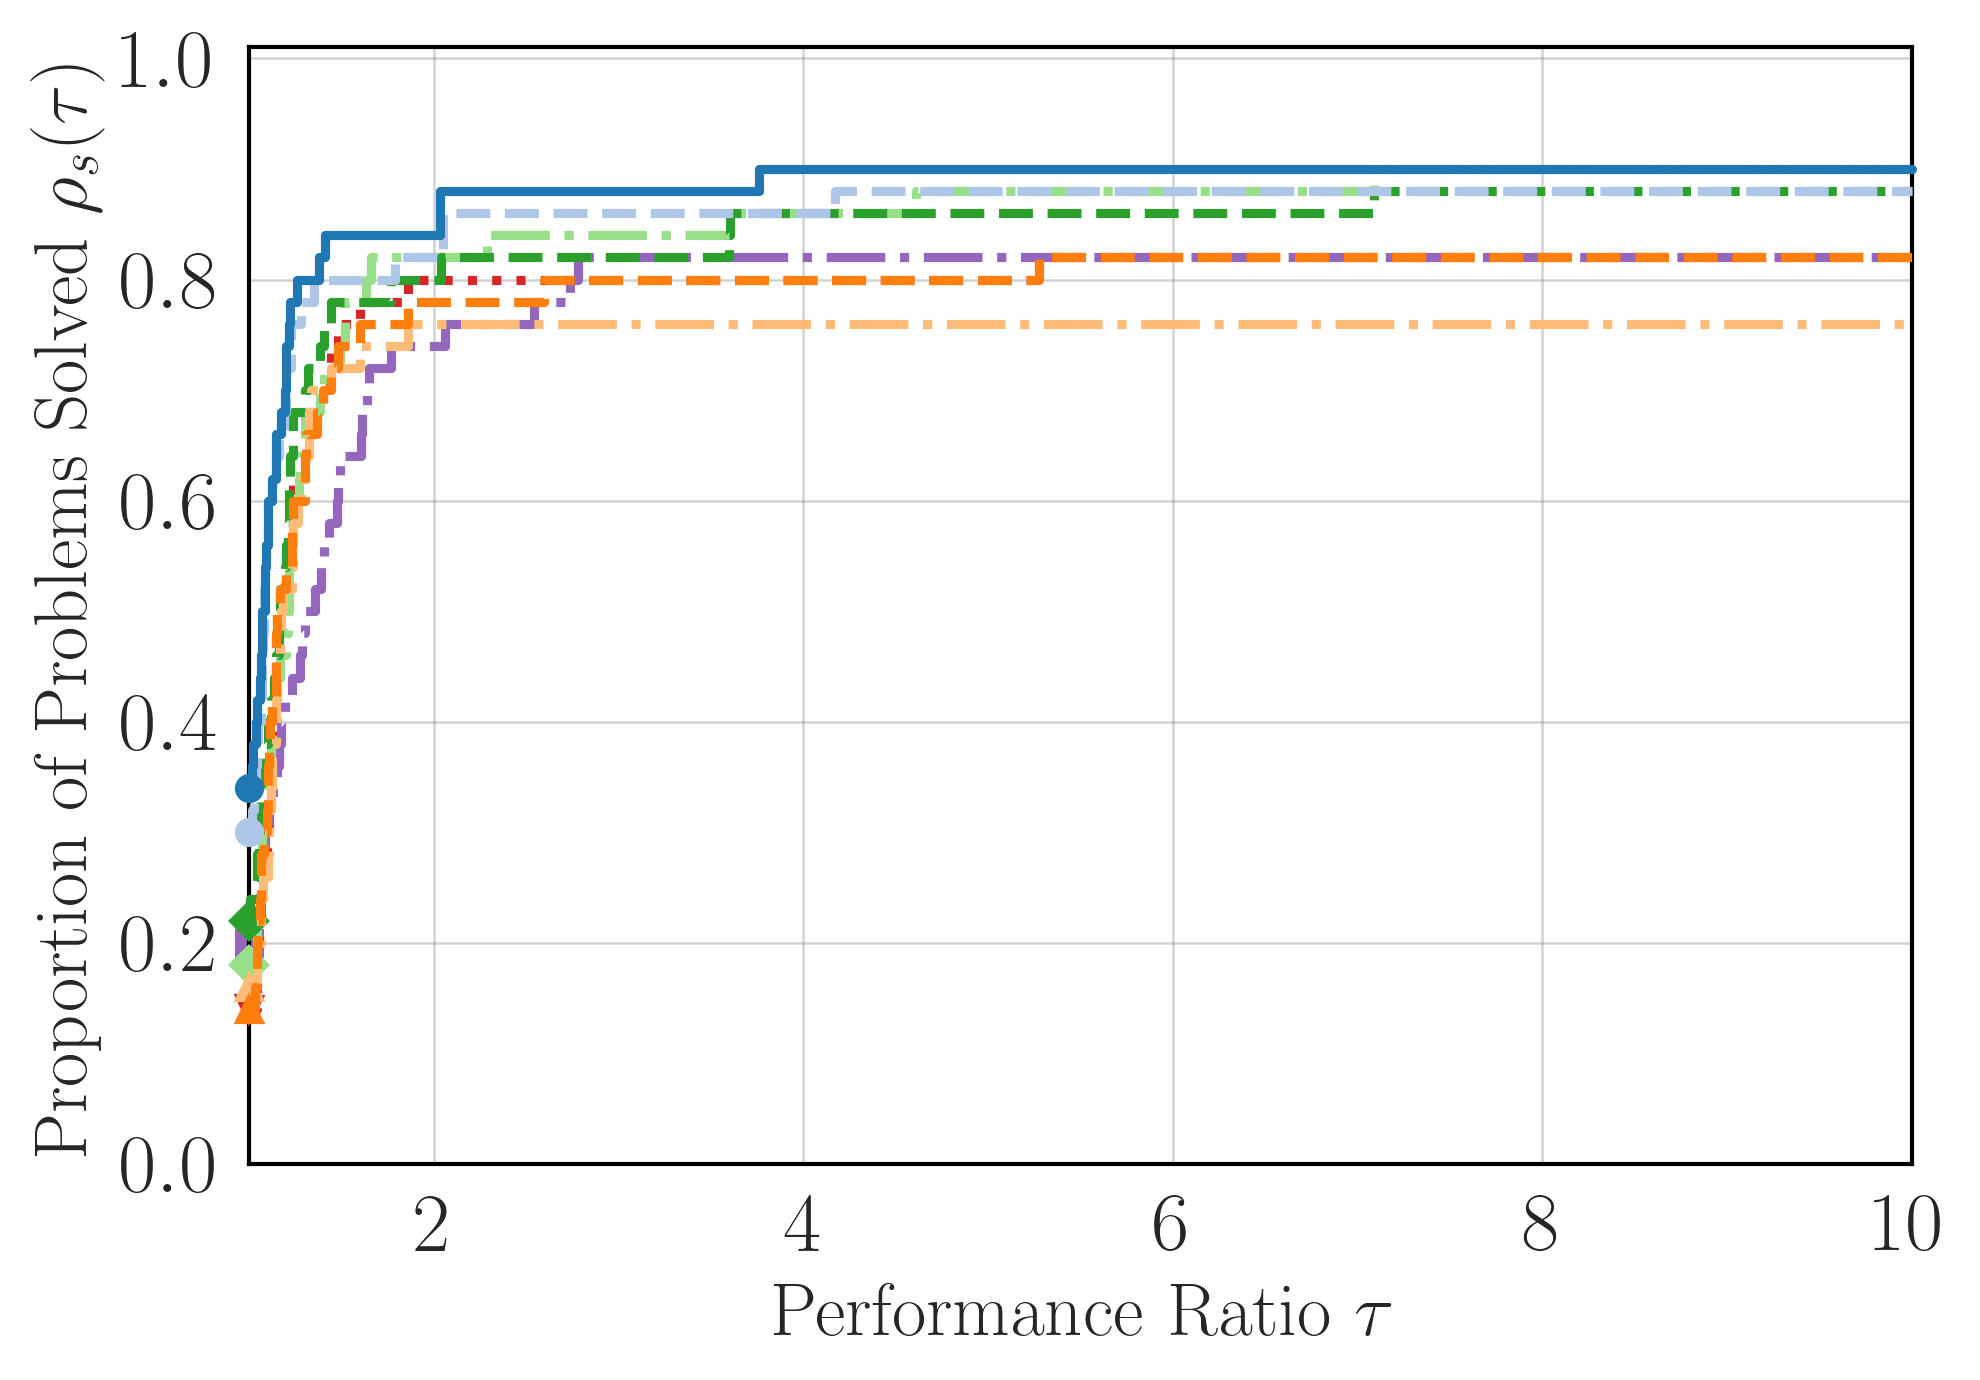

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-05.pdf


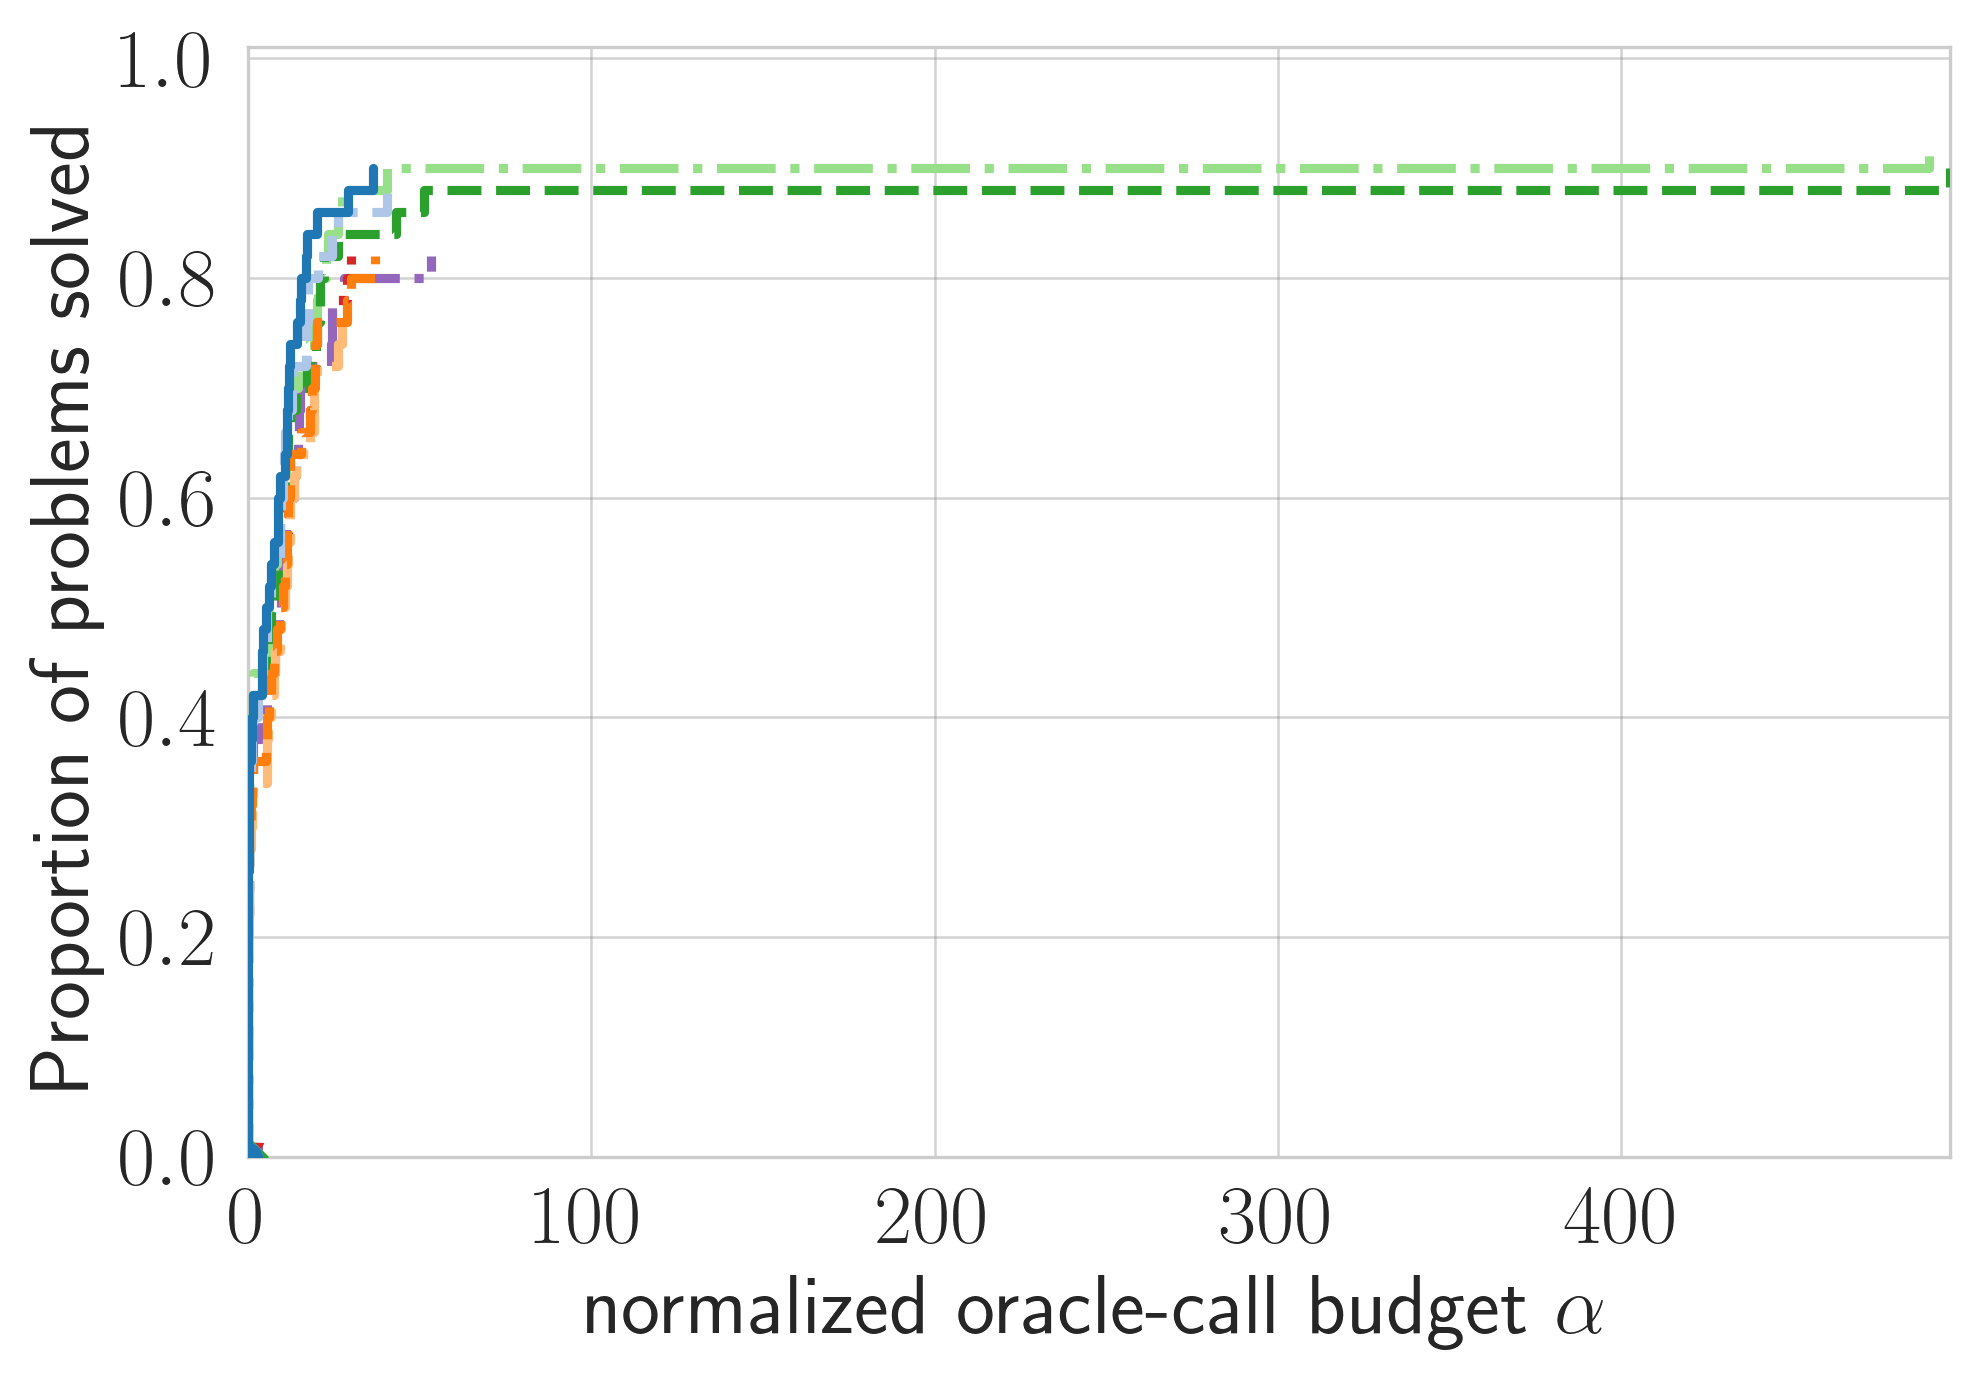

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),51.0,50.0,46.0,42.0,51.0,51.0,46.0,inf
ALLINITU (seed=0),25.0,27.0,26.0,28.0,26.0,26.0,26.0,29.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,18.0,18.0,8.0,5.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,63.0,inf,inf
ARGLINC (seed=0),800.0,580.0,inf,inf,inf,inf,inf,inf
ARGTRIGLS (seed=0),1708.0,1824.0,1658.0,1570.0,1880.0,1666.0,1780.0,1770.0
ARWHEAD (seed=0),32.0,34.0,34.0,34.0,32.0,32.0,34.0,66.0
BA-L1LS (seed=0),49.0,50.0,48.0,50.0,48.0,48.0,48.0,71.0
BA-L1SPLS (seed=0),56.0,57.0,62.0,56.0,67.0,71.0,62.0,76.0
BARD (seed=0),48.0,46.0,48.0,48.0,48.0,48.0,48.0,55.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.0,34.0
NTRQN-MS,88.0,30.0
Line,82.0,14.0
Line-MS,76.0,16.0
Reg,90.0,22.0
Reg-Sec,92.0,18.0
SciPy,82.0,14.0
NTQN,82.0,20.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-MS,50,0,49,1,0,5
Line,50,0,50,0,0,10
Line-MS,50,0,50,0,0,12
Reg,50,0,50,0,0,5
Reg-Sec,50,0,50,0,0,4
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,5


flag,0,1,6
method,,,
NTQN,41,5,4


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-01.pdf


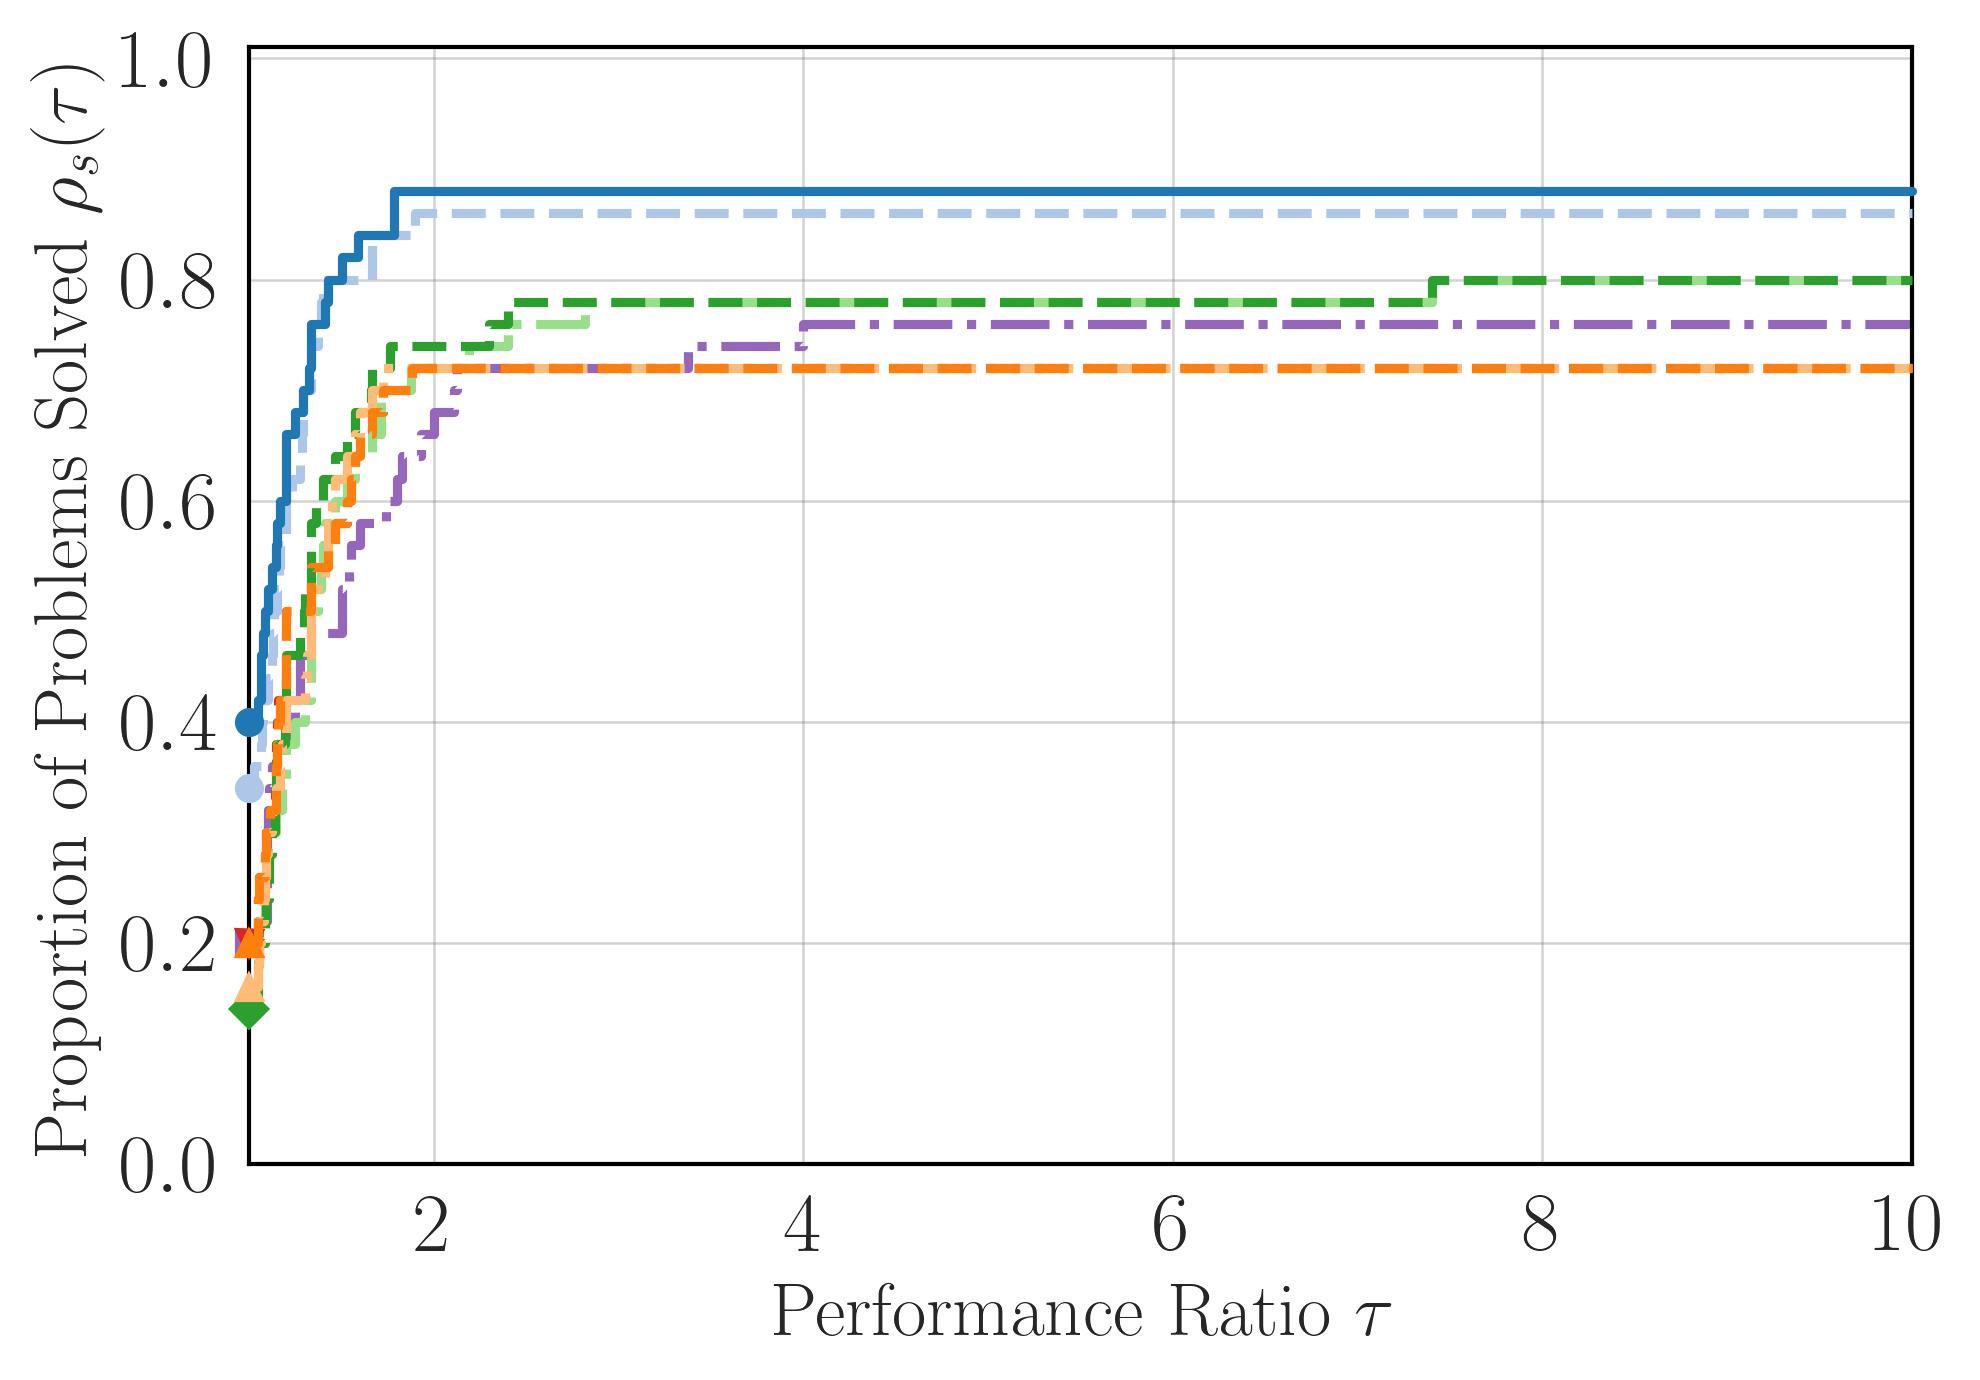

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-01.pdf


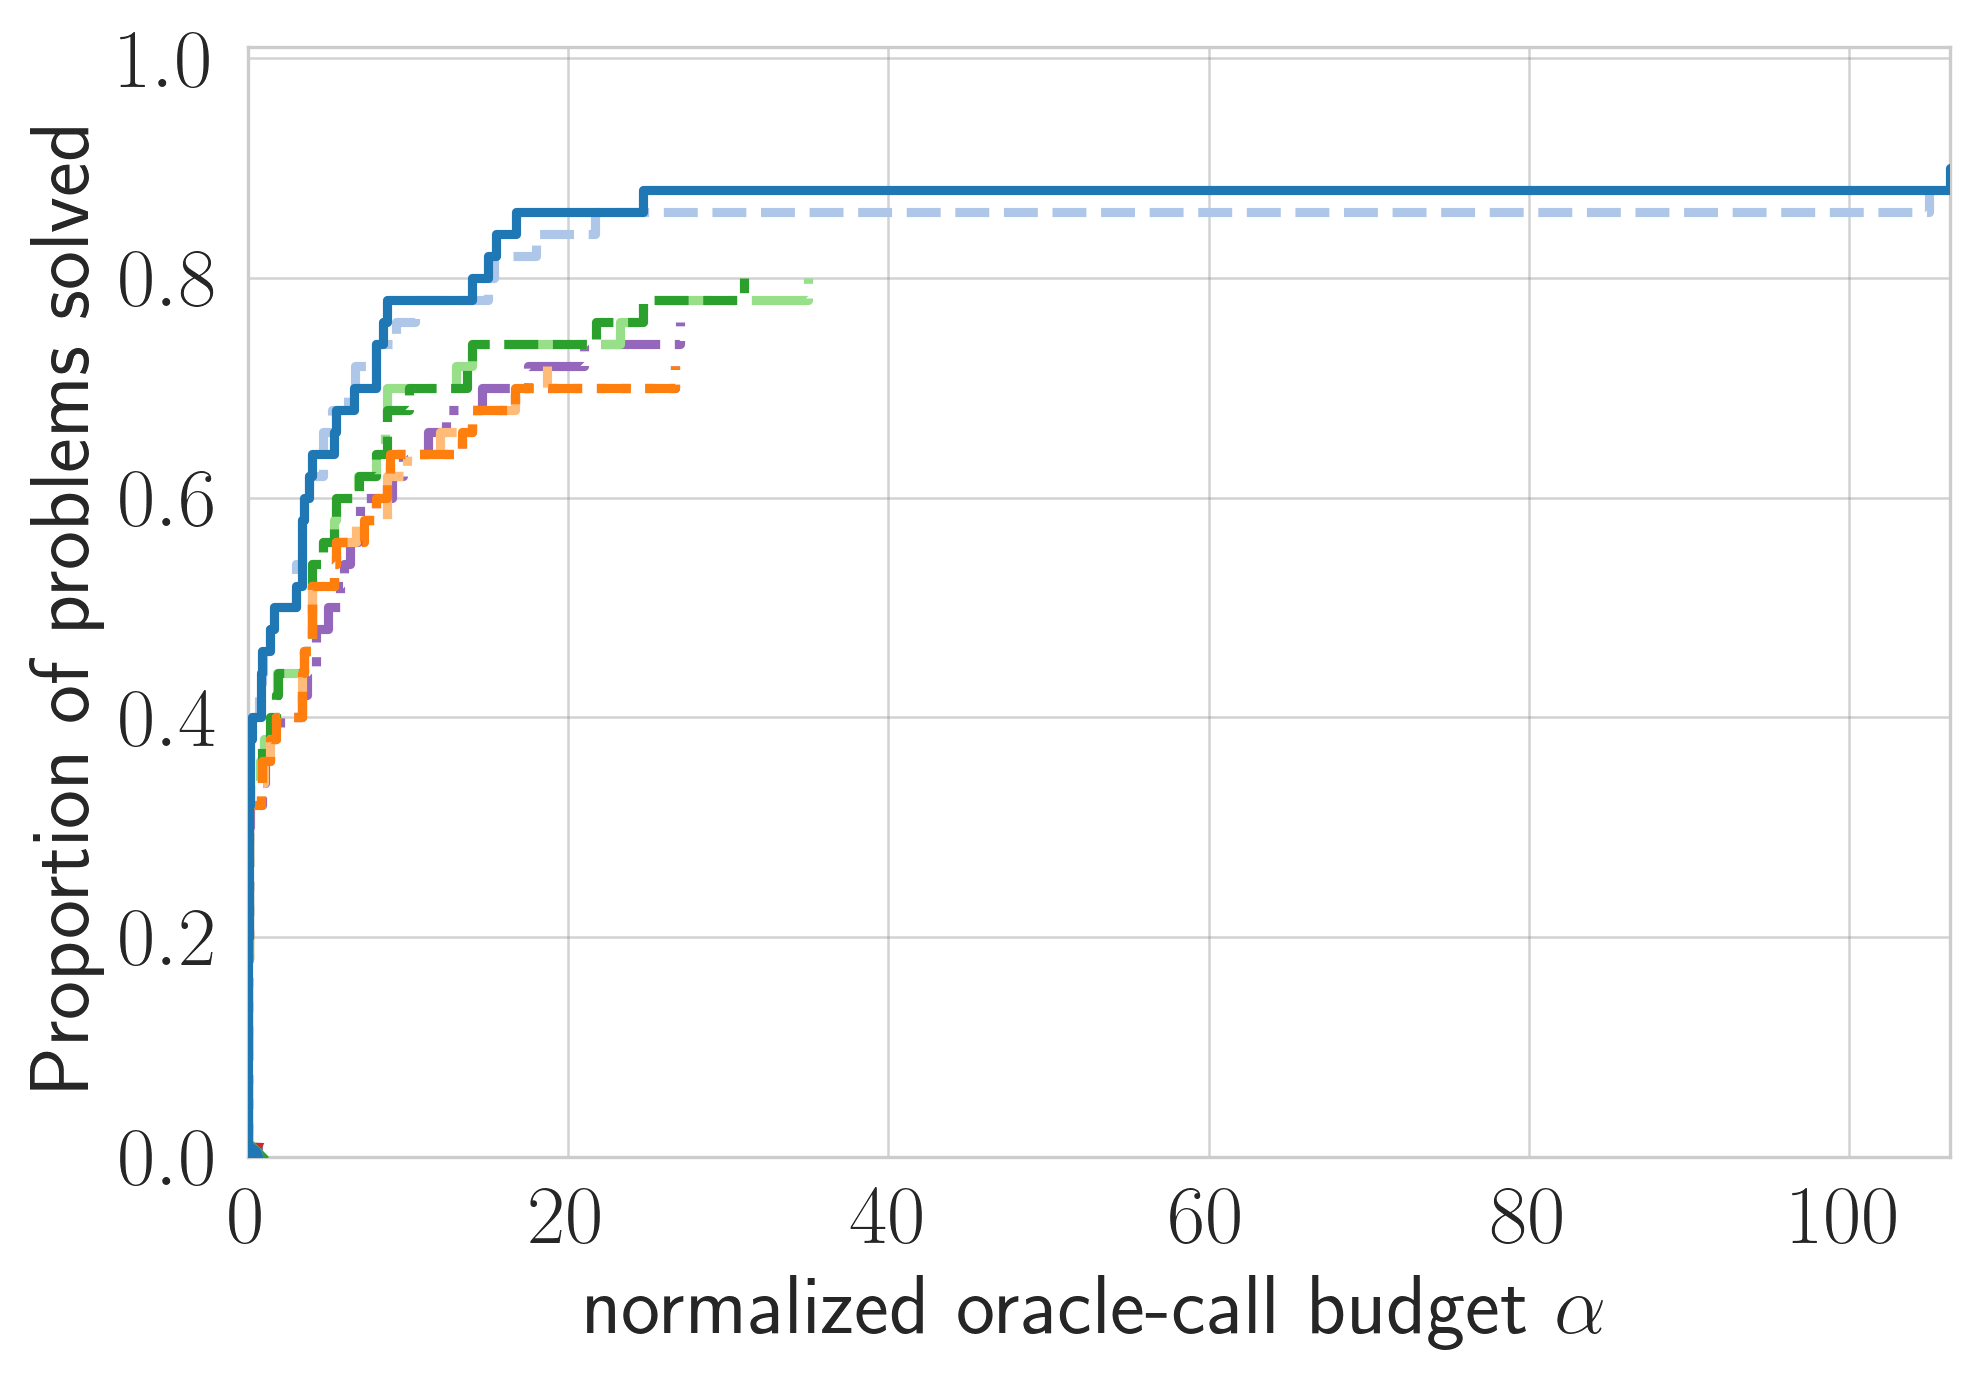

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),45.0,46.0,40.0,36.0,41.0,39.0,40.0,inf
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGTRIGLS (seed=0),177.0,177.0,176.0,200.0,168.0,152.0,176.0,175.0
ARWHEAD (seed=0),8.0,8.0,8.0,8.0,8.0,8.0,8.0,27.0
BA-L1LS (seed=0),47.0,53.0,inf,inf,108.0,103.0,inf,60.0
BA-L1SPLS (seed=0),46.0,40.0,46.0,44.0,51.0,55.0,46.0,62.0
BARD (seed=0),16.0,12.0,16.0,16.0,16.0,16.0,16.0,24.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.0,40.0
NTRQN-MS,88.0,34.0
Line,72.0,20.0
Line-MS,72.0,16.0
Reg,80.0,14.0
Reg-Sec,80.0,14.0
SciPy,72.0,20.0
NTQN,76.0,20.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,49,1,0,16
NTRQN-MS,50,0,49,1,0,18
Line,50,0,50,0,0,33
Line-MS,50,0,50,0,0,33
Reg,50,0,49,0,1,24
Reg-Sec,50,0,50,0,0,26
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,27,2,21


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-03.pdf


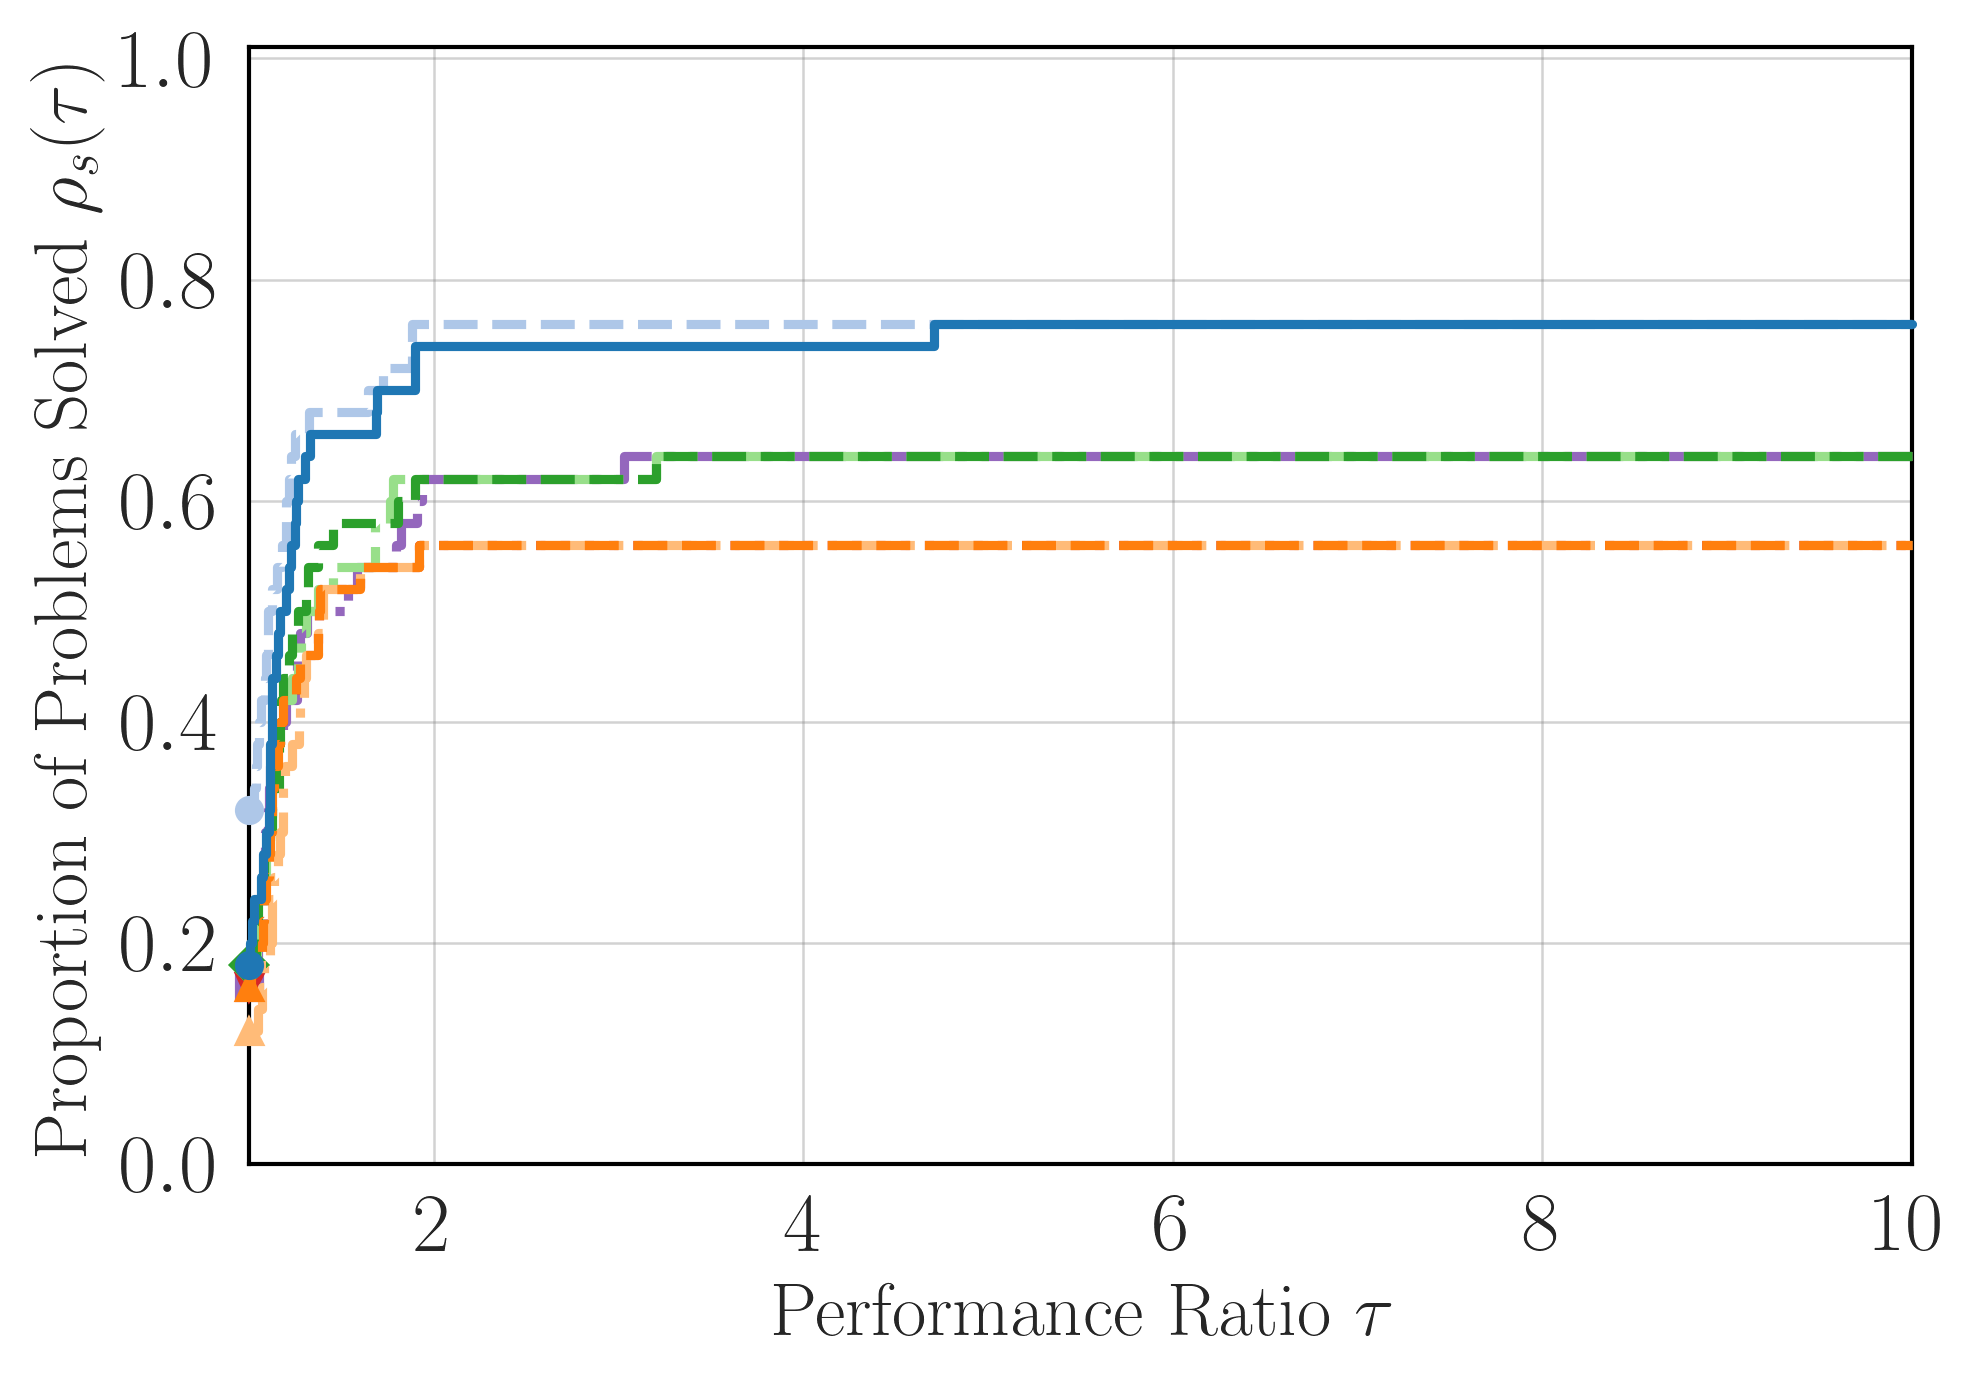

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-03.pdf


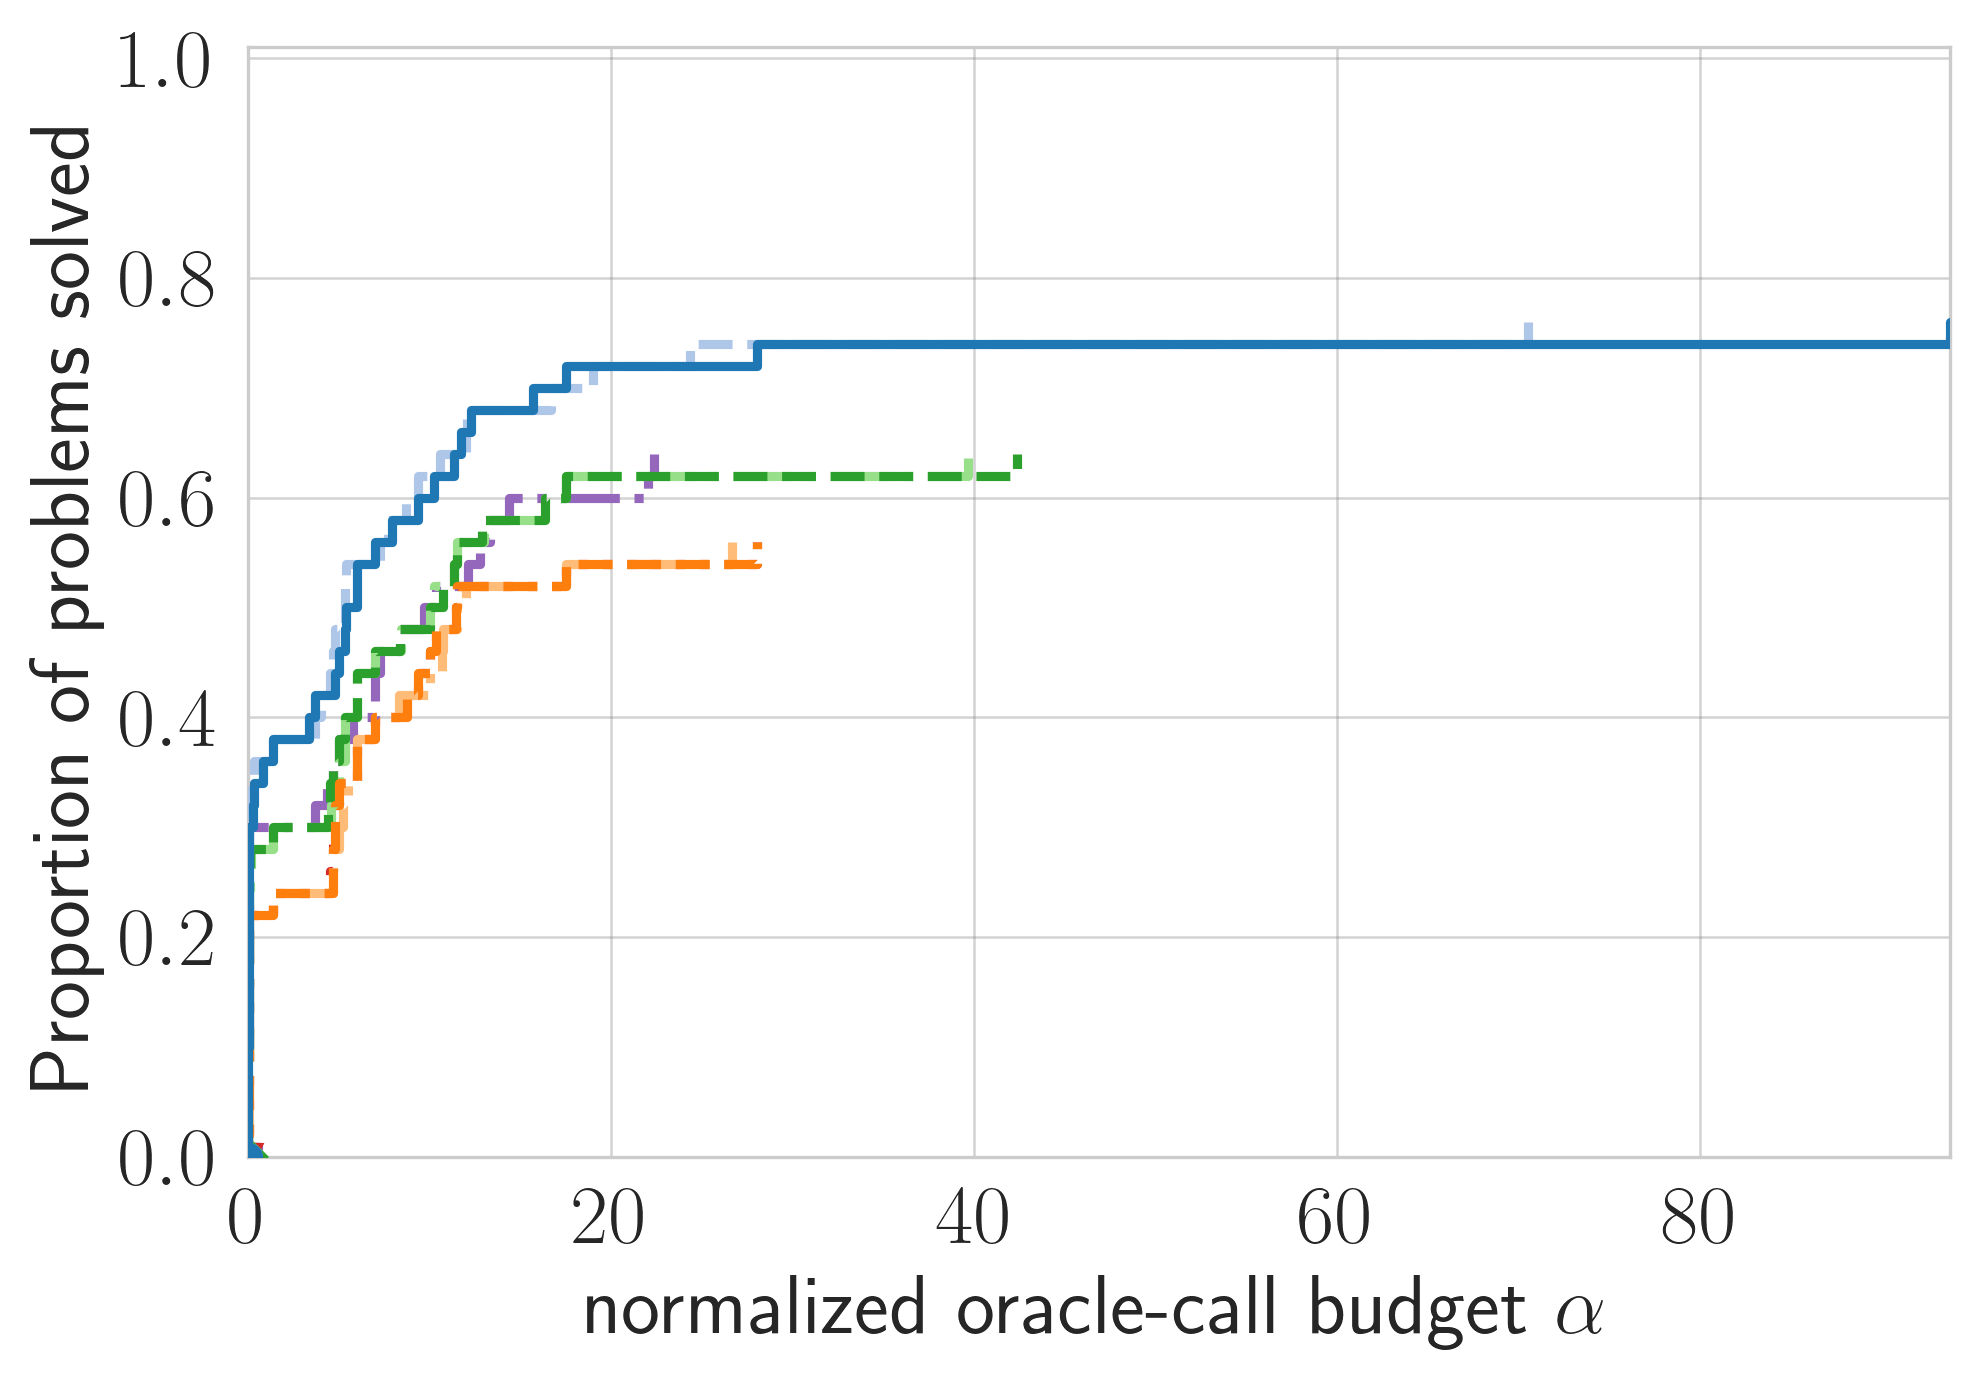

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),47.0,50.0,inf,inf,49.0,49.0,inf,inf
ALLINITU (seed=0),27.0,27.0,24.0,26.0,22.0,24.0,24.0,25.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGTRIGLS (seed=0),963.0,955.0,960.0,1098.0,900.0,914.0,900.0,866.0
ARWHEAD (seed=0),28.0,34.0,28.0,28.0,28.0,28.0,28.0,51.0
BA-L1LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BA-L1SPLS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BARD (seed=0),49.0,48.0,46.0,46.0,46.0,46.0,46.0,51.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,76.0,18.0
NTRQN-MS,76.0,32.0
Line,56.0,16.0
Line-MS,56.0,12.0
Reg,64.0,18.0
Reg-Sec,64.0,18.0
SciPy,56.0,16.0
NTQN,64.0,16.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,49,1,0,16
NTRQN-MS,50,0,49,1,0,18
Line,50,0,50,0,0,33
Line-MS,50,0,50,0,0,33
Reg,50,0,49,0,1,24
Reg-Sec,50,0,50,0,0,26
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,27,2,21


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-05.pdf


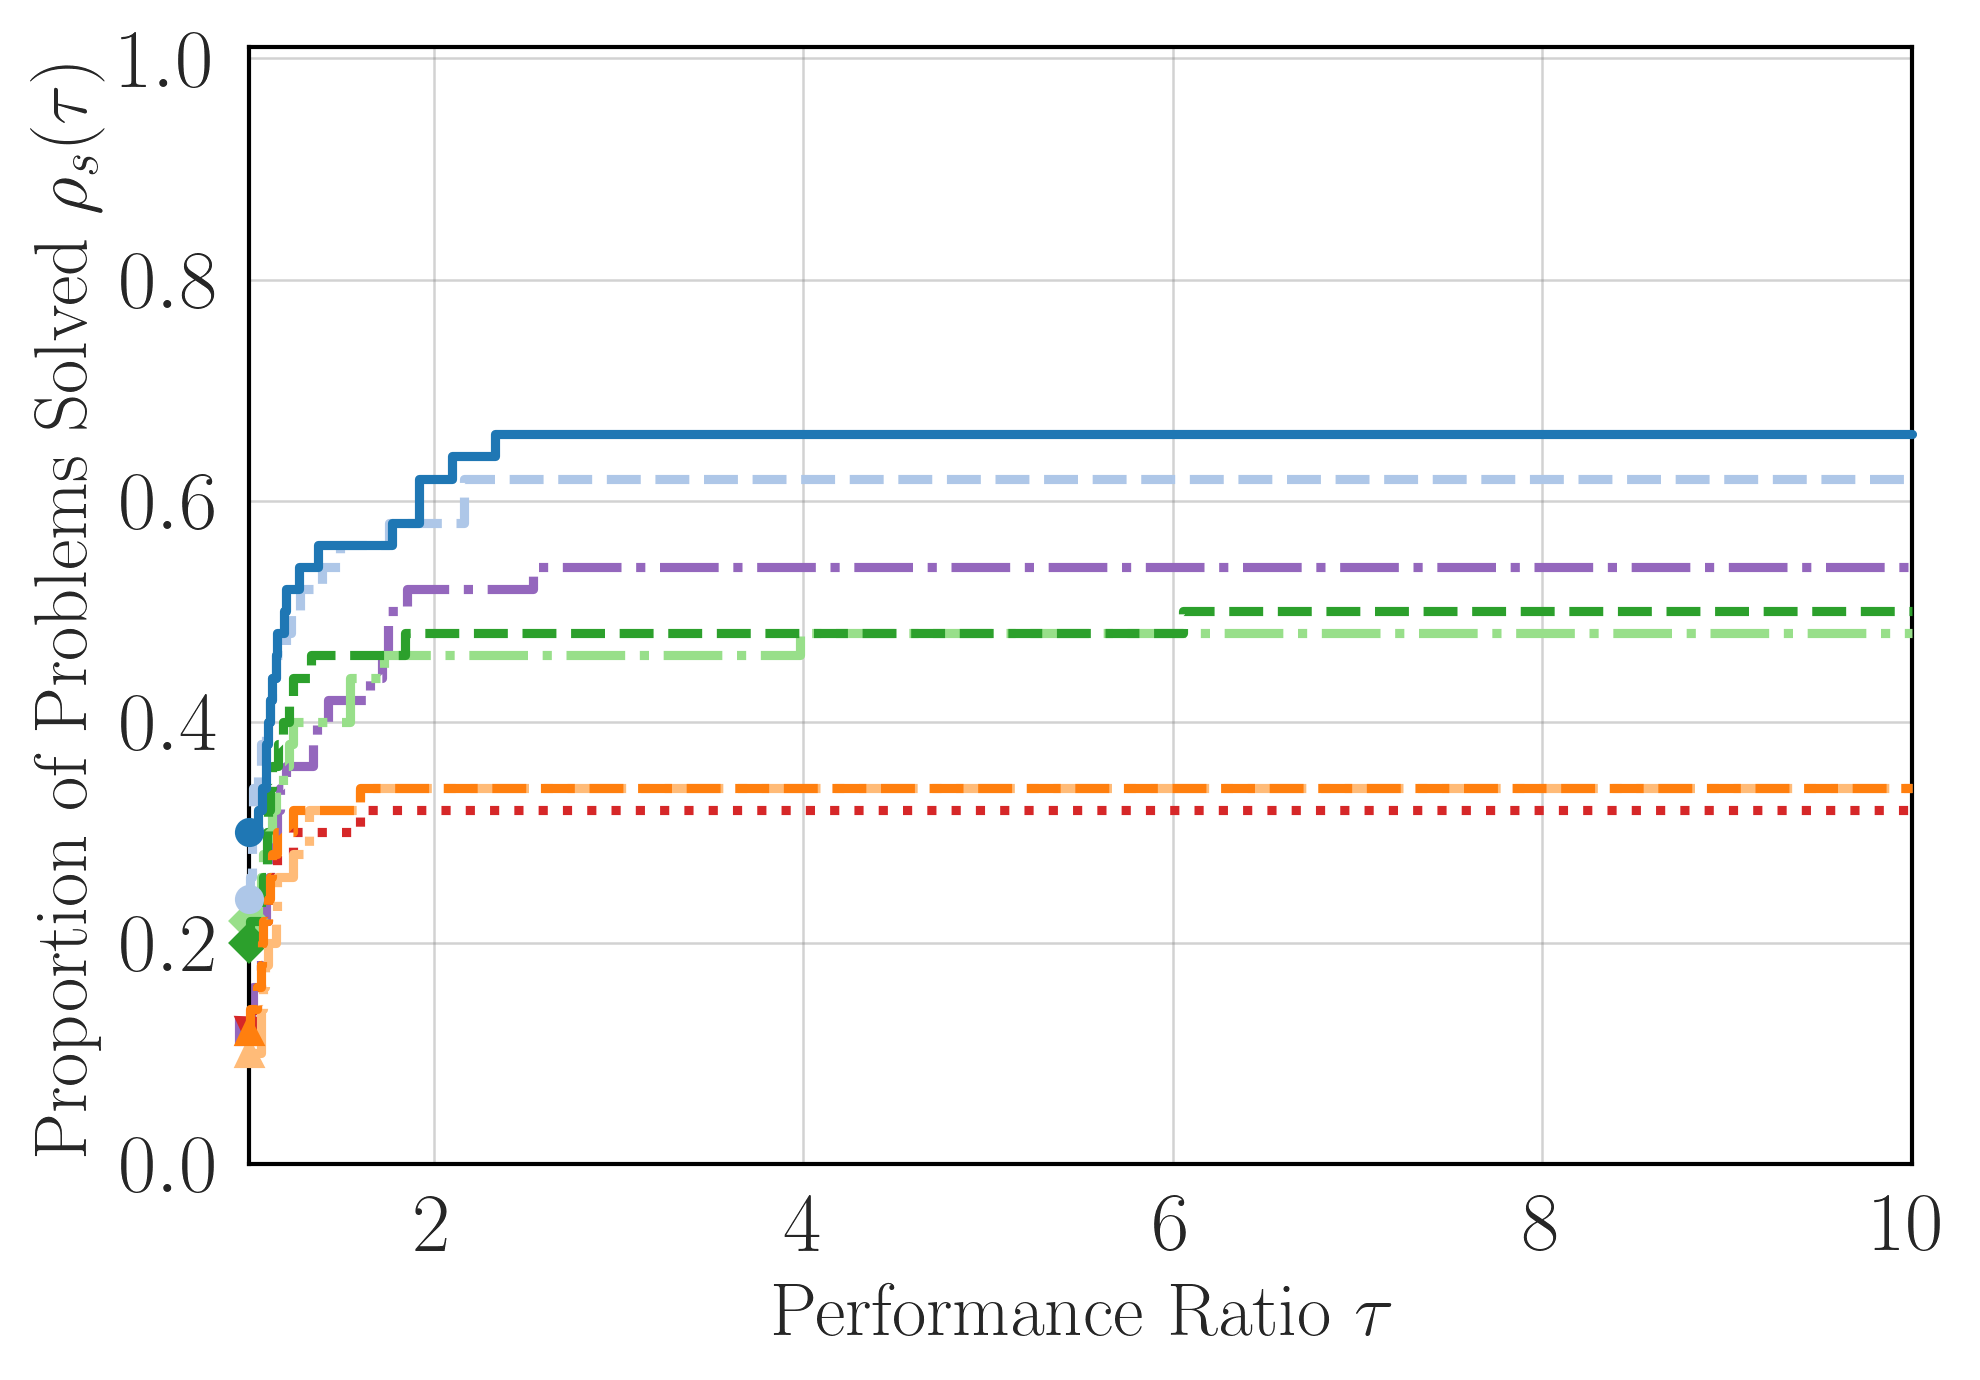

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-05.pdf


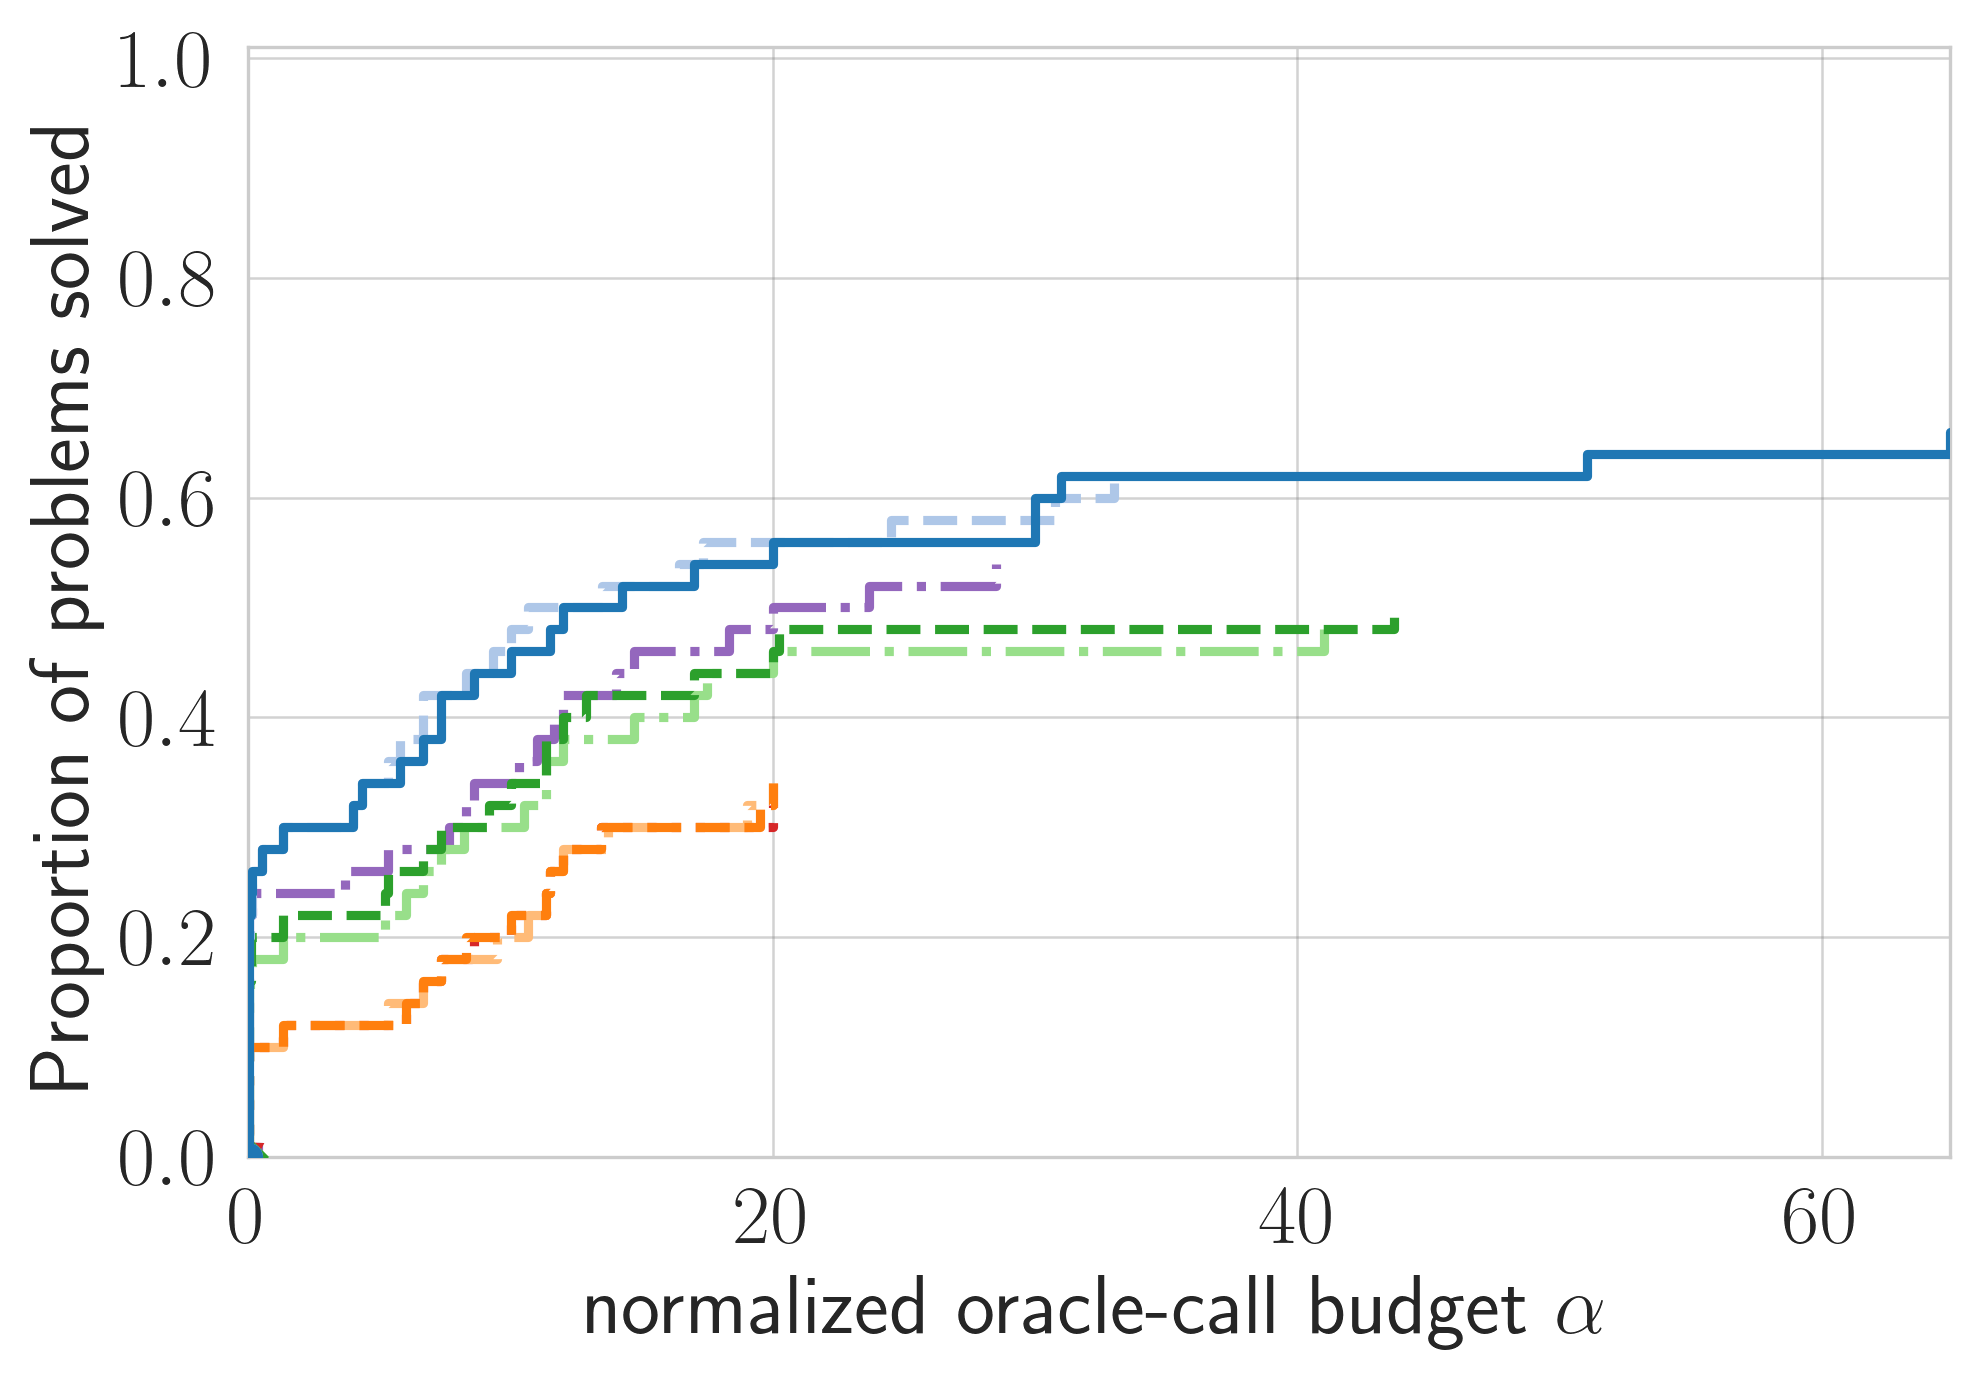

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),51.0,52.0,inf,inf,51.0,51.0,inf,inf
ALLINITU (seed=0),29.0,29.0,inf,inf,26.0,26.0,inf,43.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,inf,inf,8.0,5.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGTRIGLS (seed=0),1731.0,1665.0,1666.0,1902.0,1846.0,1656.0,1726.0,1670.0
ARWHEAD (seed=0),32.0,34.0,inf,inf,36.0,32.0,inf,56.0
BA-L1LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BA-L1SPLS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BARD (seed=0),57.0,54.0,48.0,48.0,48.0,48.0,48.0,56.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,66.0,30.0
NTRQN-MS,62.0,24.0
Line,34.0,12.0
Line-MS,34.0,10.0
Reg,50.0,20.0
Reg-Sec,48.0,22.0
SciPy,32.0,12.0
NTQN,54.0,12.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,49,1,0,16
NTRQN-MS,50,0,49,1,0,18
Line,50,0,50,0,0,33
Line-MS,50,0,50,0,0,33
Reg,50,0,49,0,1,24
Reg-Sec,50,0,50,0,0,26
SciPy,50,0,50,0,0,8
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,27,2,21


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-01.pdf


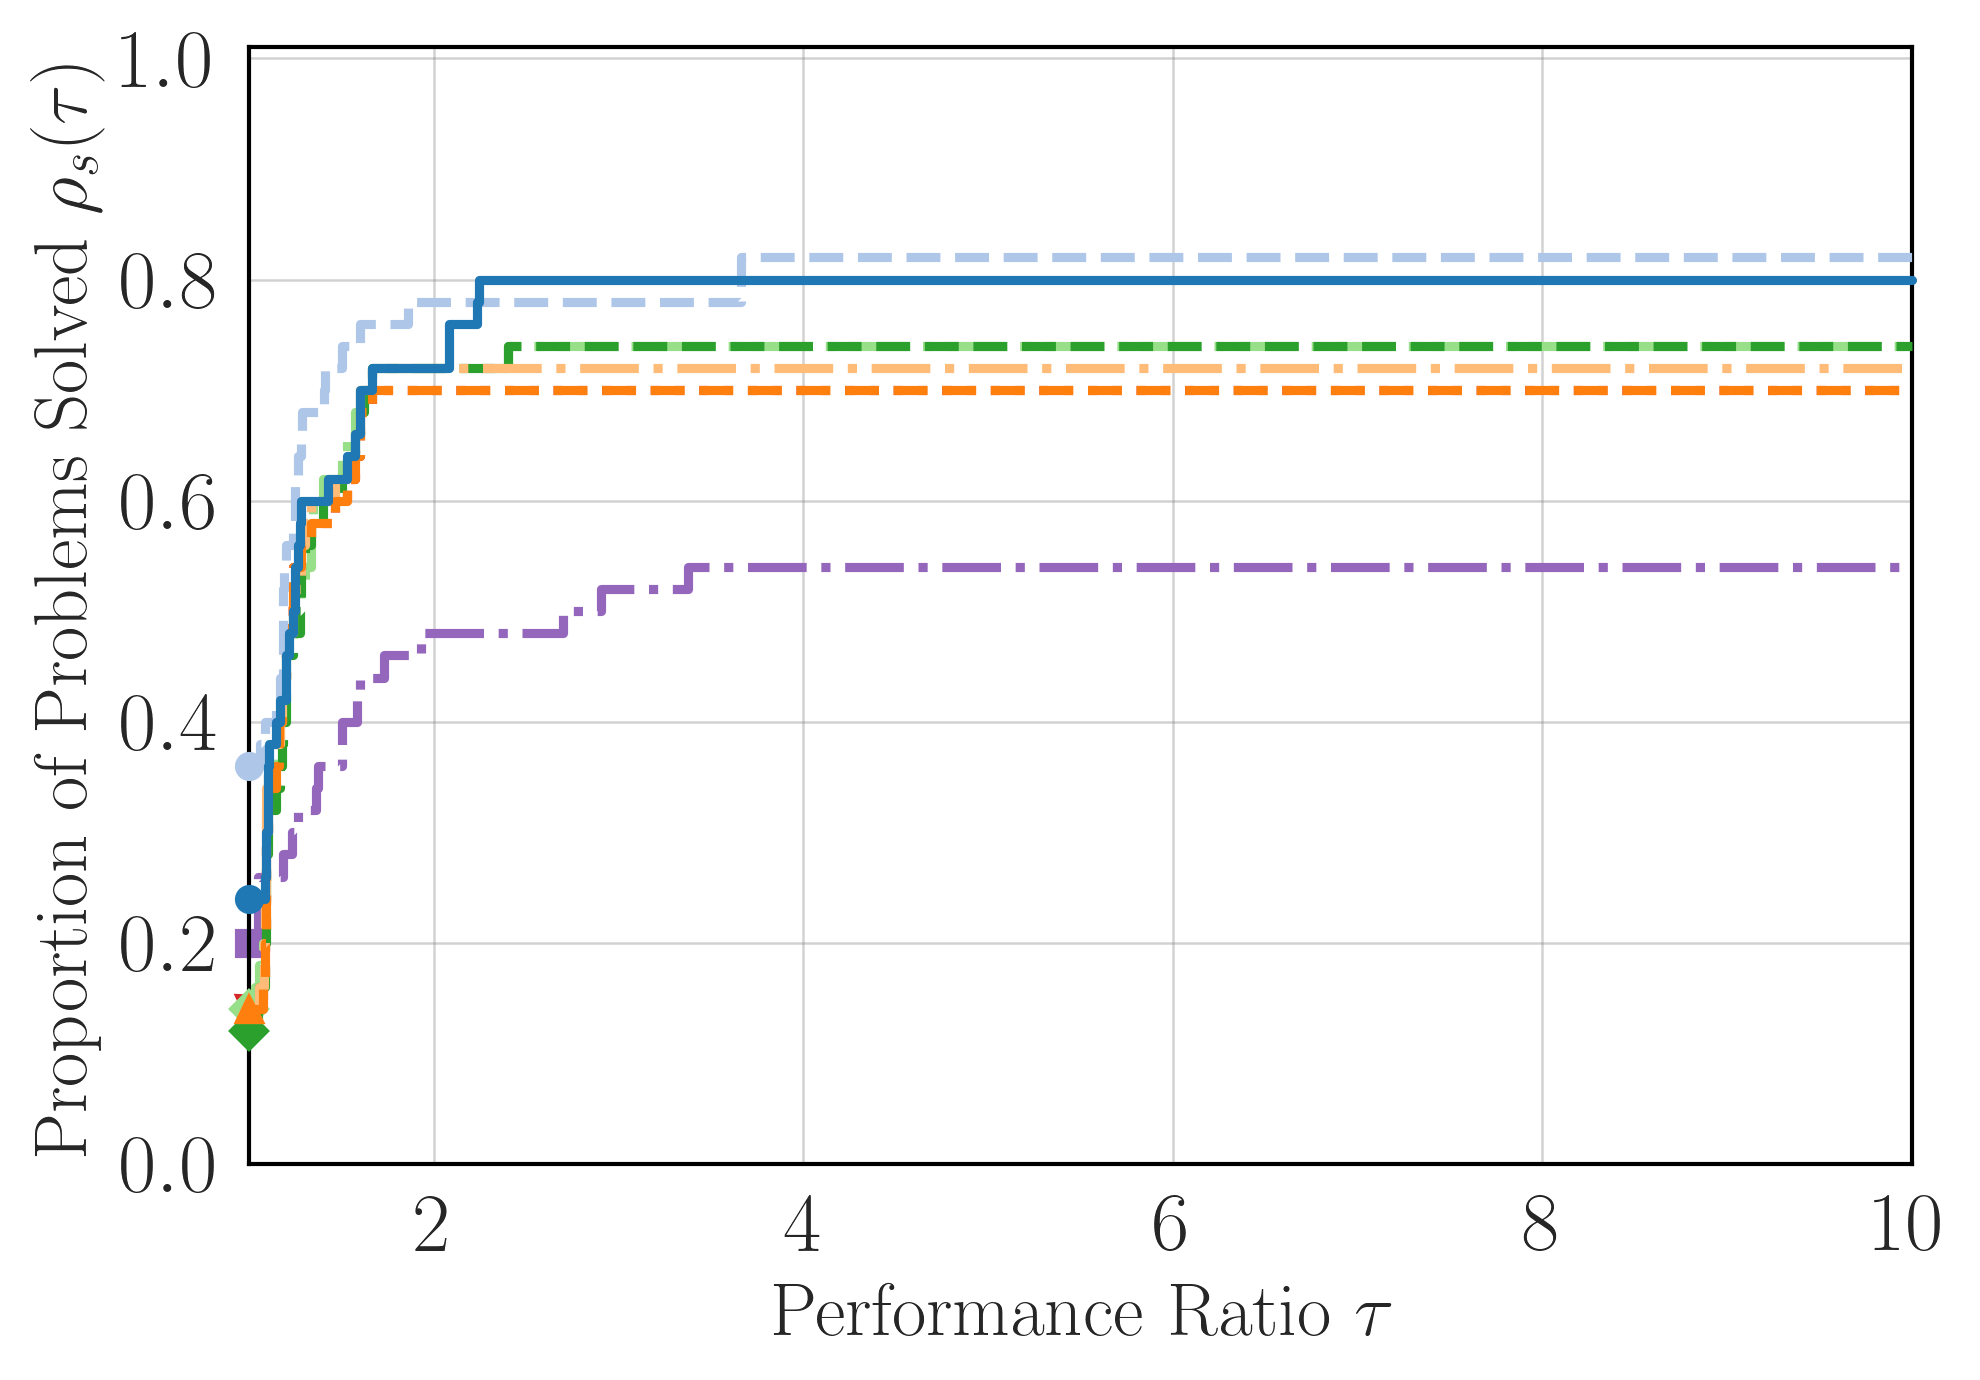

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-01.pdf


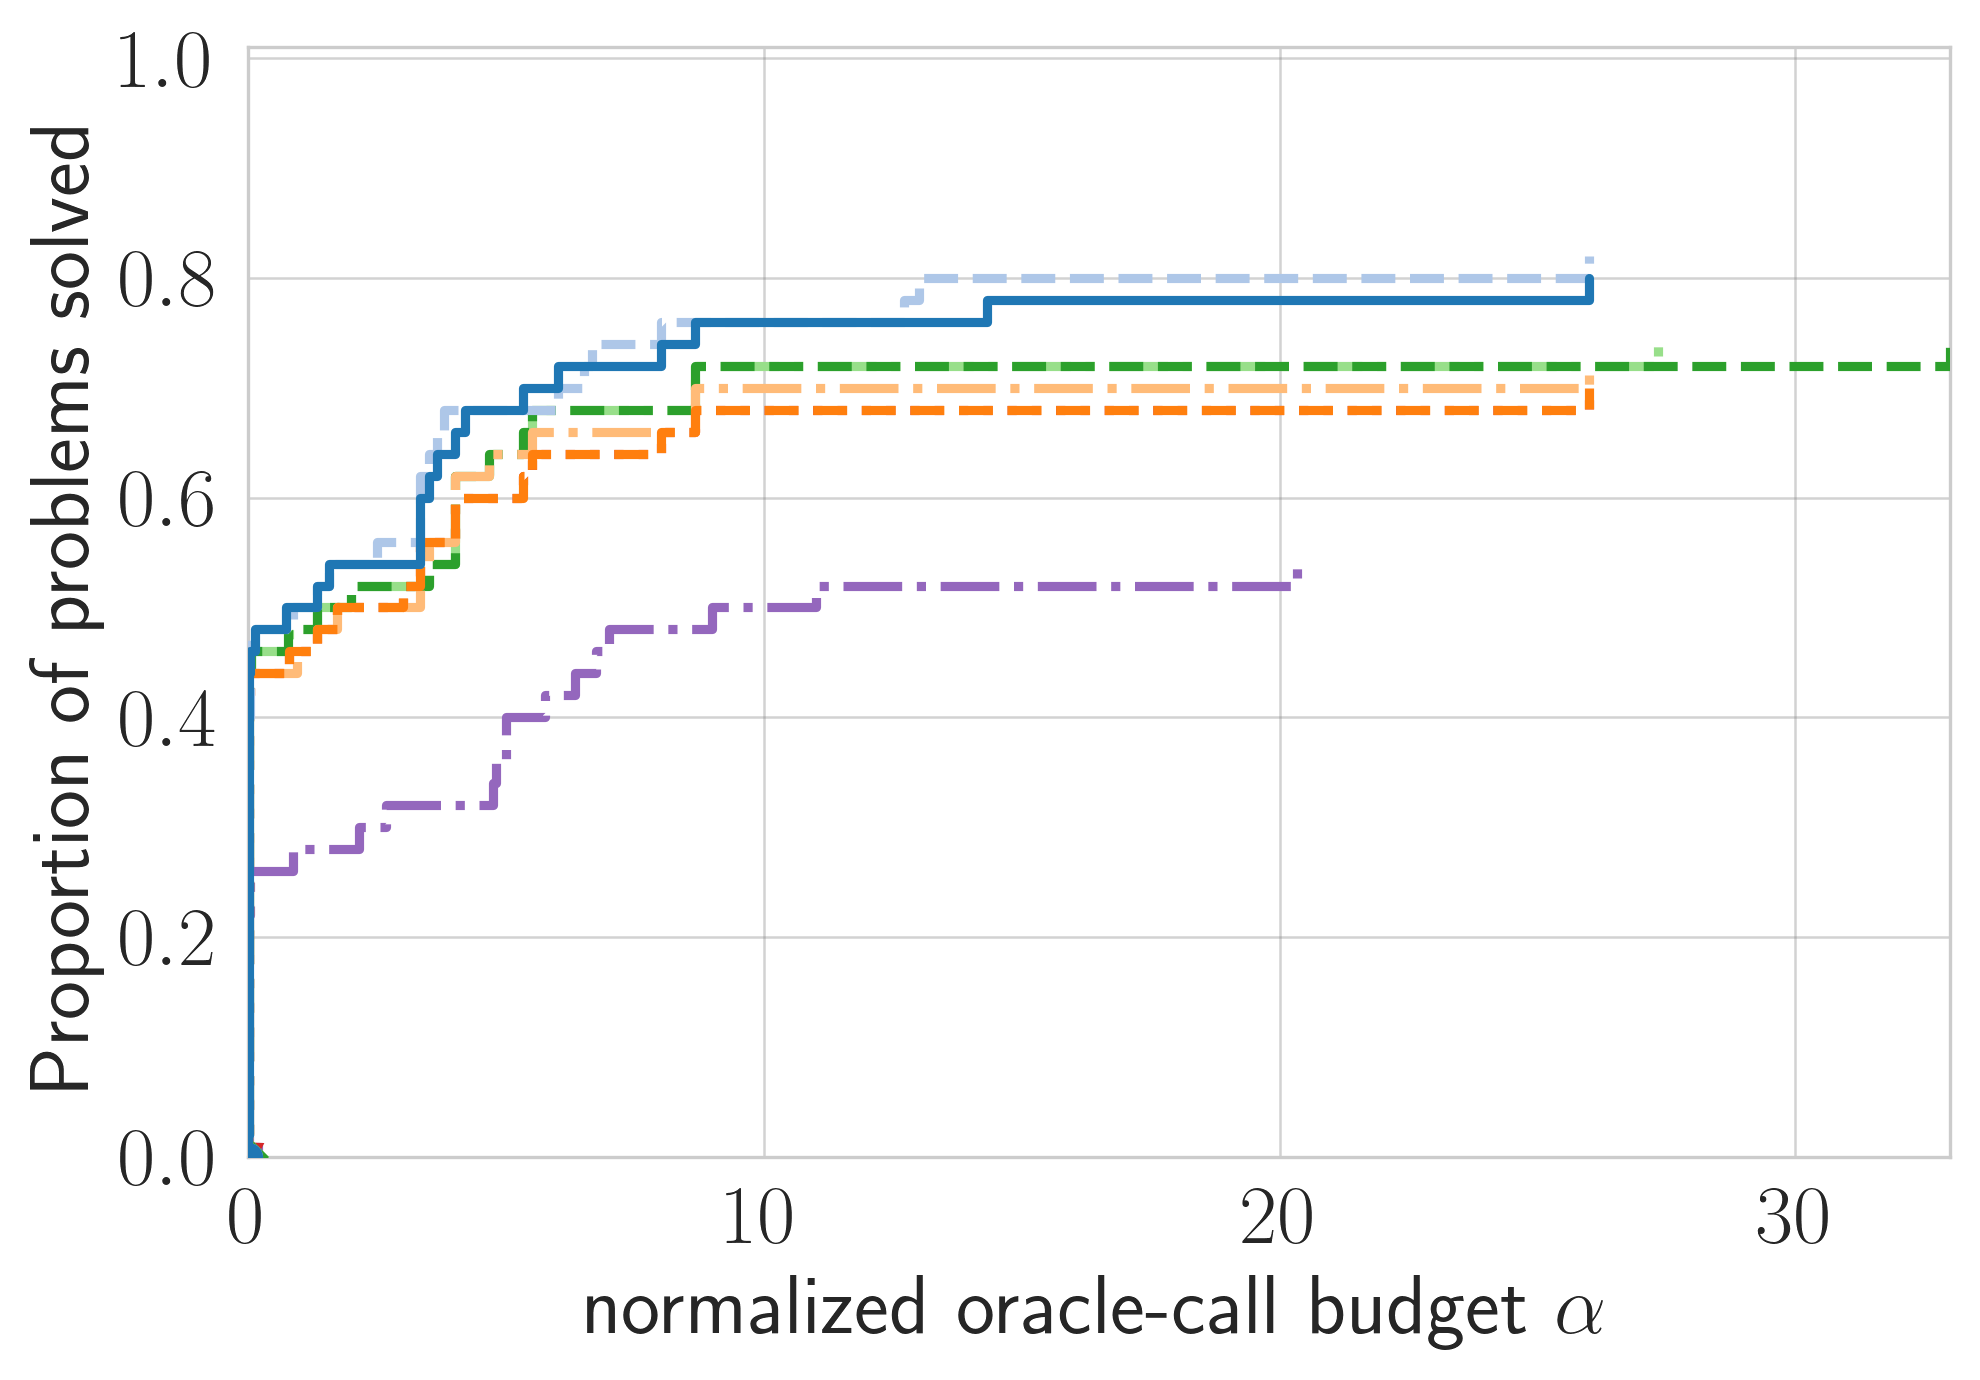

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),43.0,39.0,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),21.0,19.0,inf,20.0,20.0,20.0,inf,24.0
ARGLINA (seed=0),8.0,8.0,8.0,8.0,12.0,12.0,8.0,5.0
ARGTRIGLS (seed=0),147.0,175.0,158.0,188.0,154.0,158.0,158.0,174.0
ARWHEAD (seed=0),10.0,8.0,8.0,8.0,8.0,8.0,8.0,27.0
BARD (seed=0),16.0,10.0,16.0,16.0,16.0,16.0,16.0,27.0
BEALE (seed=0),24.0,20.0,24.0,26.0,26.0,26.0,24.0,21.0
BIGGS6 (seed=0),11.0,11.0,12.0,12.0,14.0,14.0,12.0,15.0
BOX (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BOX3 (seed=0),14.0,14.0,12.0,14.0,14.0,14.0,12.0,19.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,80.0,24.0
NTRQN-MS,82.0,36.0
Line,70.0,14.0
Line-MS,72.0,14.0
Reg,74.0,12.0
Reg-Sec,74.0,14.0
SciPy,70.0,14.0
NTQN,54.0,20.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,28
NTRQN-MS,50,0,50,0,0,28
Line,50,0,50,0,0,44
Line-MS,50,0,50,0,0,44
Reg,50,0,48,0,2,34
Reg-Sec,50,0,50,0,0,36
SciPy,50,0,49,1,0,31
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,10,2,38


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-03.pdf


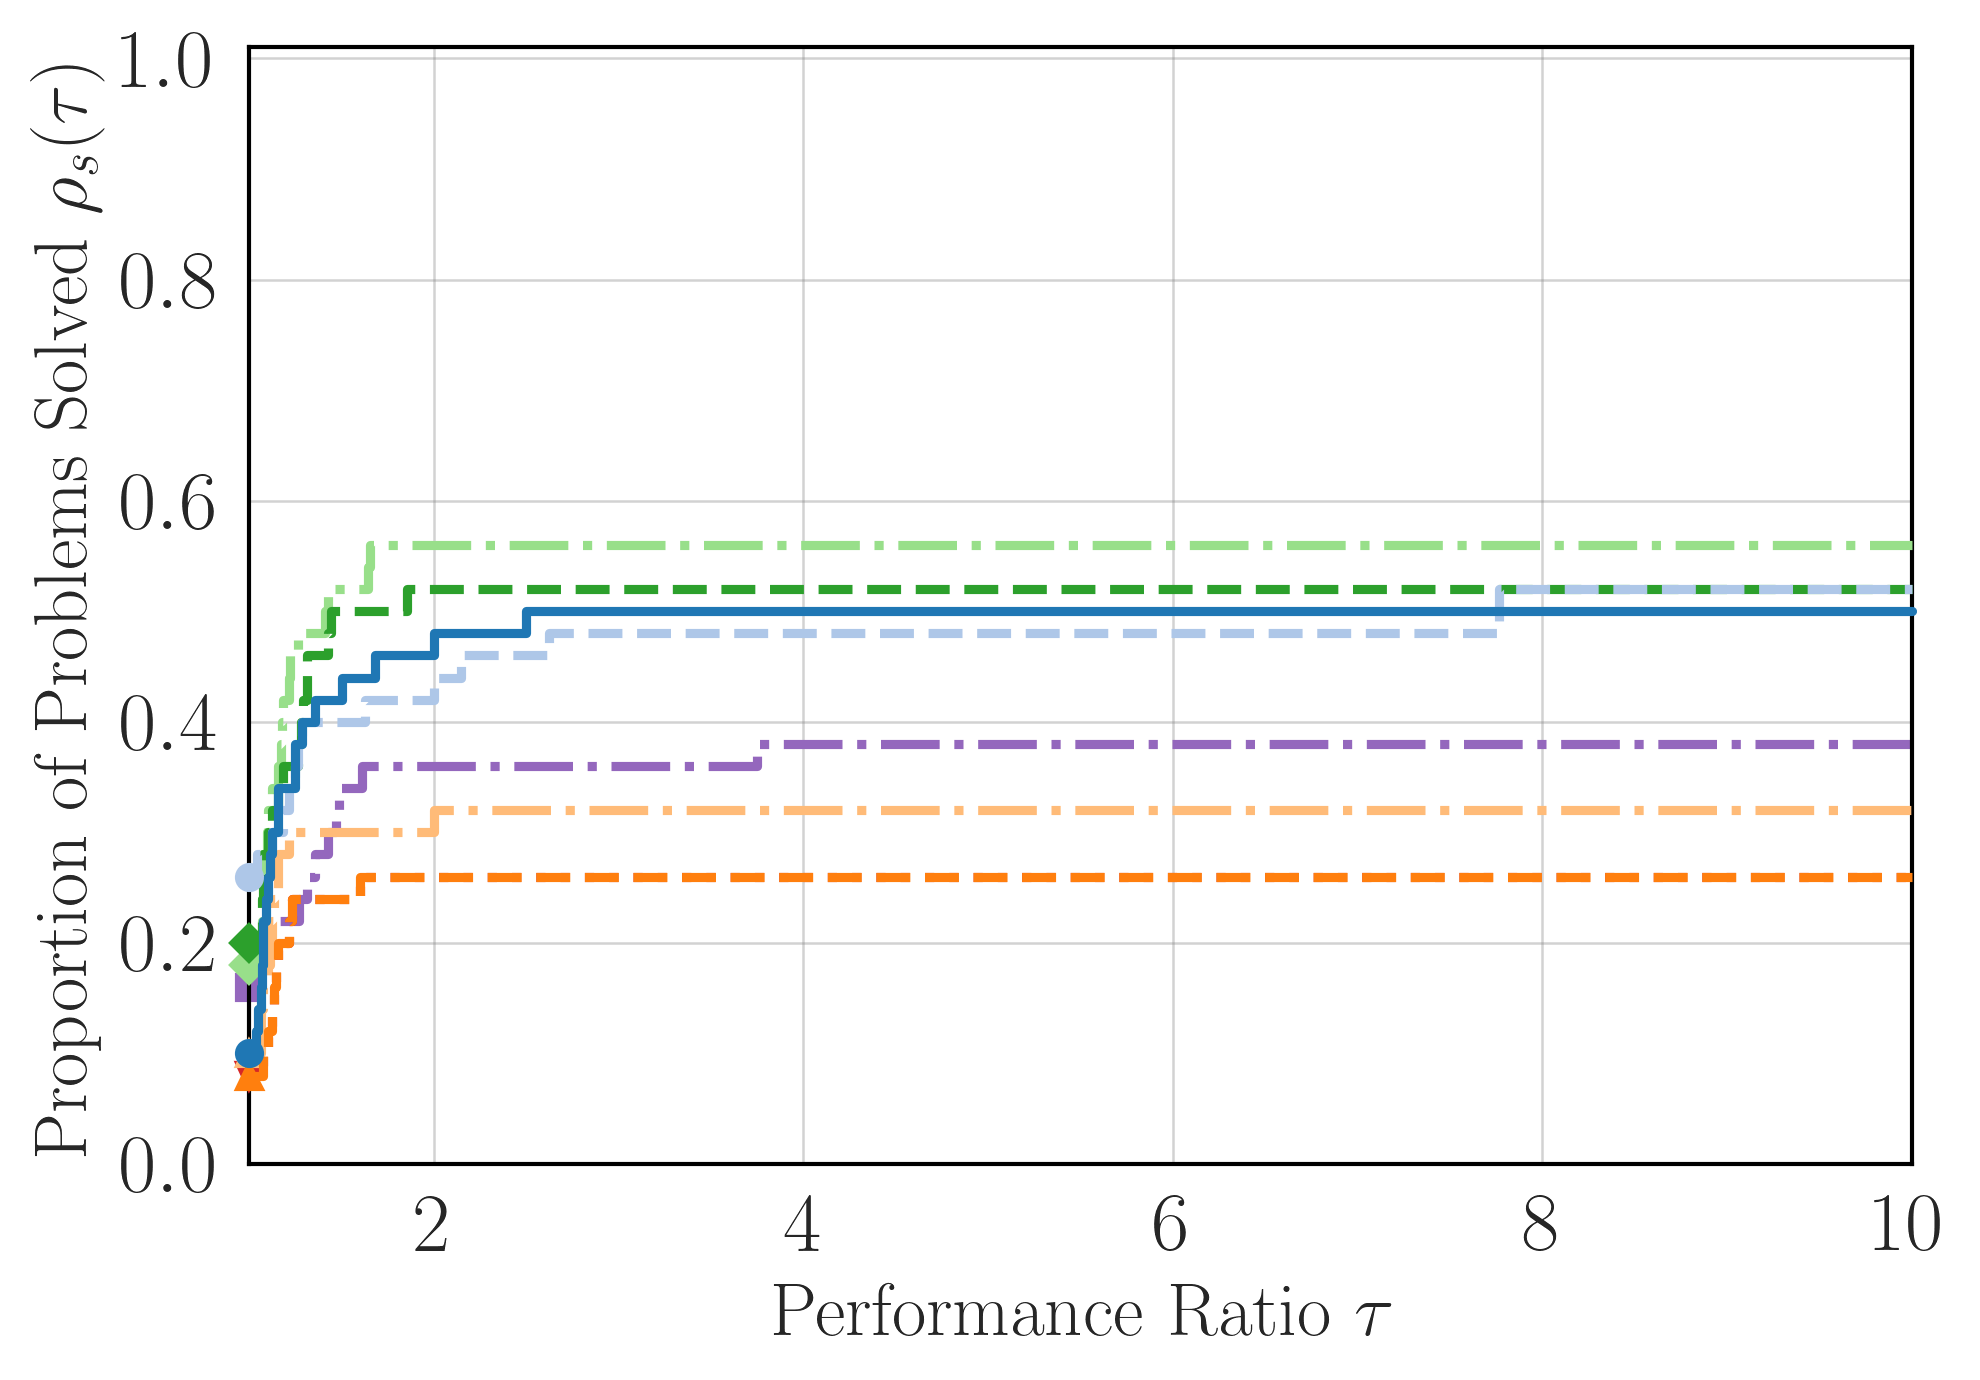

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-03.pdf


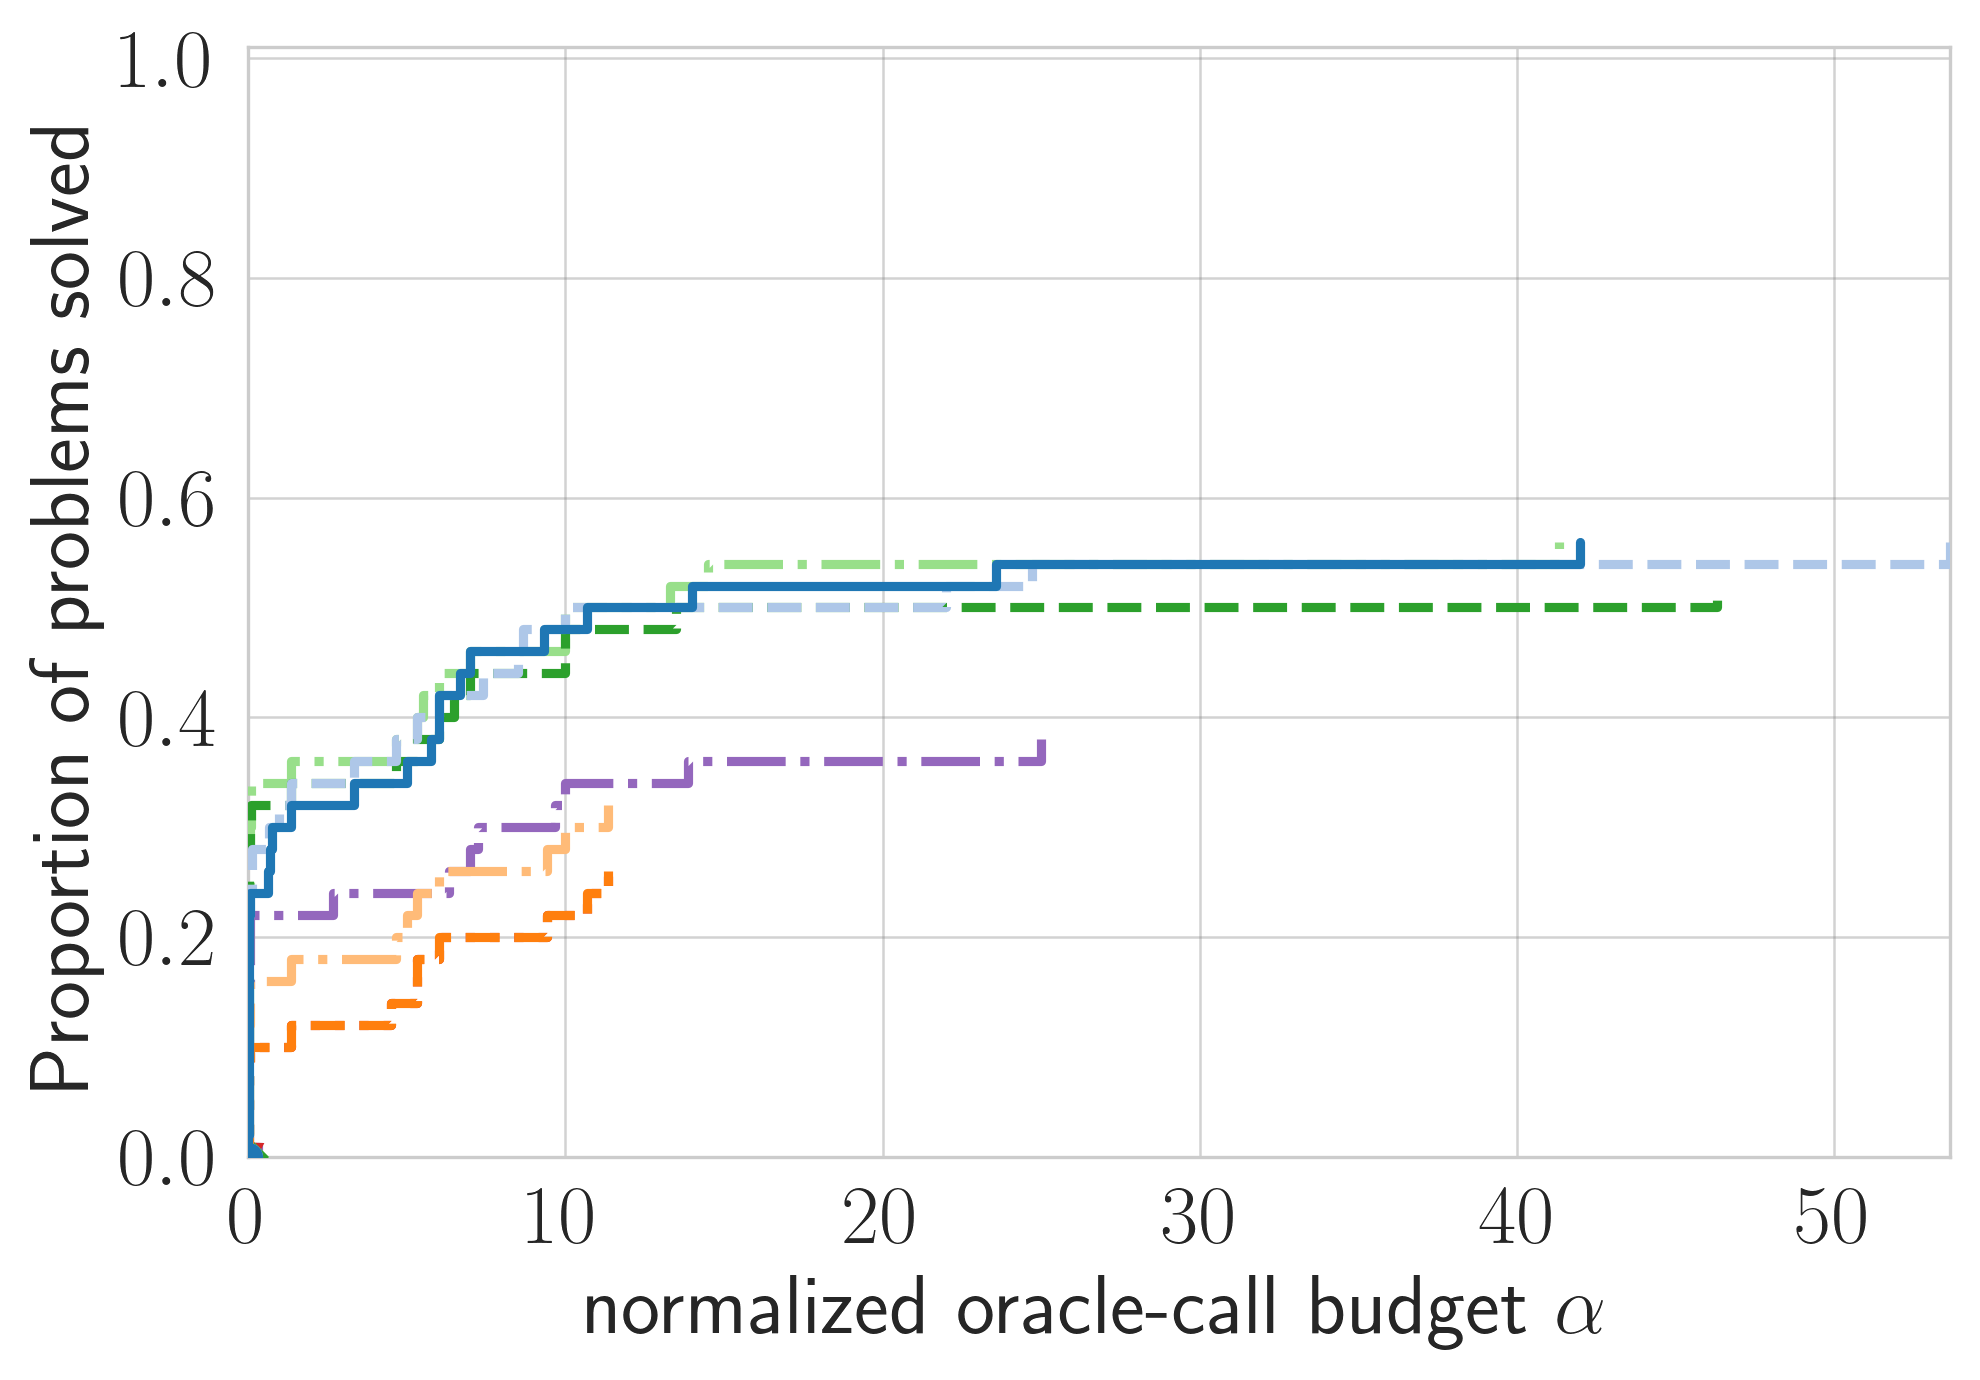

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0
ARGTRIGLS (seed=0),1157.0,1485.0,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0
BARD (seed=0),56.0,88.0,inf,inf,54.0,58.0,inf,inf
BEALE (seed=0),28.0,26.0,32.0,30.0,30.0,30.0,32.0,29.0
BIGGS6 (seed=0),165.0,173.0,66.0,66.0,inf,93.0,66.0,97.0
BOX (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BOX3 (seed=0),20.0,inf,18.0,20.0,26.0,22.0,18.0,29.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,56.0,10.0
NTRQN-MS,56.0,26.0
Line,26.0,8.0
Line-MS,32.0,10.0
Reg,52.0,20.0
Reg-Sec,56.0,18.0
SciPy,26.0,8.0
NTQN,38.0,16.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,28
NTRQN-MS,50,0,50,0,0,28
Line,50,0,50,0,0,44
Line-MS,50,0,50,0,0,44
Reg,50,0,48,0,2,34
Reg-Sec,50,0,50,0,0,36
SciPy,50,0,49,1,0,31
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,10,2,38


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-05.pdf


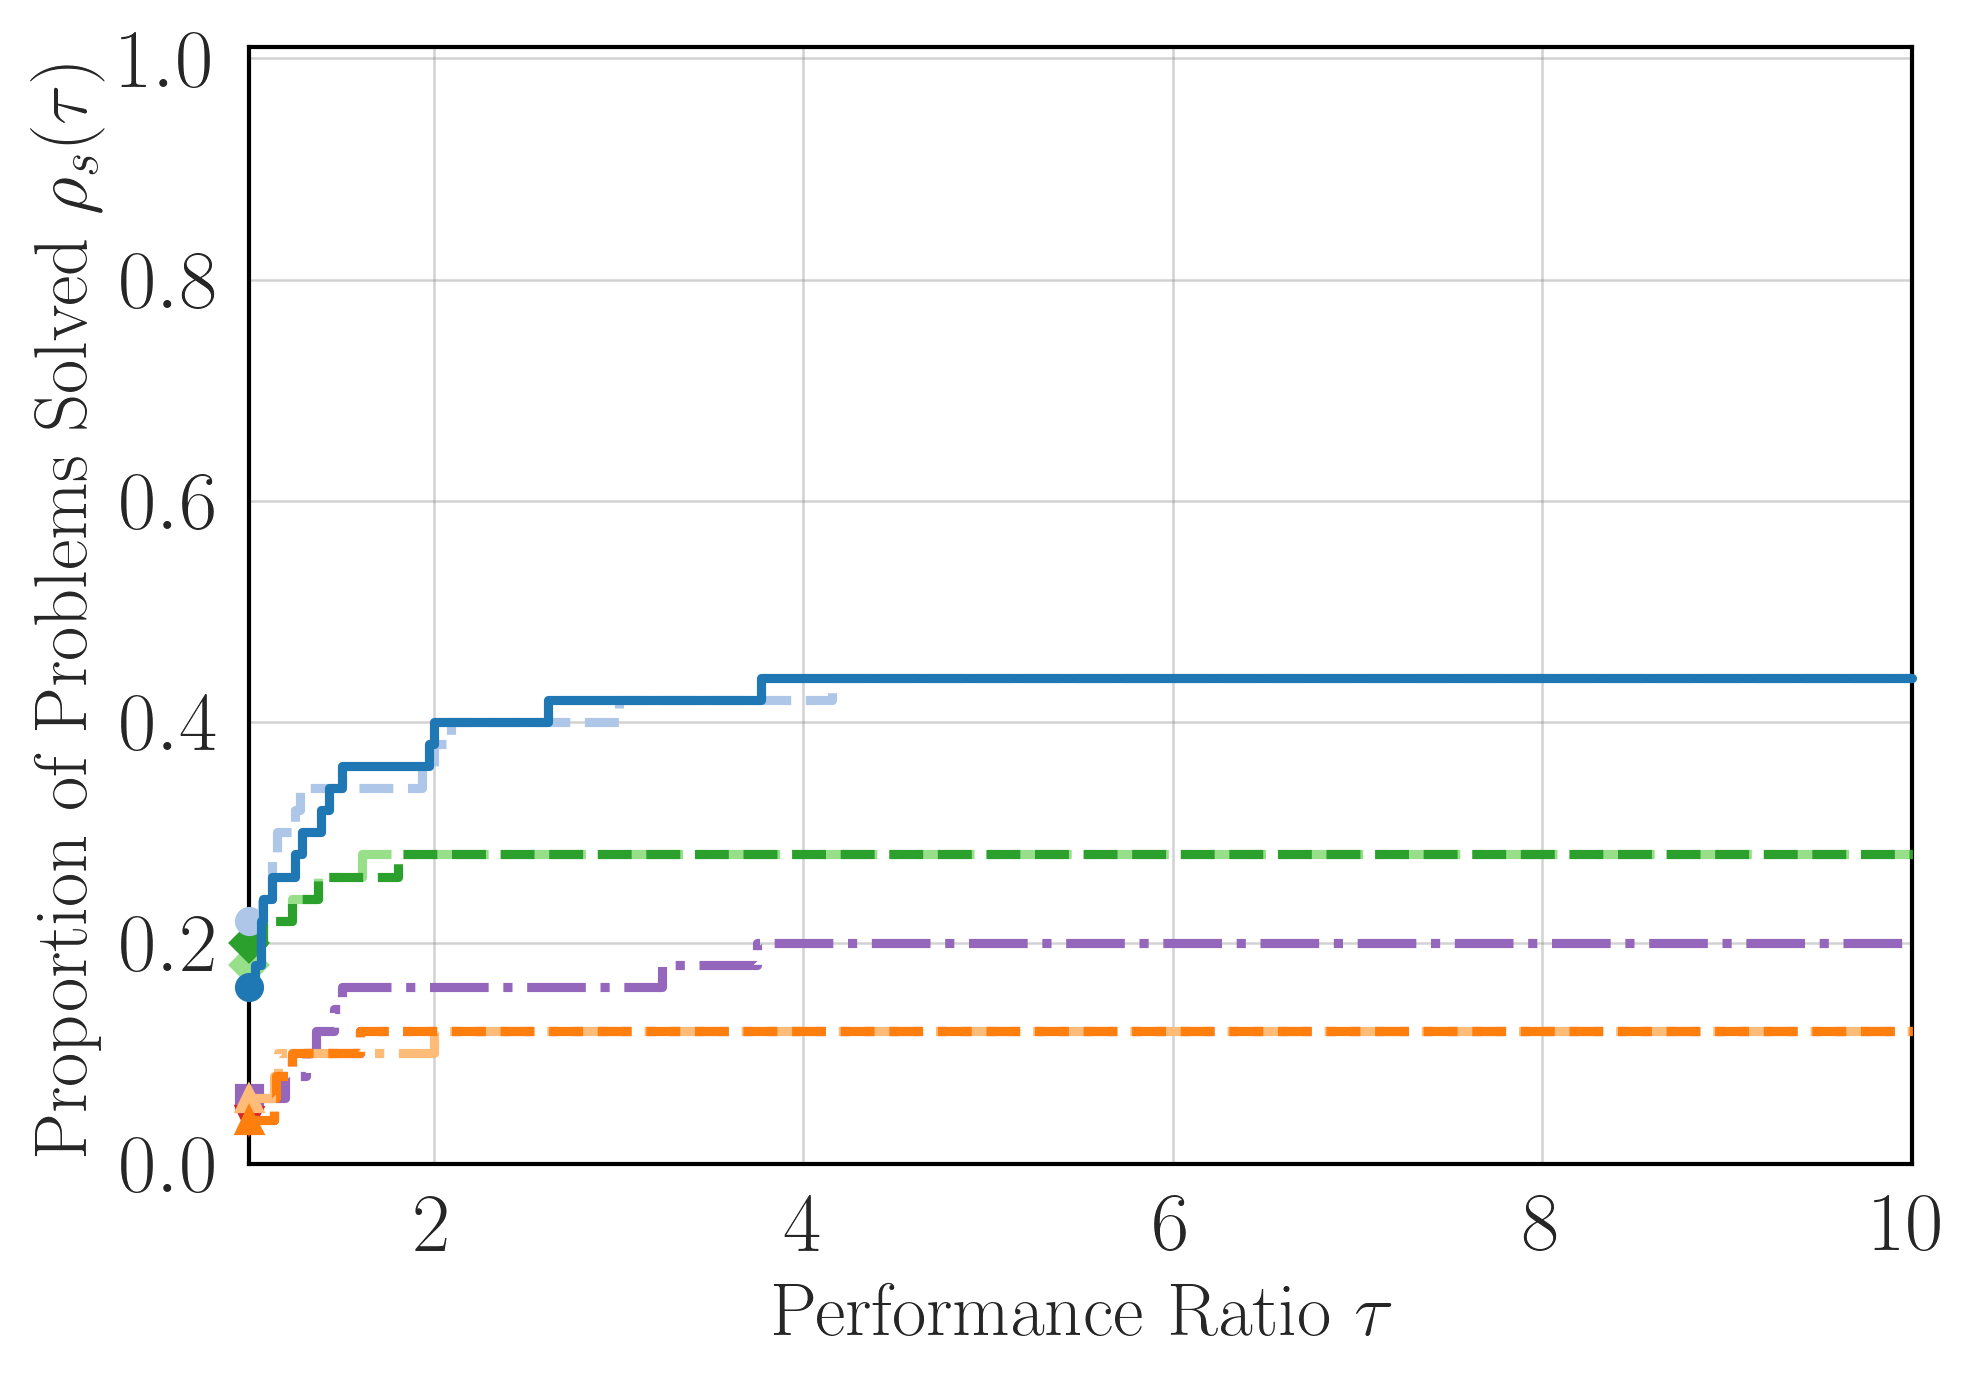

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-05.pdf


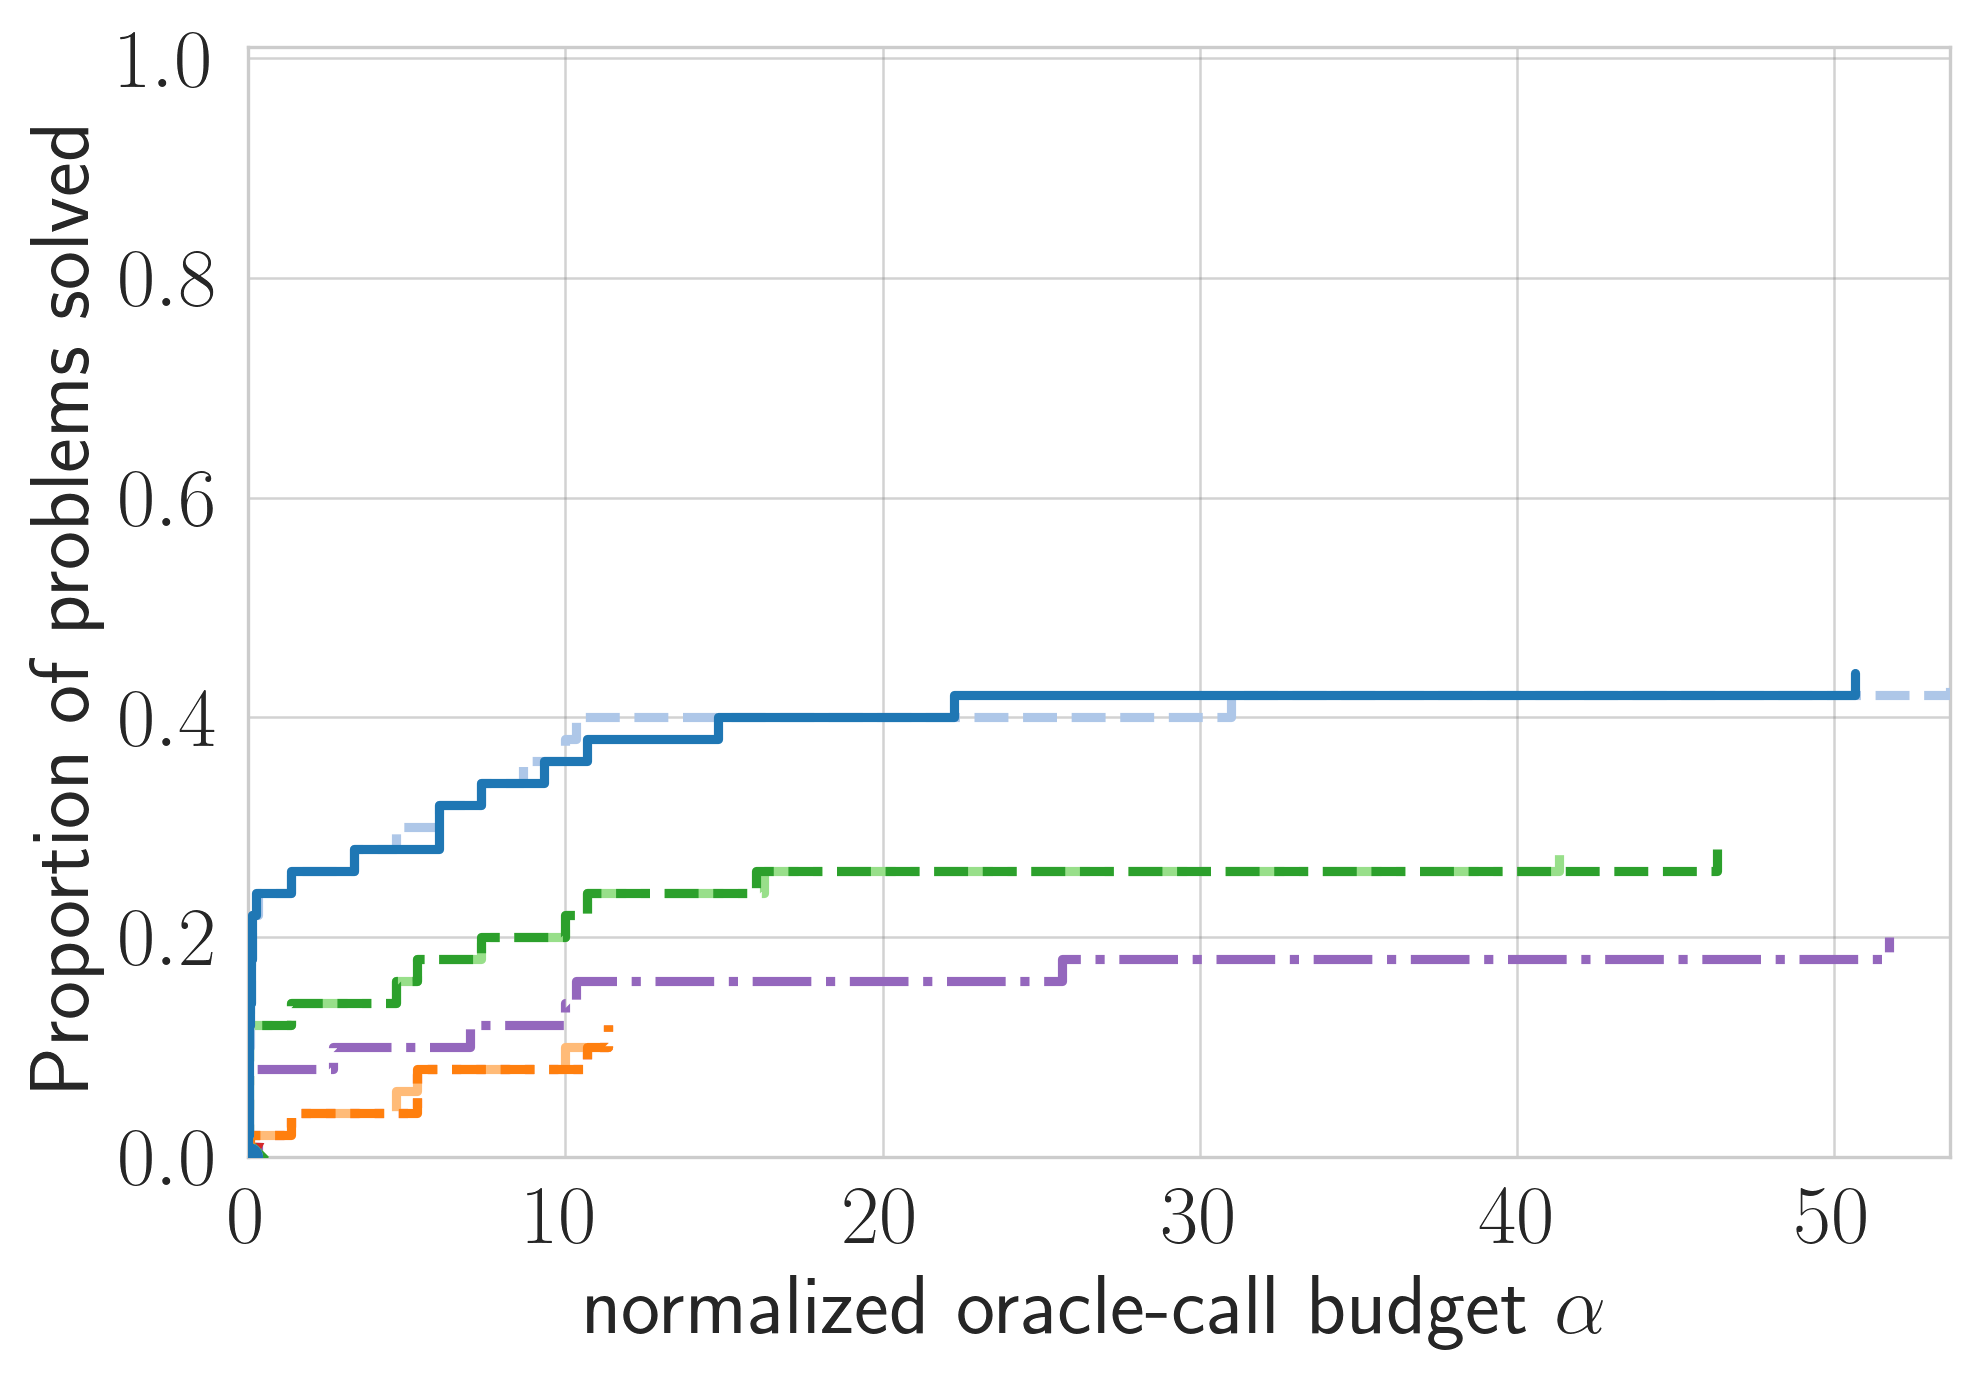

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0
ARGTRIGLS (seed=0),2977.0,2079.0,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0
BARD (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BEALE (seed=0),28.0,26.0,32.0,30.0,32.0,32.0,32.0,31.0
BIGGS6 (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BOX (seed=0),inf,inf,inf,inf,inf,inf,inf,inf
BOX3 (seed=0),inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,44.0,16.0
NTRQN-MS,44.0,22.0
Line,12.0,4.0
Line-MS,12.0,6.0
Reg,28.0,20.0
Reg-Sec,28.0,18.0
SciPy,12.0,4.0
NTQN,20.0,6.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,28
NTRQN-MS,50,0,50,0,0,28
Line,50,0,50,0,0,44
Line-MS,50,0,50,0,0,44
Reg,50,0,48,0,2,34
Reg-Sec,50,0,50,0,0,36
SciPy,50,0,49,1,0,31
NTQN,50,0,50,0,0,2


flag,0,1,6
method,,,
NTQN,10,2,38


Saved figure to doc/imgs/compare/_pp_function_only_gtol1e-02.pdf


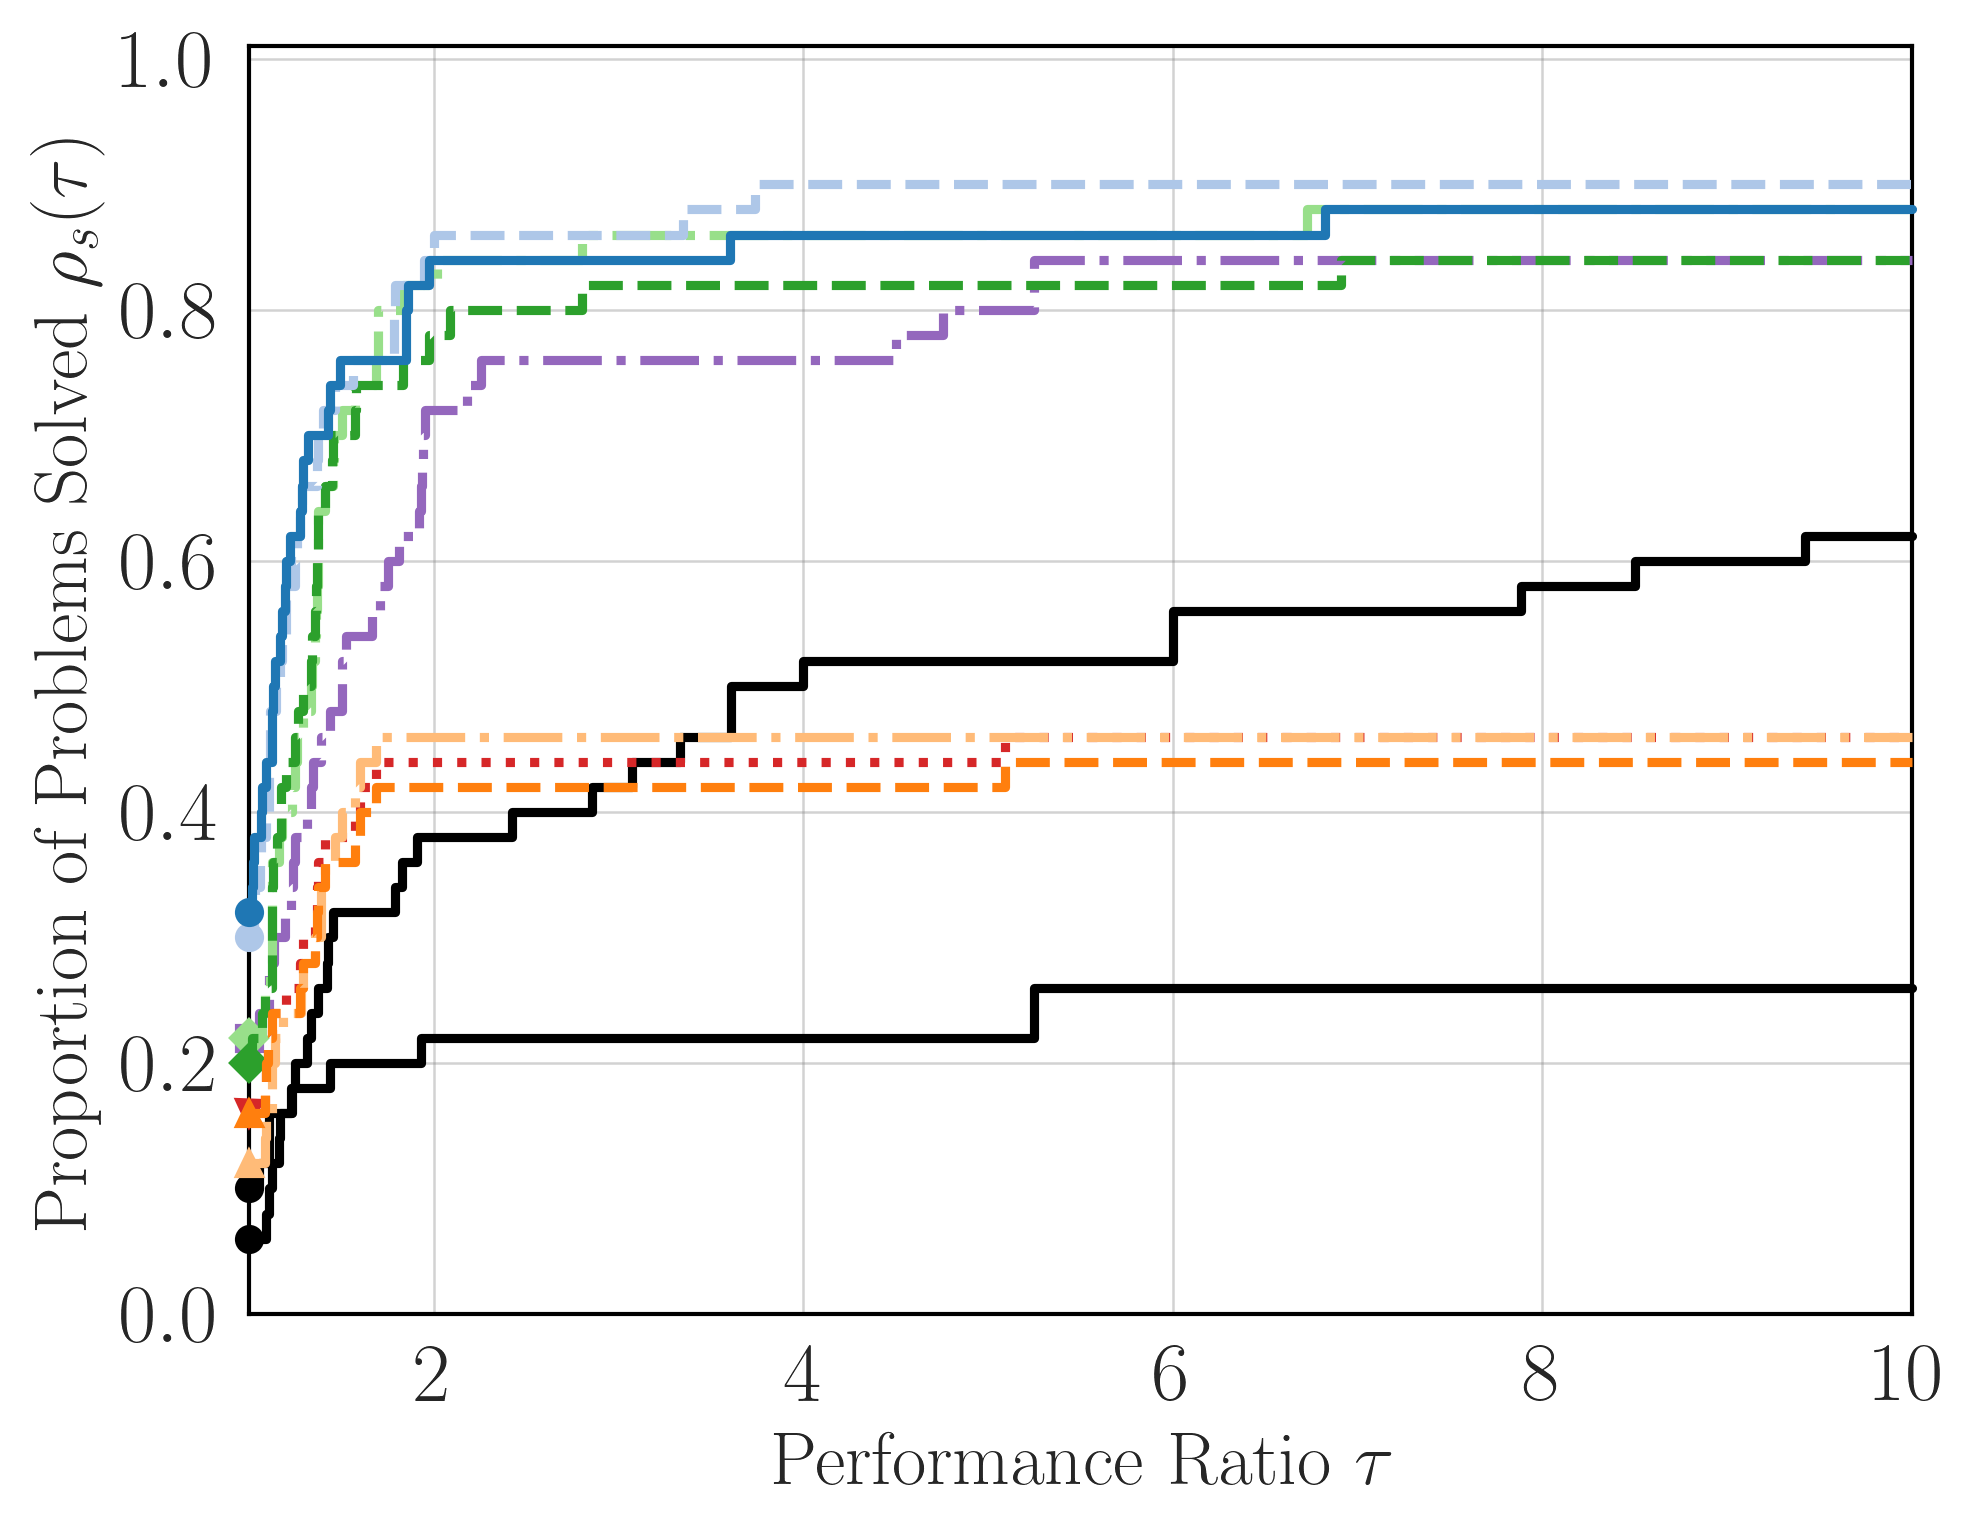

Saved figure to doc/imgs/compare/_dp_function_only_gtol1e-02.pdf


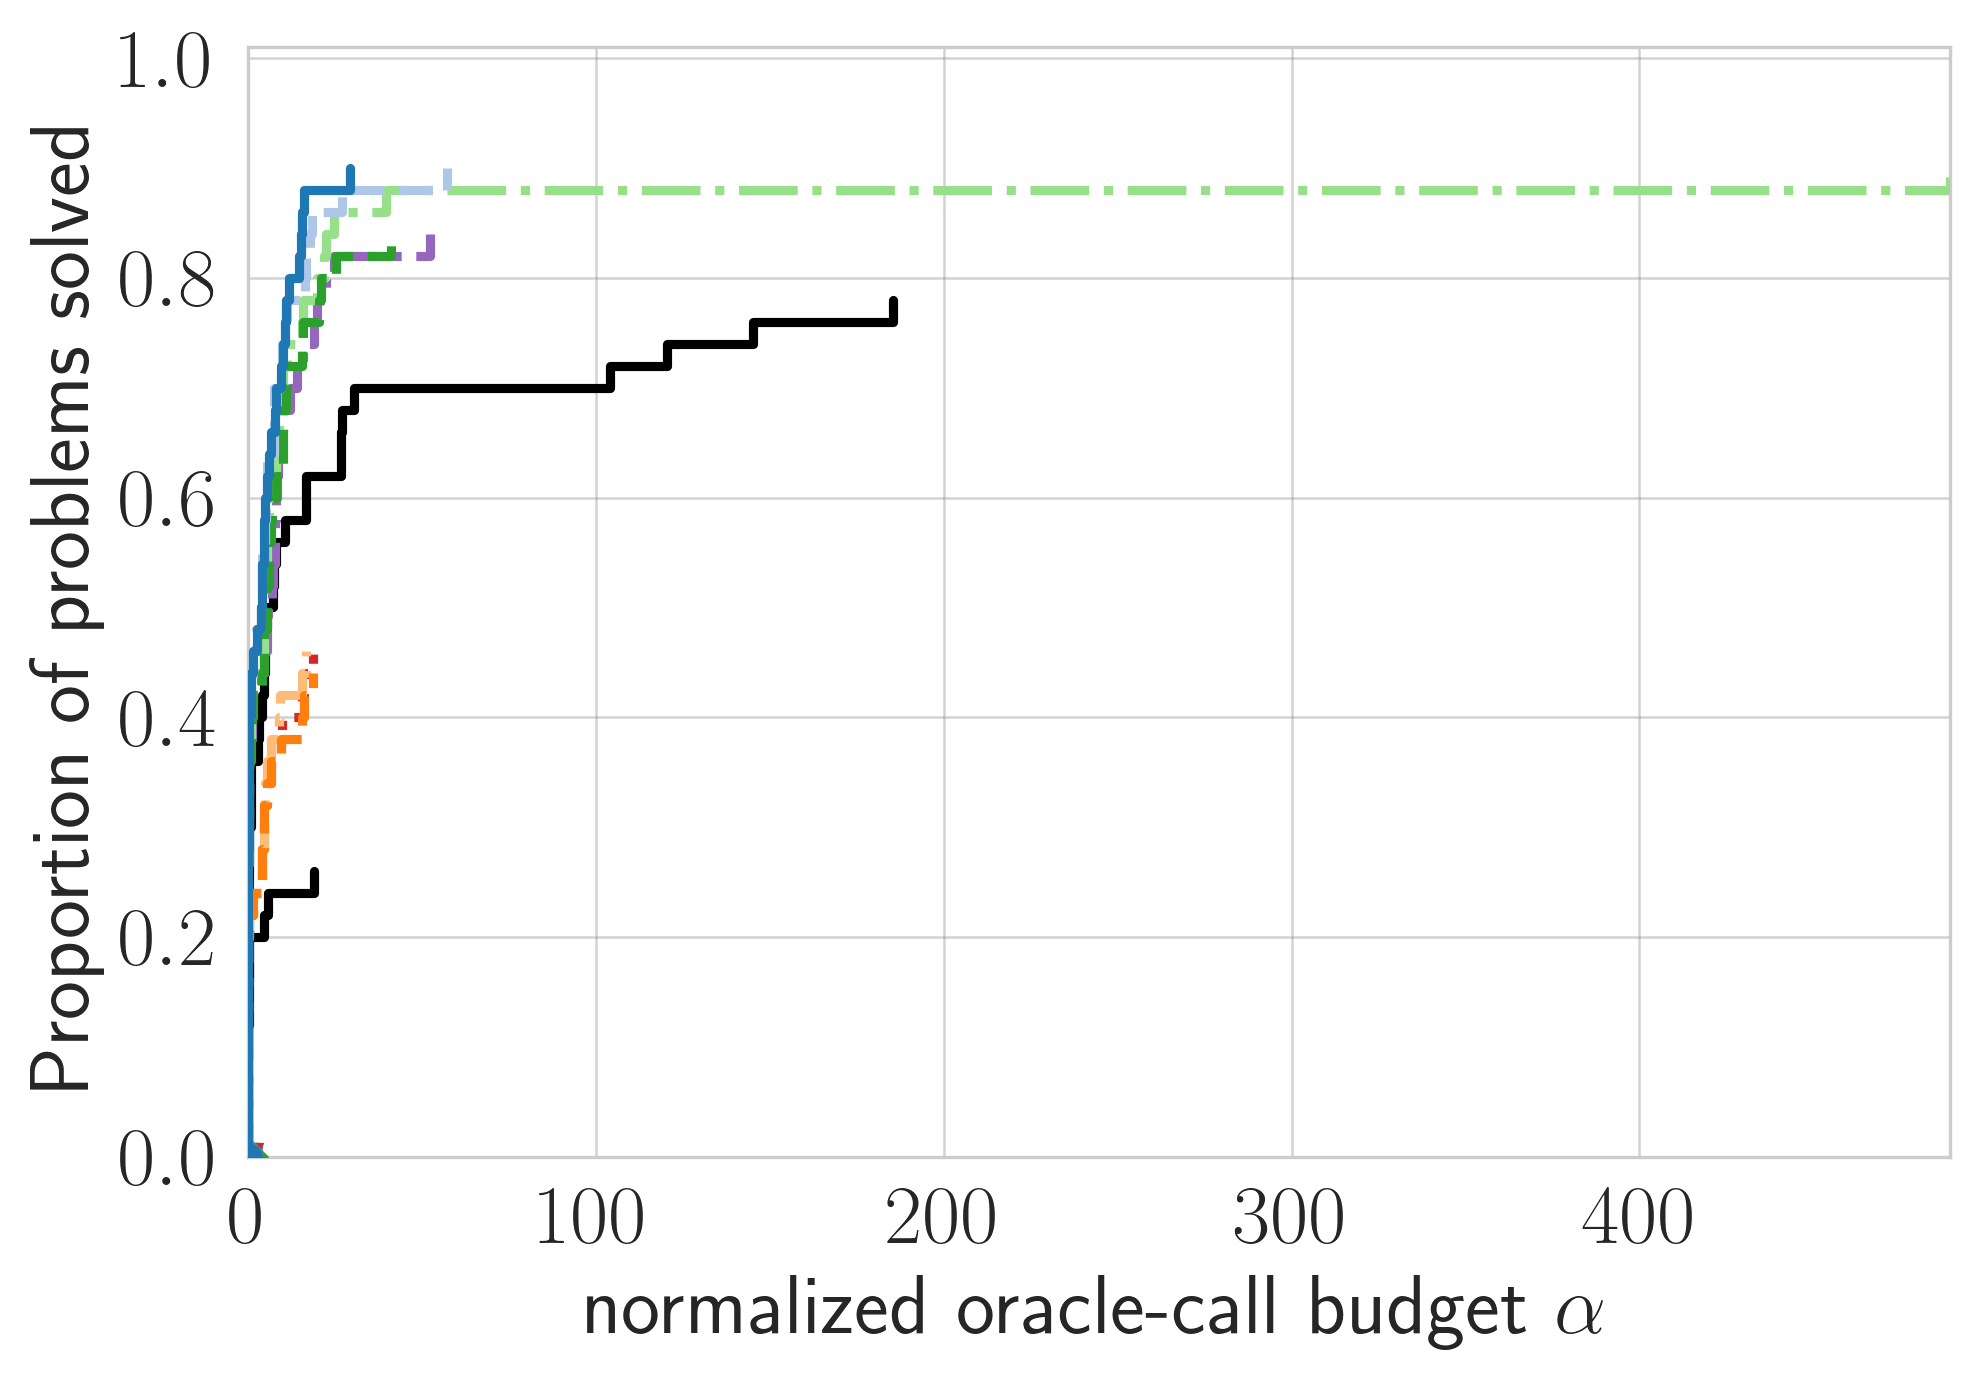

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,NTRQN-OFFO,NTQN-Default-Termination
AKIVA (seed=0),35.0,49.0,inf,inf,47.0,47.0,inf,inf,50.0,inf
ALLINITU (seed=0),23.0,25.0,22.0,24.0,20.0,22.0,22.0,23.0,16.0,23.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,14.0,14.0,8.0,5.0,20.0,inf
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,48.0,42.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,48.0,42.0
ARGTRIGLS (seed=0),471.0,465.0,inf,inf,inf,inf,inf,inf,541.0,inf
ARWHEAD (seed=0),26.0,28.0,inf,inf,inf,inf,inf,27.0,14.0,27.0
BA-L1LS (seed=0),41.0,37.0,inf,inf,36.0,36.0,inf,60.0,48.0,inf
BA-L1SPLS (seed=0),46.0,46.0,inf,inf,53.0,58.0,inf,70.0,51.0,inf
BARD (seed=0),18.0,16.0,18.0,18.0,18.0,18.0,18.0,28.0,18.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.0,32.0
NTRQN-MS,90.0,30.0
Line,44.0,16.0
Line-MS,46.0,12.0
Reg,84.0,20.0
Reg-Sec,90.0,22.0
SciPy,46.0,16.0
NTQN,84.0,22.0
NTRQN-OFFO,78.0,6.0
NTQN-Default-Termination,26.0,10.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-MS,50,0,50,0,0,5
Line,50,0,50,0,0,28
Line-MS,50,0,50,0,0,27
Reg,50,0,49,0,1,7
Reg-Sec,50,0,50,0,0,5
SciPy,50,0,50,0,0,1
NTQN,50,0,50,0,0,4
NTRQN-OFFO,50,0,49,1,0,10


flag,0,1,4,6
method,,,,
NTQN,42,4,0,4
NTQN-Default-Termination,29,2,16,3


Saved figure to doc/imgs/compare/_pp_function_only_restart_gtol1e-02.pdf


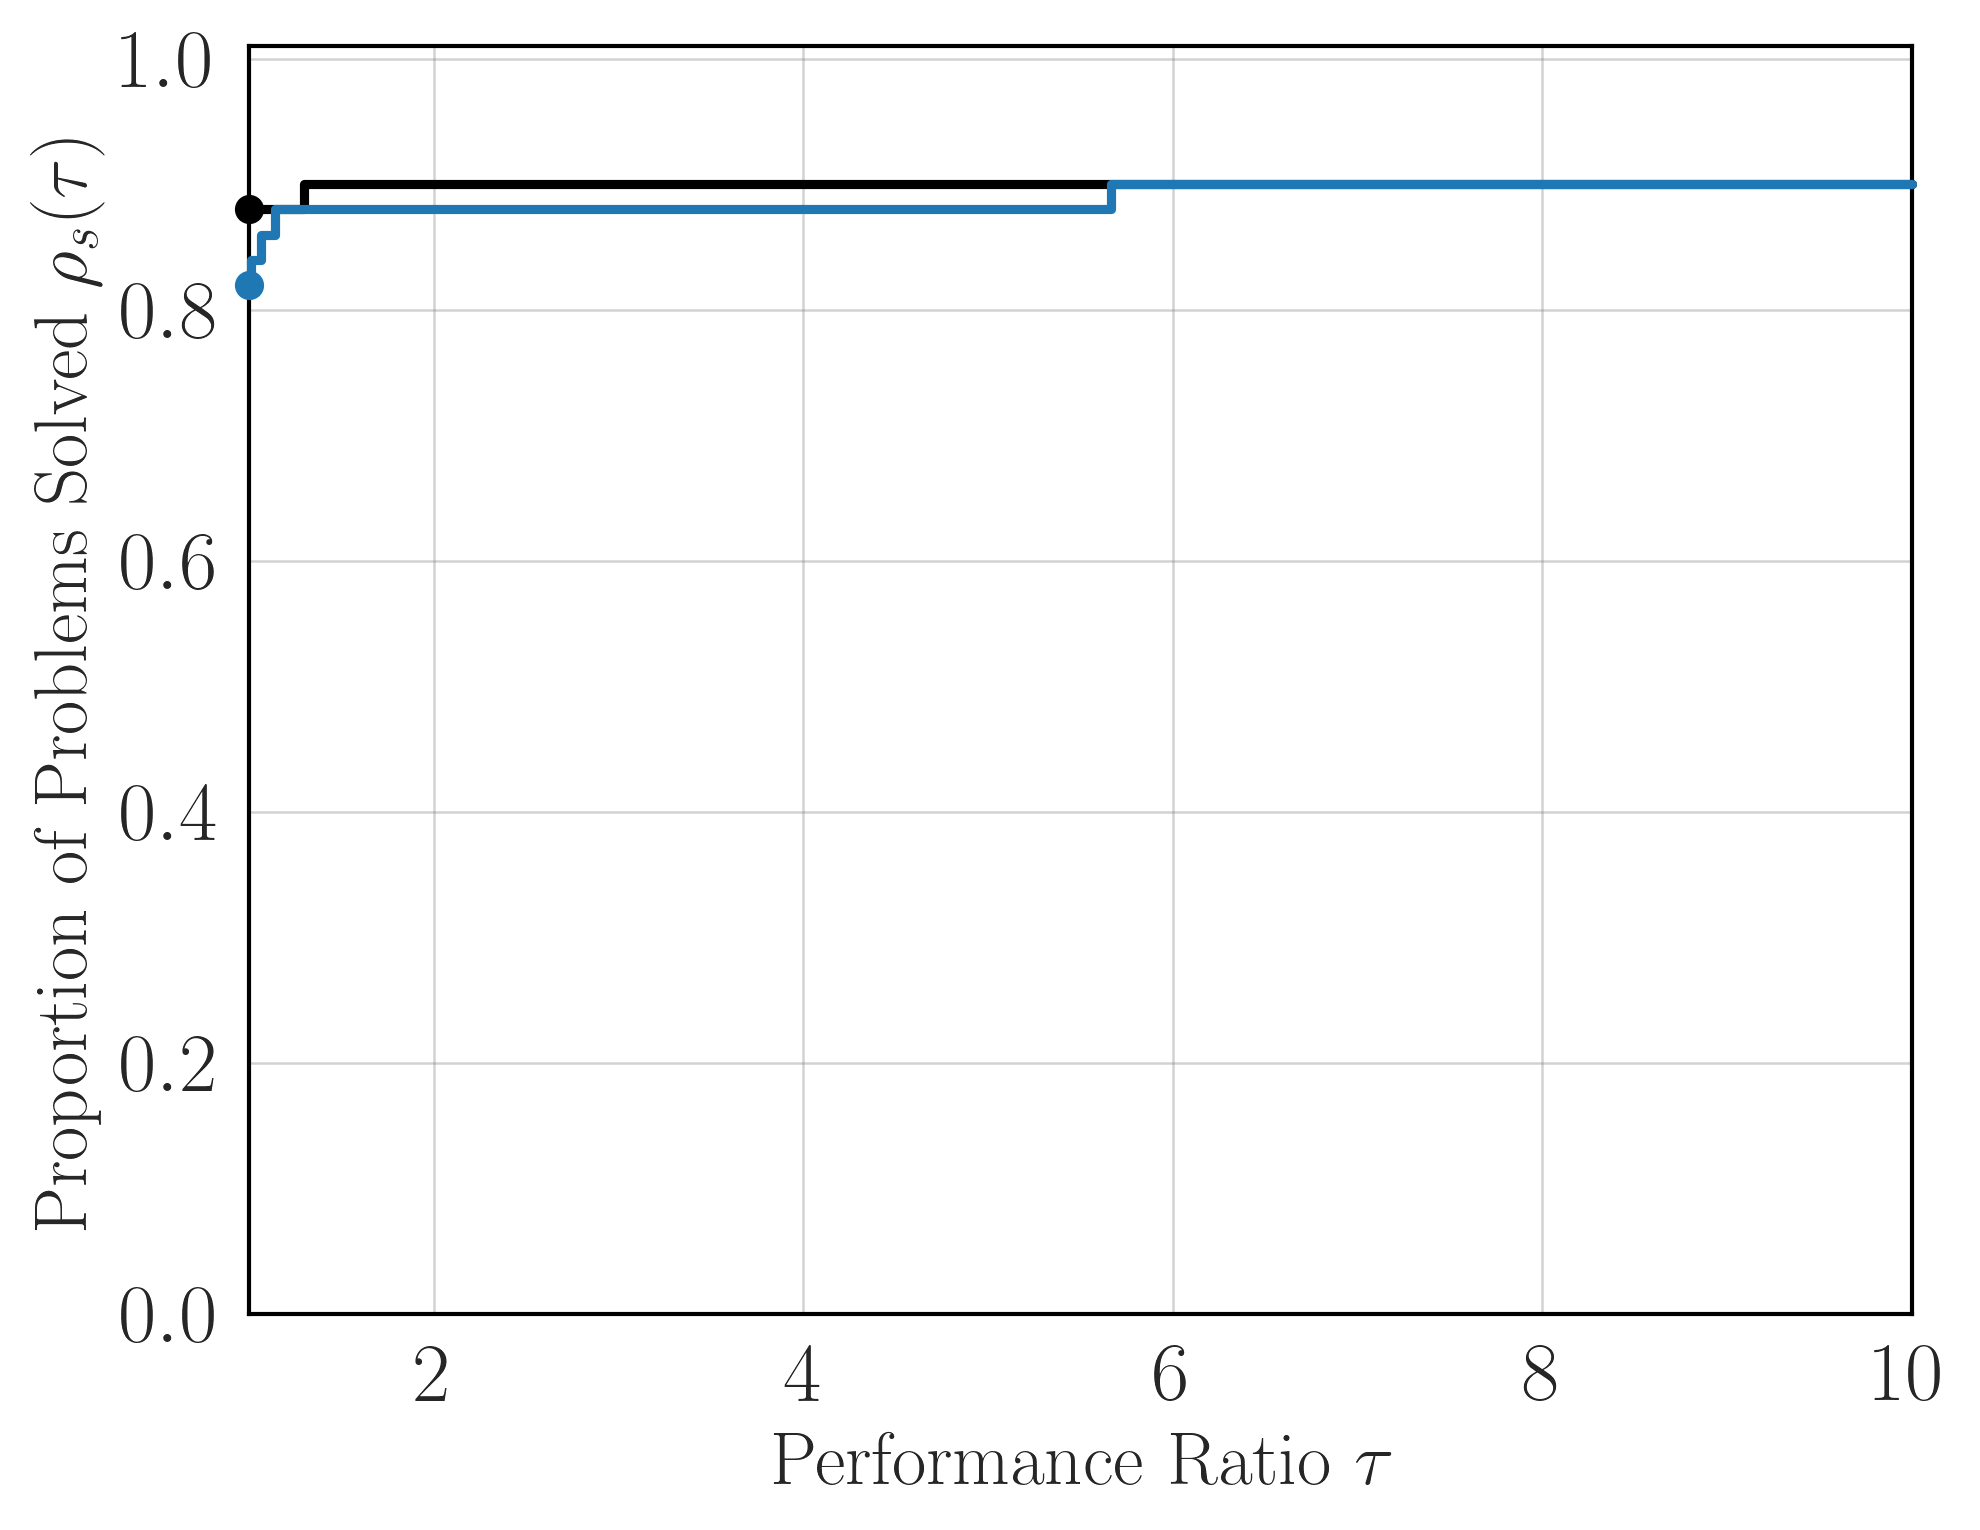

Saved figure to doc/imgs/compare/_dp_function_only_restart_gtol1e-02.pdf


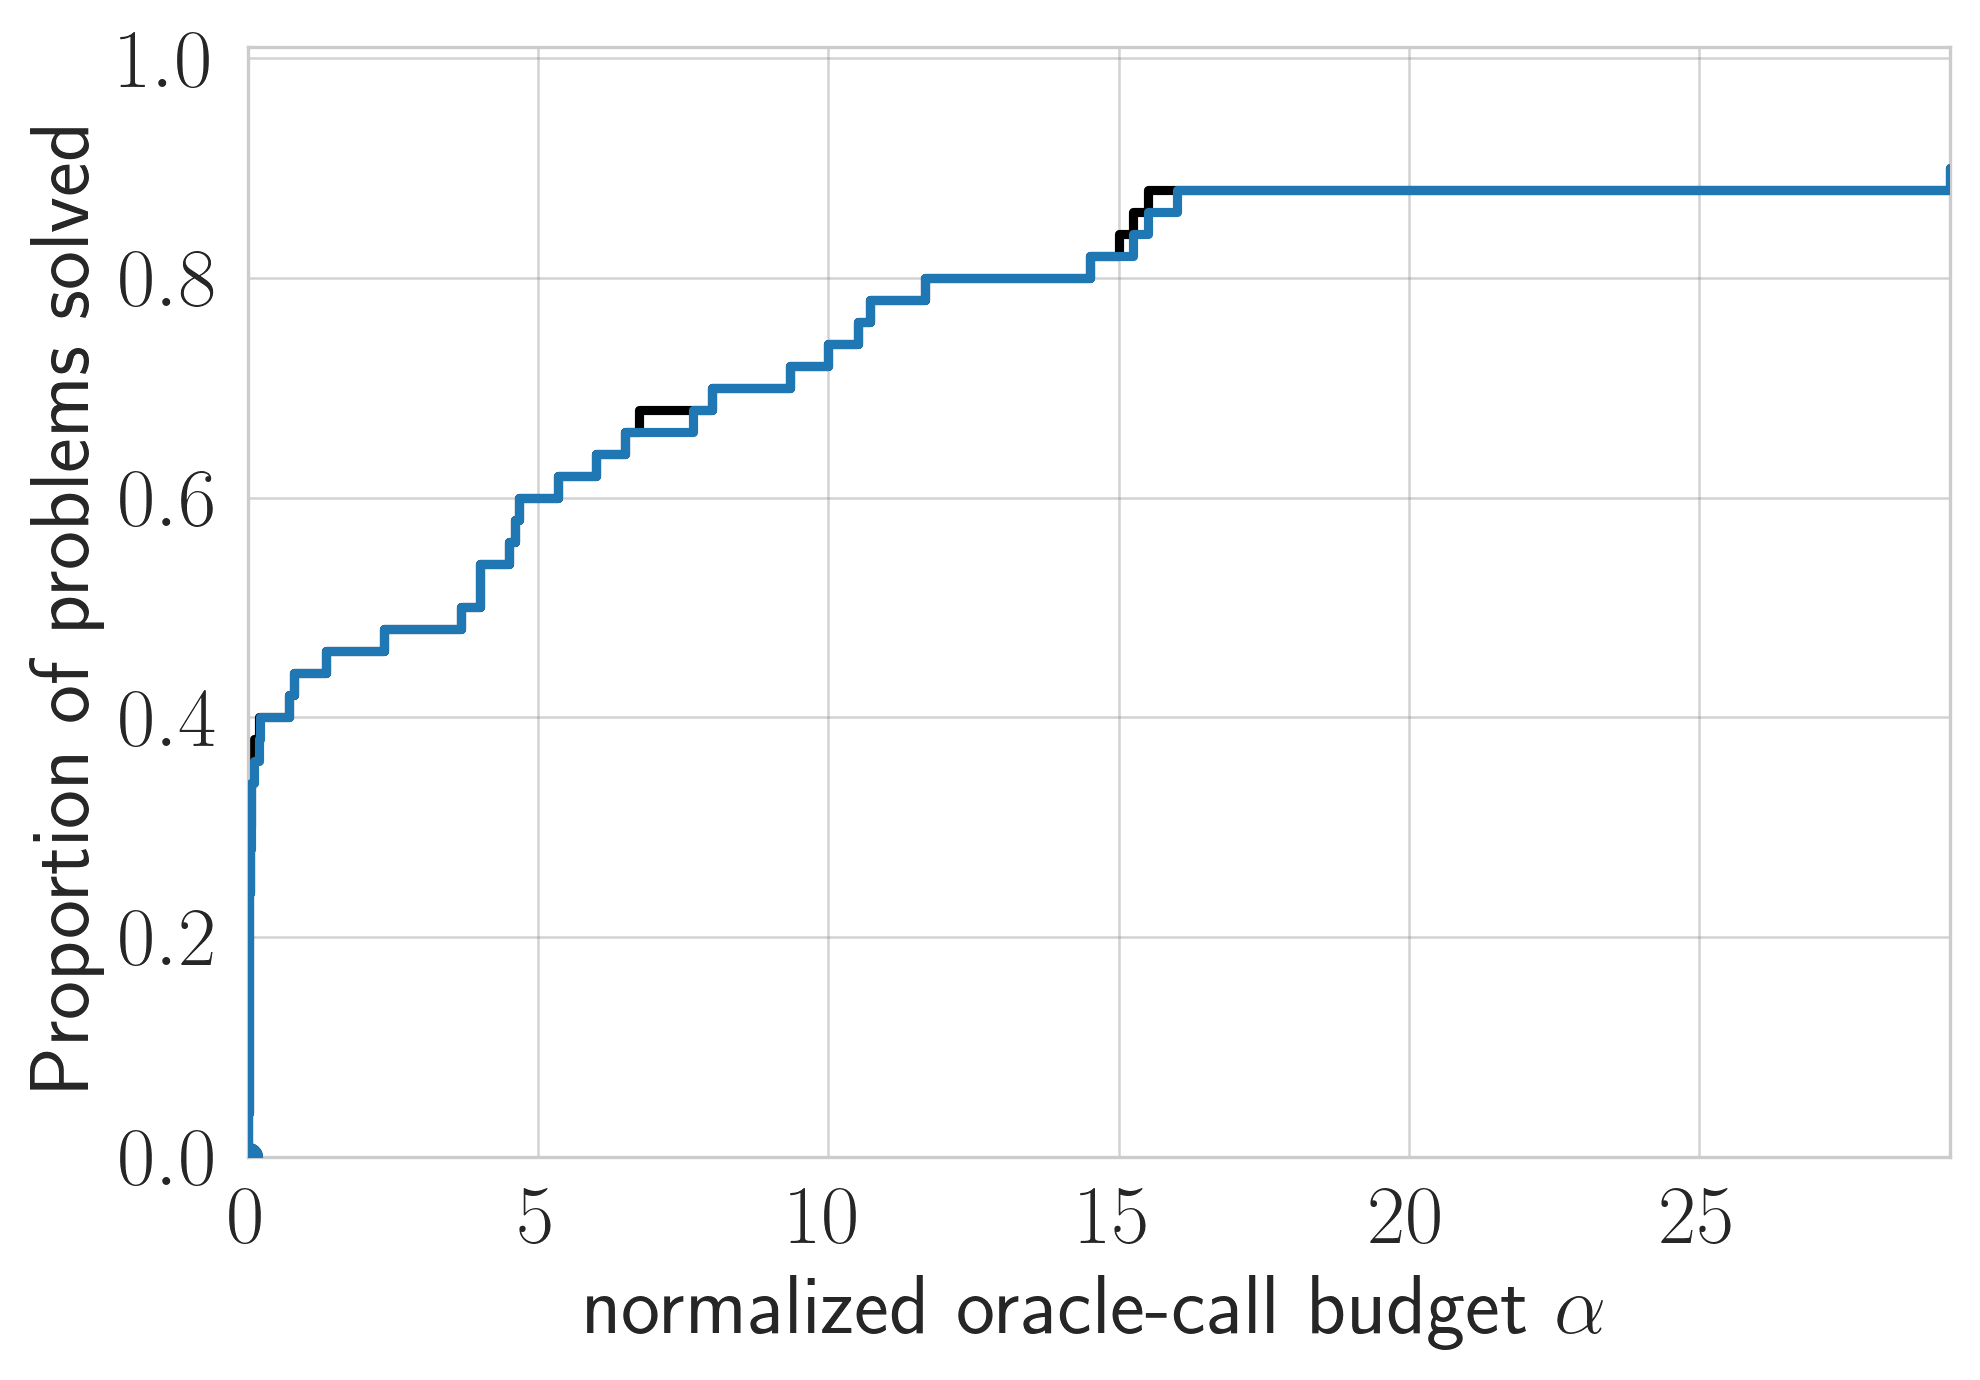

,solved (percent),"fastest, ties included (percent)"
NTRQN,90.0,82.0
NTRQN-Restart,90.0,88.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-Restart,50,0,50,0,0,5


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,5.08,4.5,10,9


Saved figure to doc/imgs/compare/_pp_noise0.001_gtol1e-02.pdf


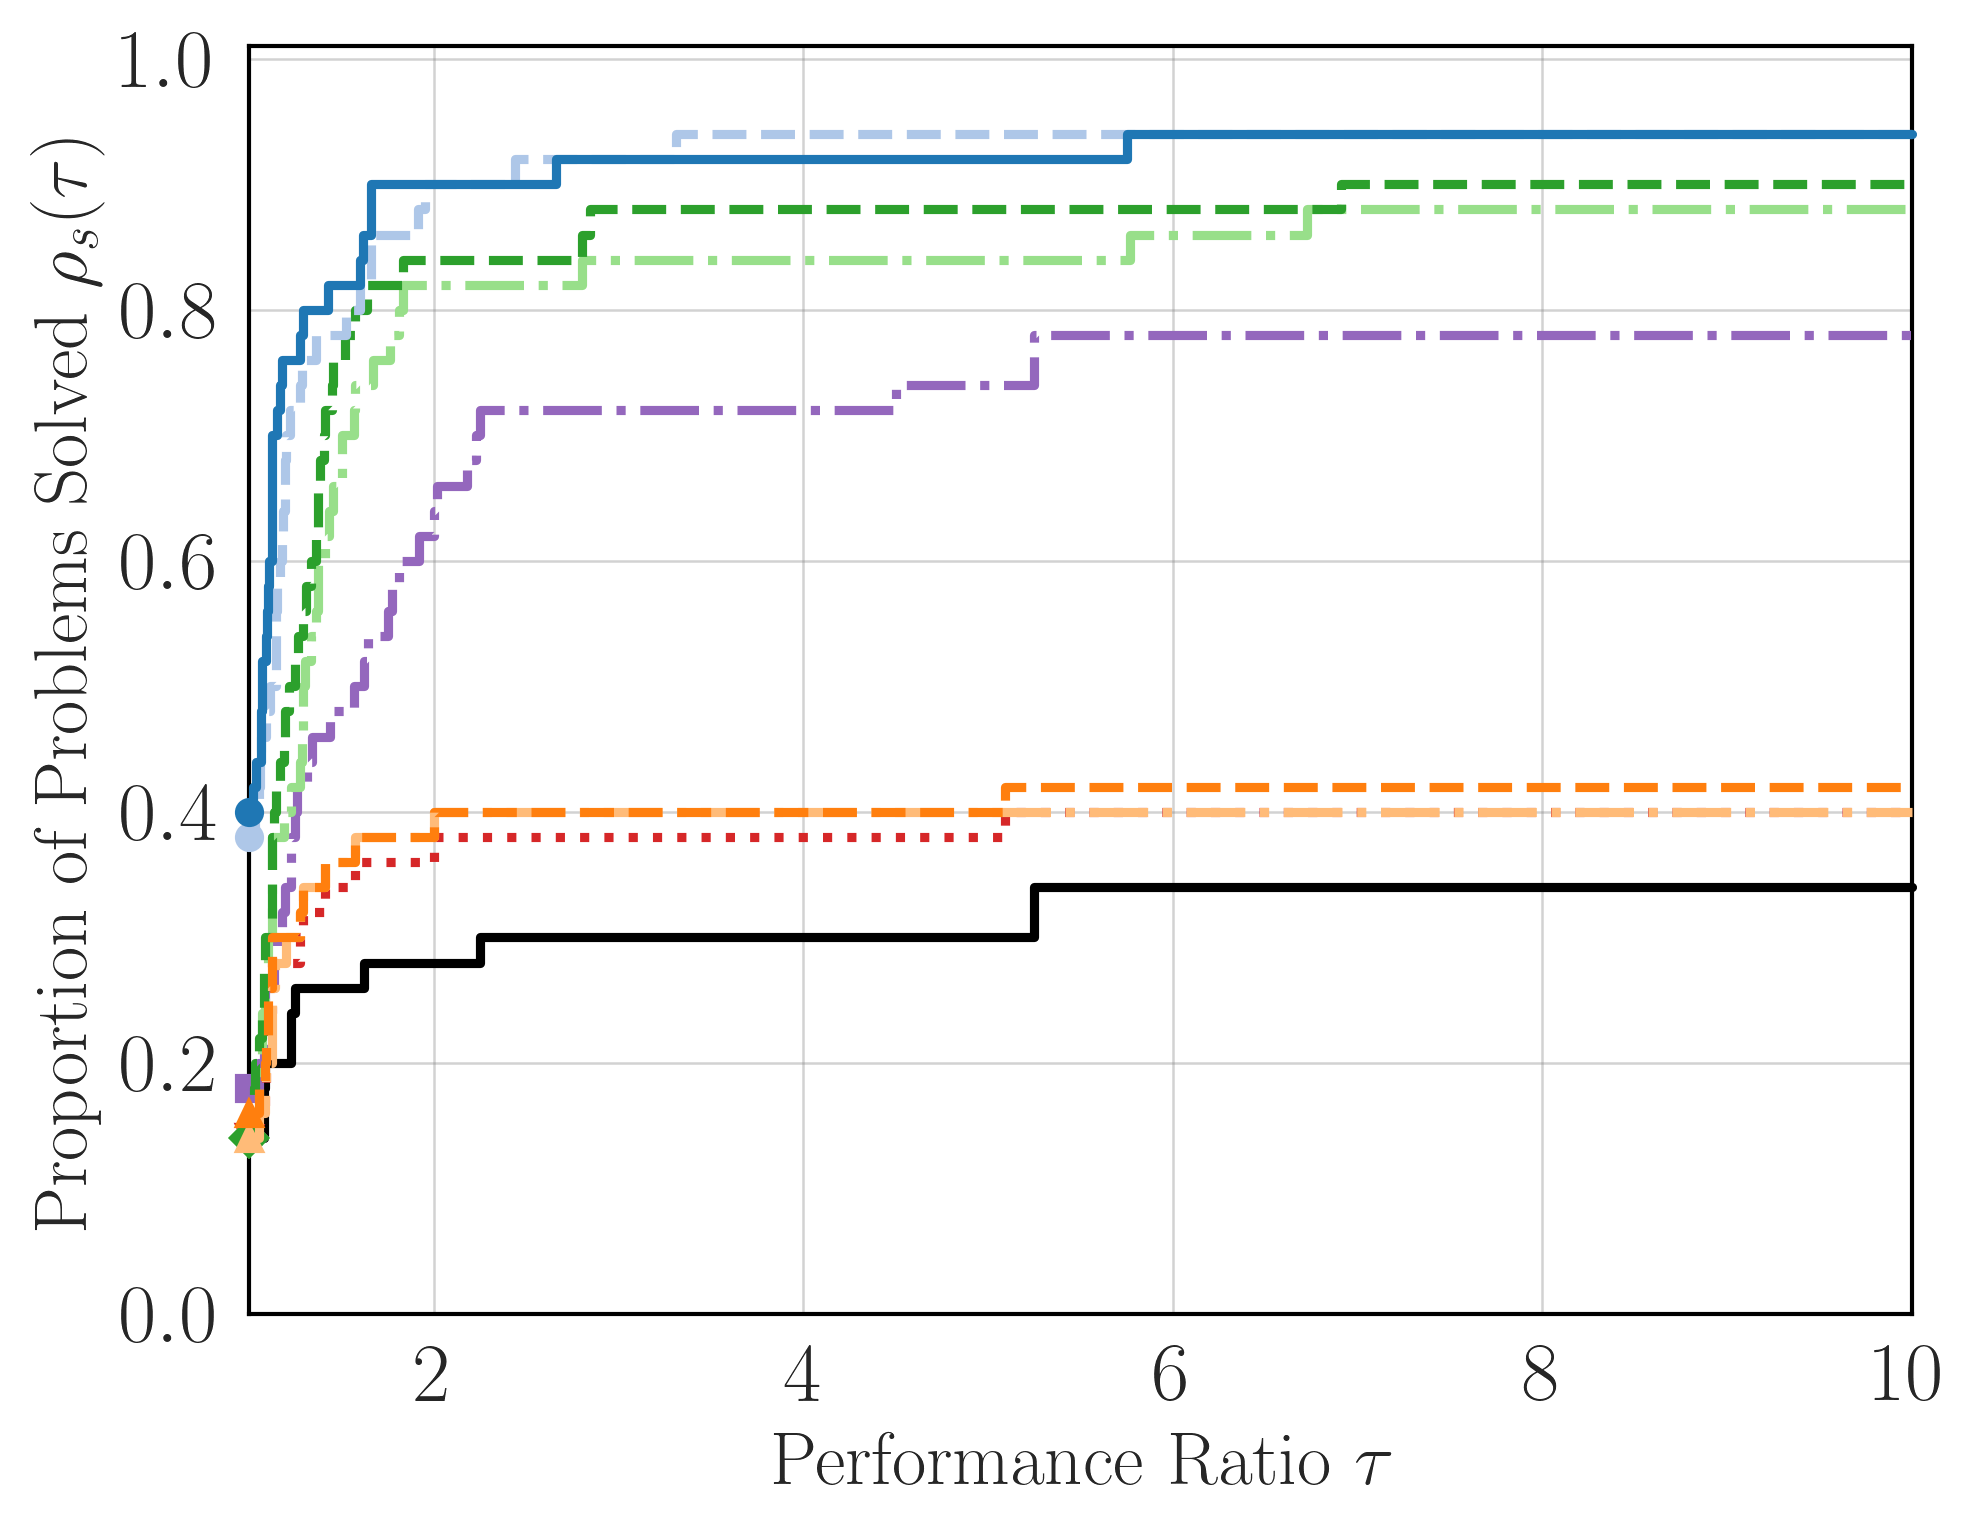

Saved figure to doc/imgs/compare/_dp_joint_noise_gtol1e-02.pdf


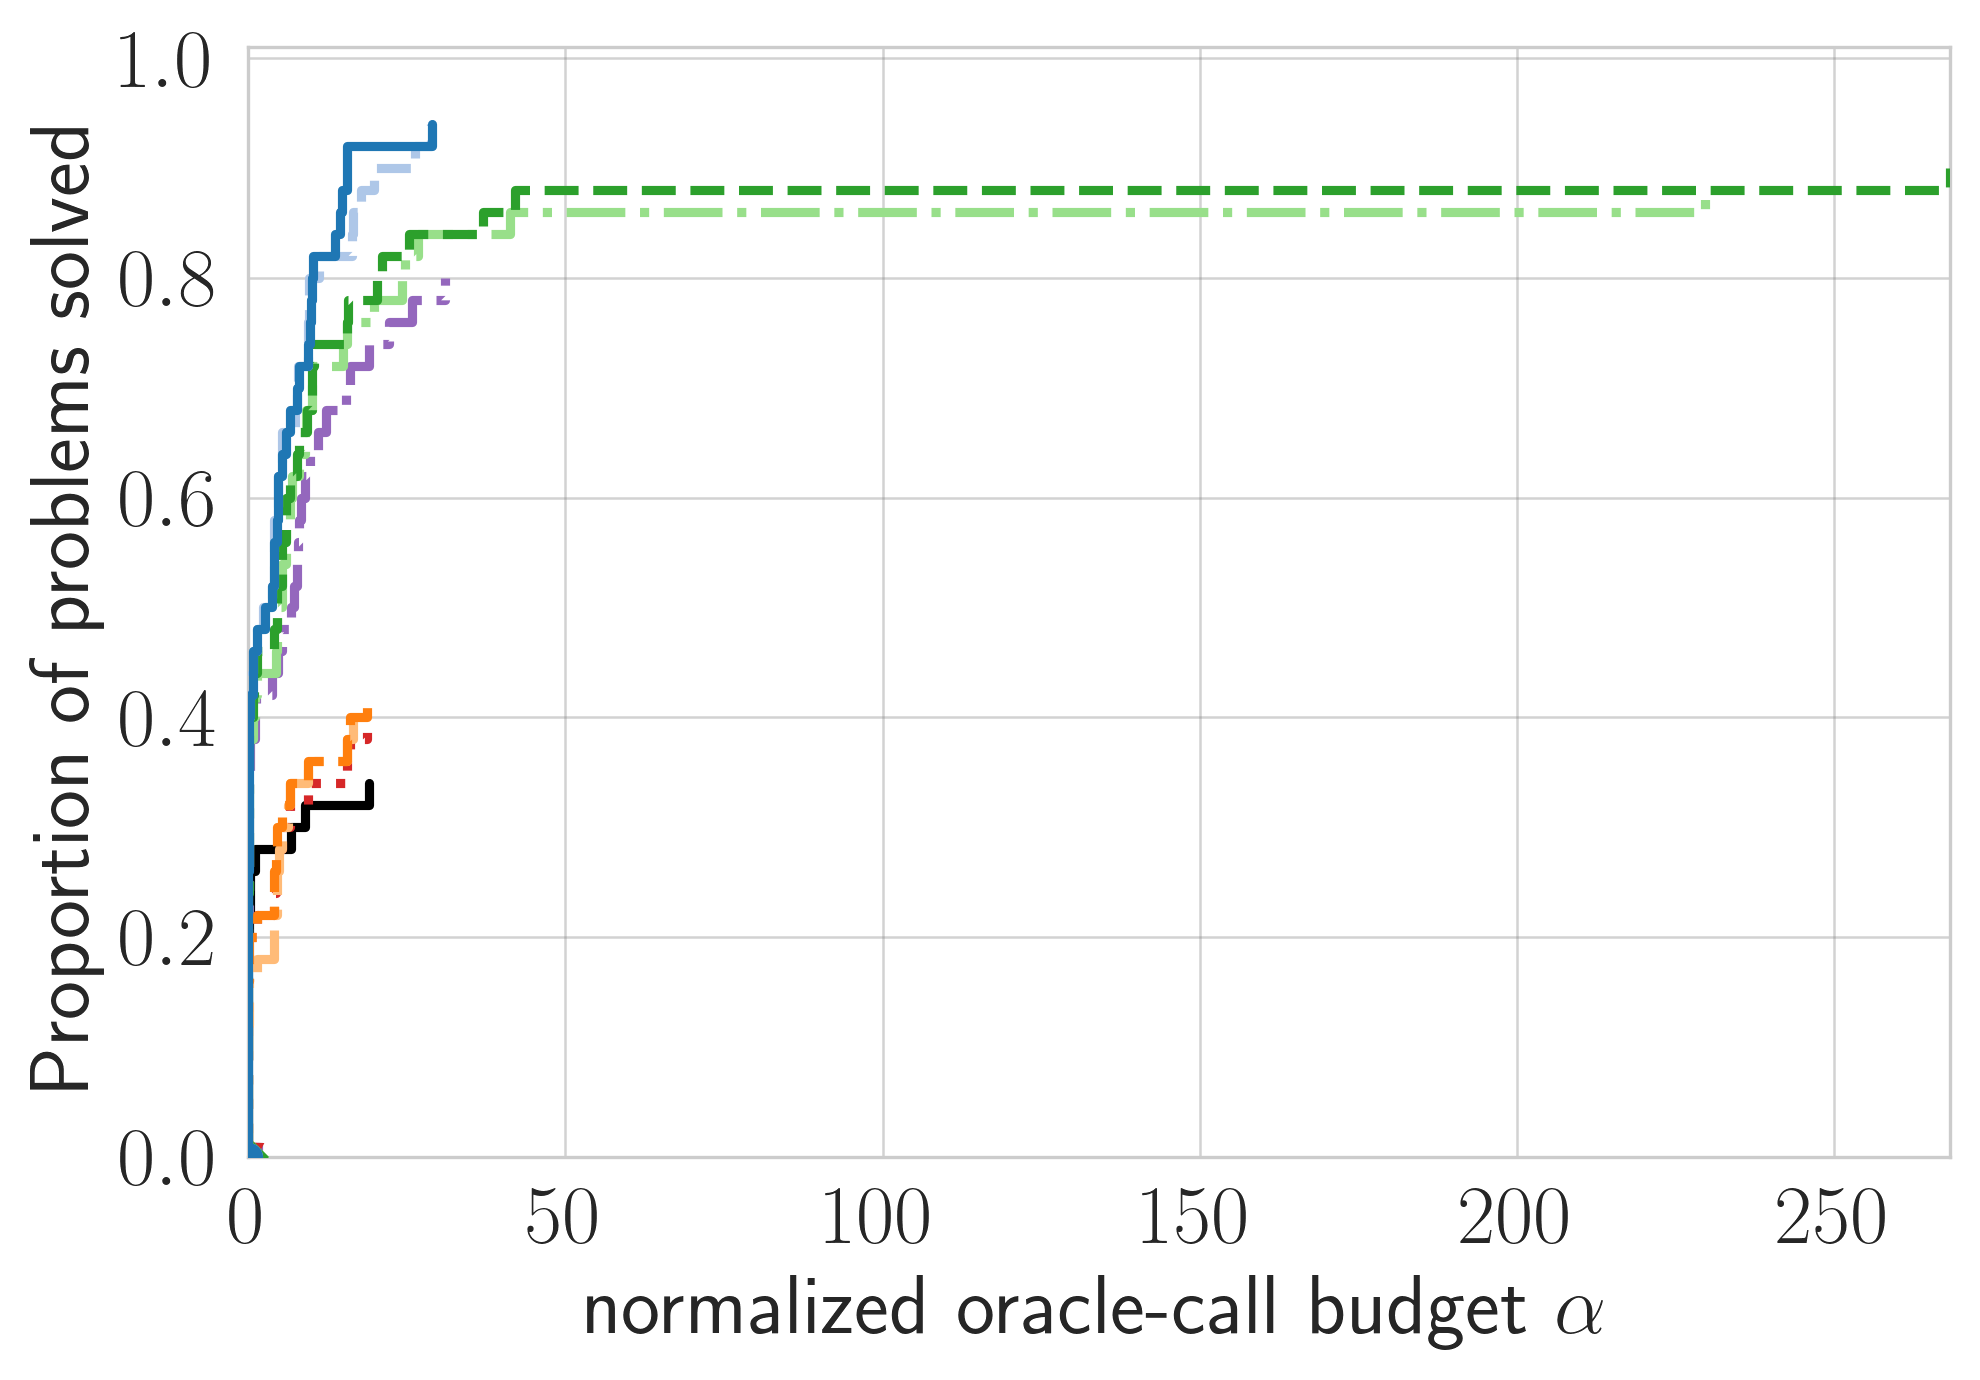

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,NTQN-Default-Termination
AKIVA (seed=0),41.0,49.0,inf,inf,47.0,45.0,inf,inf,inf
ALLINITU (seed=0),23.0,23.0,22.0,24.0,20.0,22.0,22.0,23.0,inf
ARGLINA (seed=0),8.0,8.0,10.0,10.0,14.0,14.0,10.0,5.0,5.0
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,42.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,42.0
ARGTRIGLS (seed=0),539.0,479.0,inf,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),22.0,28.0,inf,inf,inf,inf,inf,27.0,27.0
BA-L1LS (seed=0),41.0,37.0,inf,inf,38.0,38.0,inf,60.0,60.0
BA-L1SPLS (seed=0),46.0,46.0,inf,inf,55.0,60.0,inf,72.0,inf
BARD (seed=0),18.0,16.0,18.0,18.0,18.0,18.0,18.0,36.0,36.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,94.0,40.0
NTRQN-MS,94.0,38.0
Line,42.0,16.0
Line-MS,40.0,14.0
Reg,90.0,14.0
Reg-Sec,88.0,14.0
SciPy,40.0,14.0
NTQN,80.0,18.0
NTQN-Default-Termination,34.0,14.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,3
NTRQN-MS,50,0,50,0,0,3
Line,50,0,50,0,0,29
Line-MS,50,0,50,0,0,30
Reg,50,0,50,0,0,6
Reg-Sec,50,0,50,0,0,6
SciPy,50,0,50,0,0,2
NTQN,50,0,50,0,0,4
NTQN-Default-Termination,50,0,50,0,0,2


flag,0,1,4,6
method,,,,
NTQN,40,4,0,6
NTQN-Default-Termination,19,2,26,3


Saved figure to doc/imgs/compare/_pp_eps_under_gtol1e-02.pdf


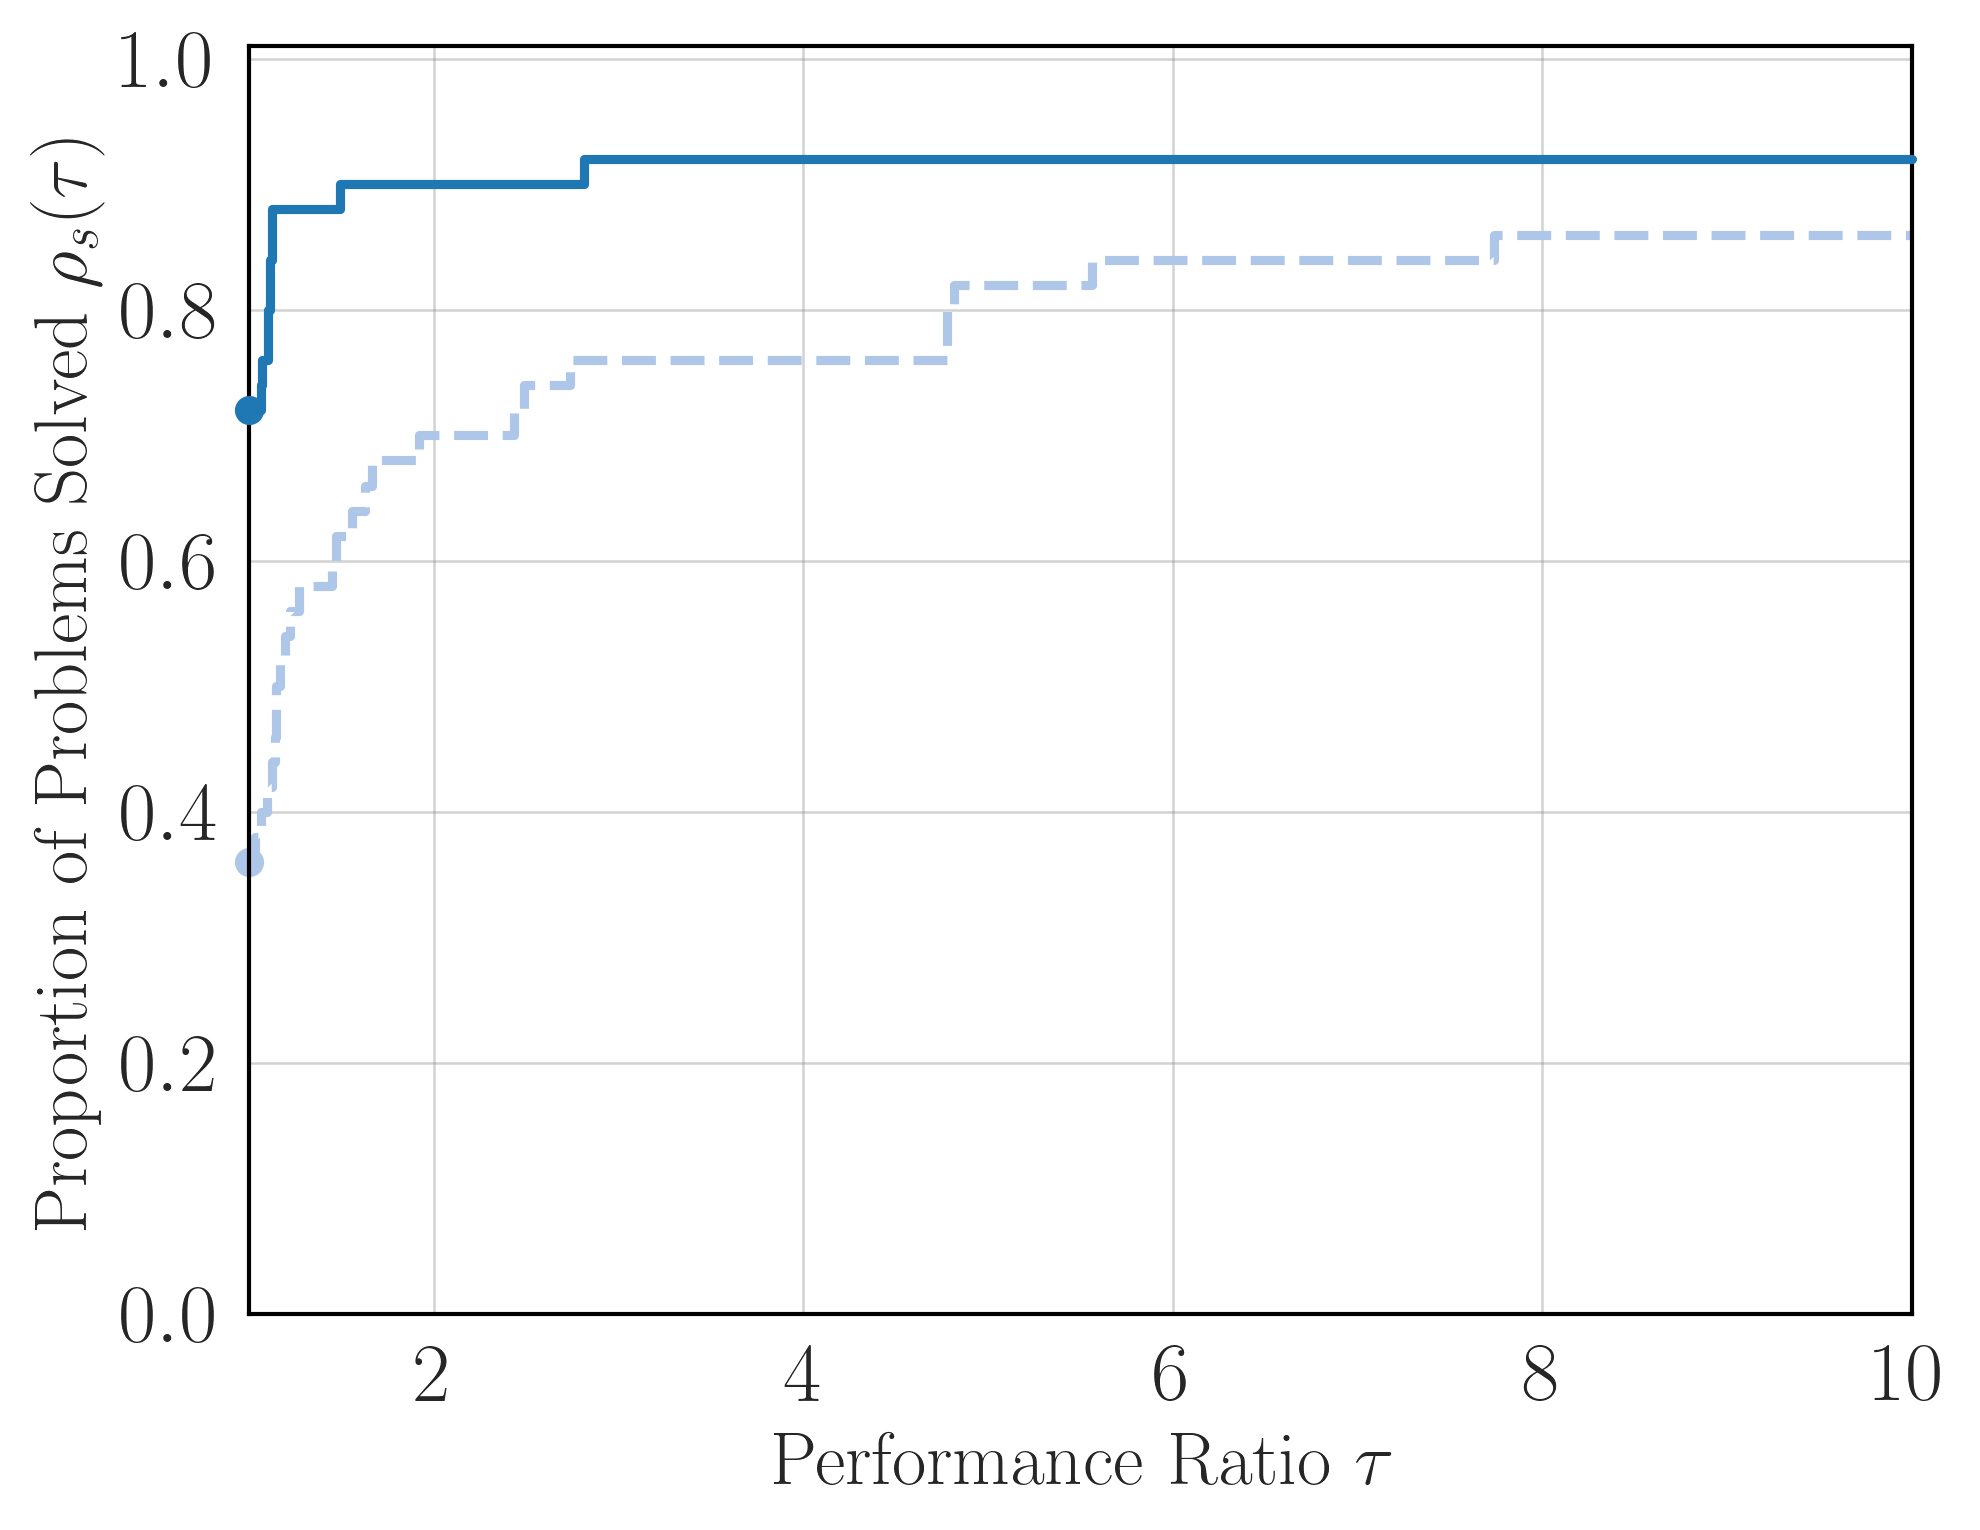

Saved figure to doc/imgs/compare/_dp_eps_under_gtol1e-02.pdf


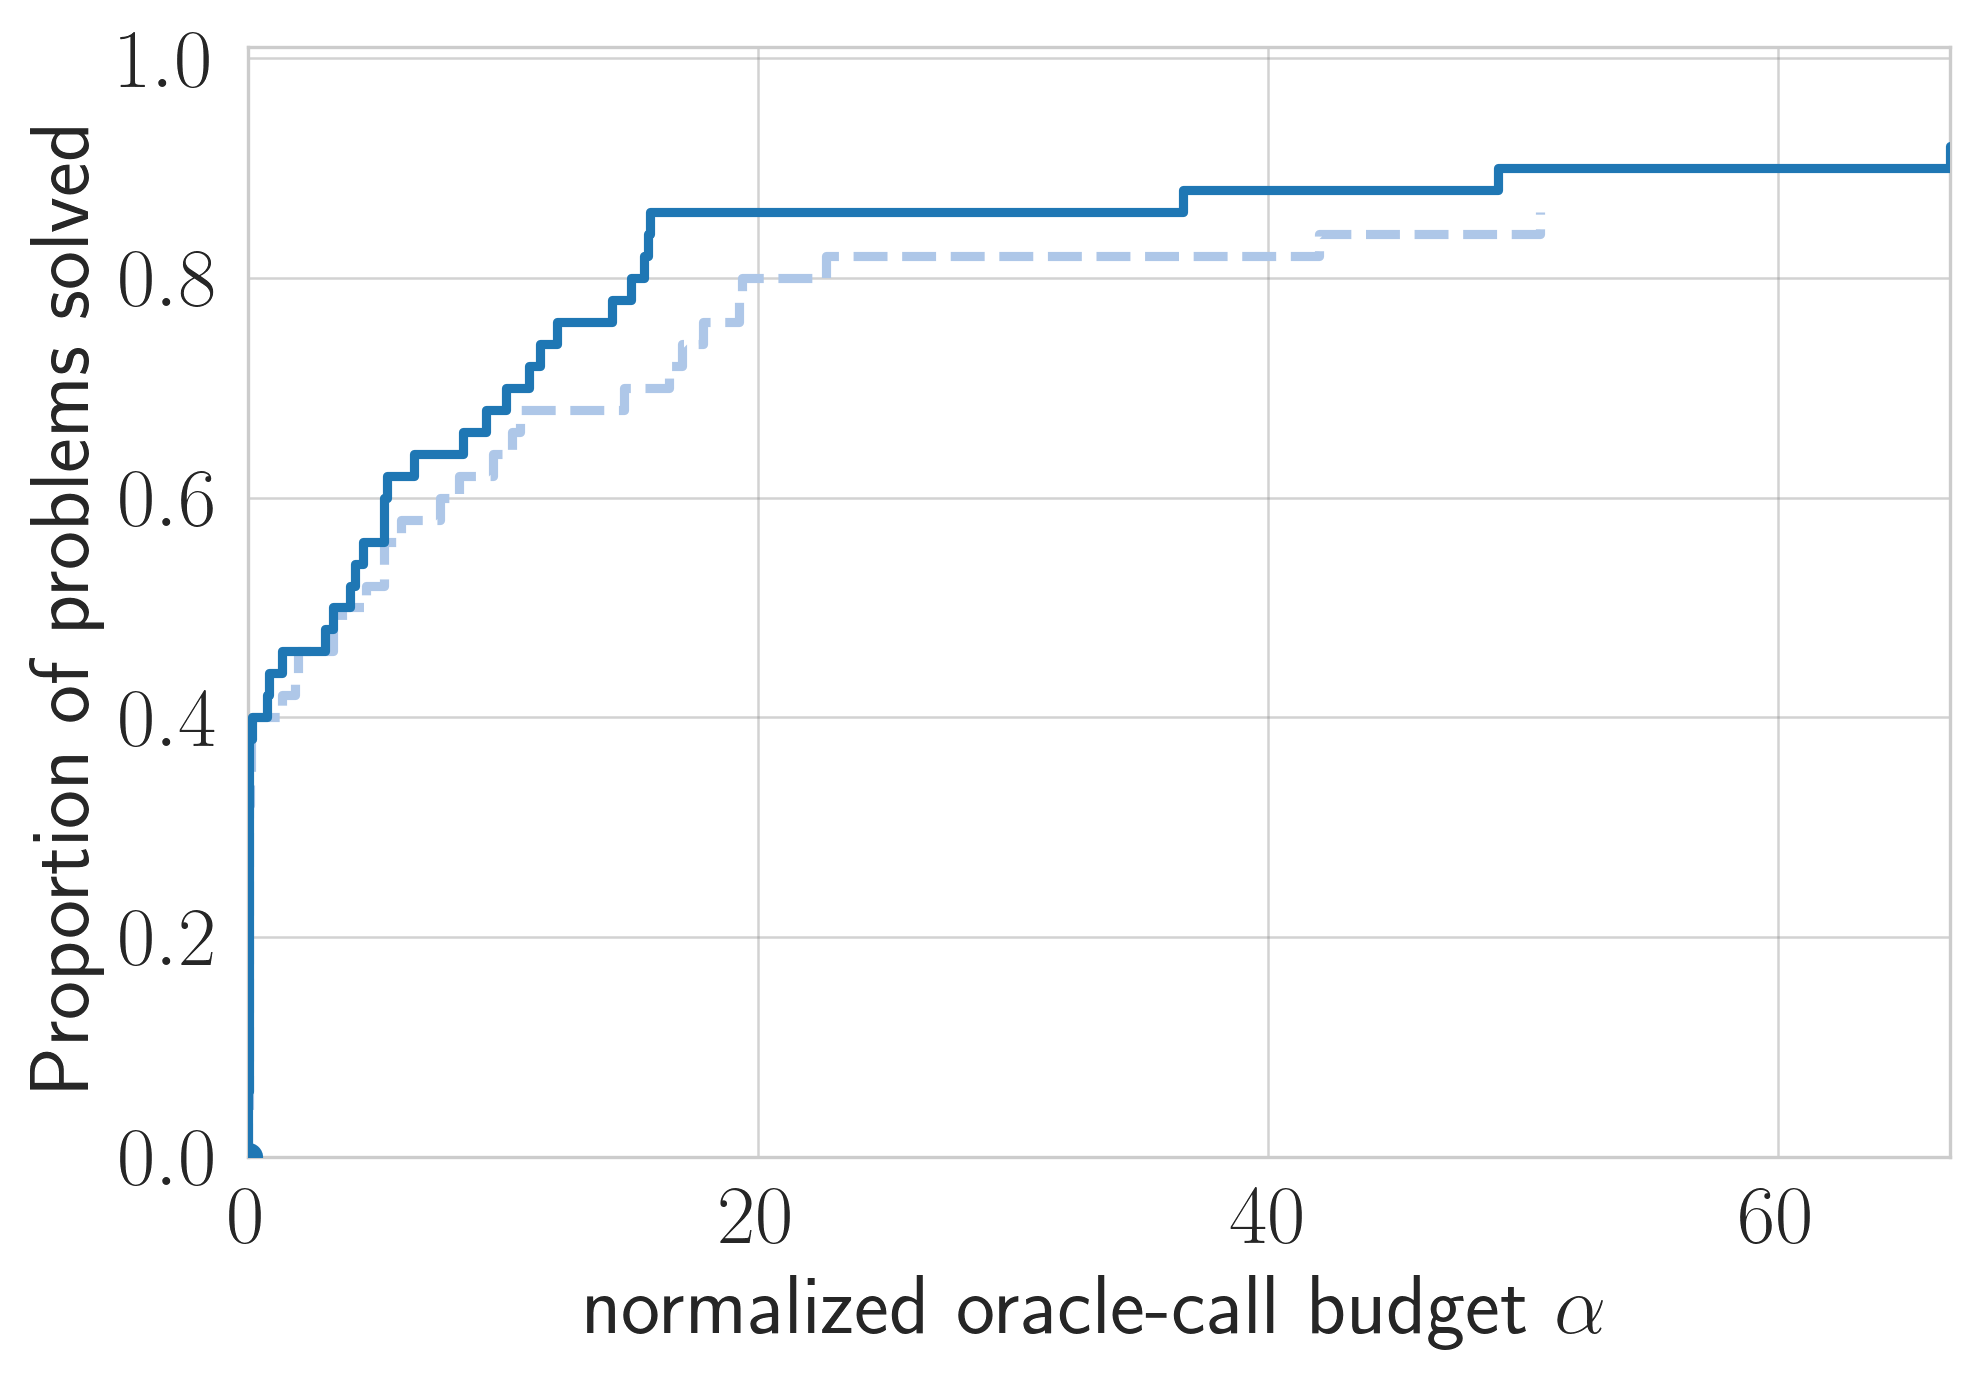

,NTRQN,NTRQN-MS
AKIVA (seed=0),47.0,68.0
ALLINITU (seed=0),21.0,23.0
ARGLINA (seed=0),6.0,6.0
ARGLINB (seed=0),8.0,8.0
ARGLINC (seed=0),8.0,8.0
ARGTRIGLS (seed=0),2032.0,3896.0
ARWHEAD (seed=0),54.0,88.0
BA-L1LS (seed=0),43.0,107.0
BA-L1SPLS (seed=0),46.0,112.0
BARD (seed=0),18.0,30.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,92.0,72.0
NTRQN-MS,86.0,36.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,4
NTRQN-MS,50,0,50,0,0,7


Saved figure to doc/imgs/compare/_pp_eps_nominal_gtol1e-02.pdf


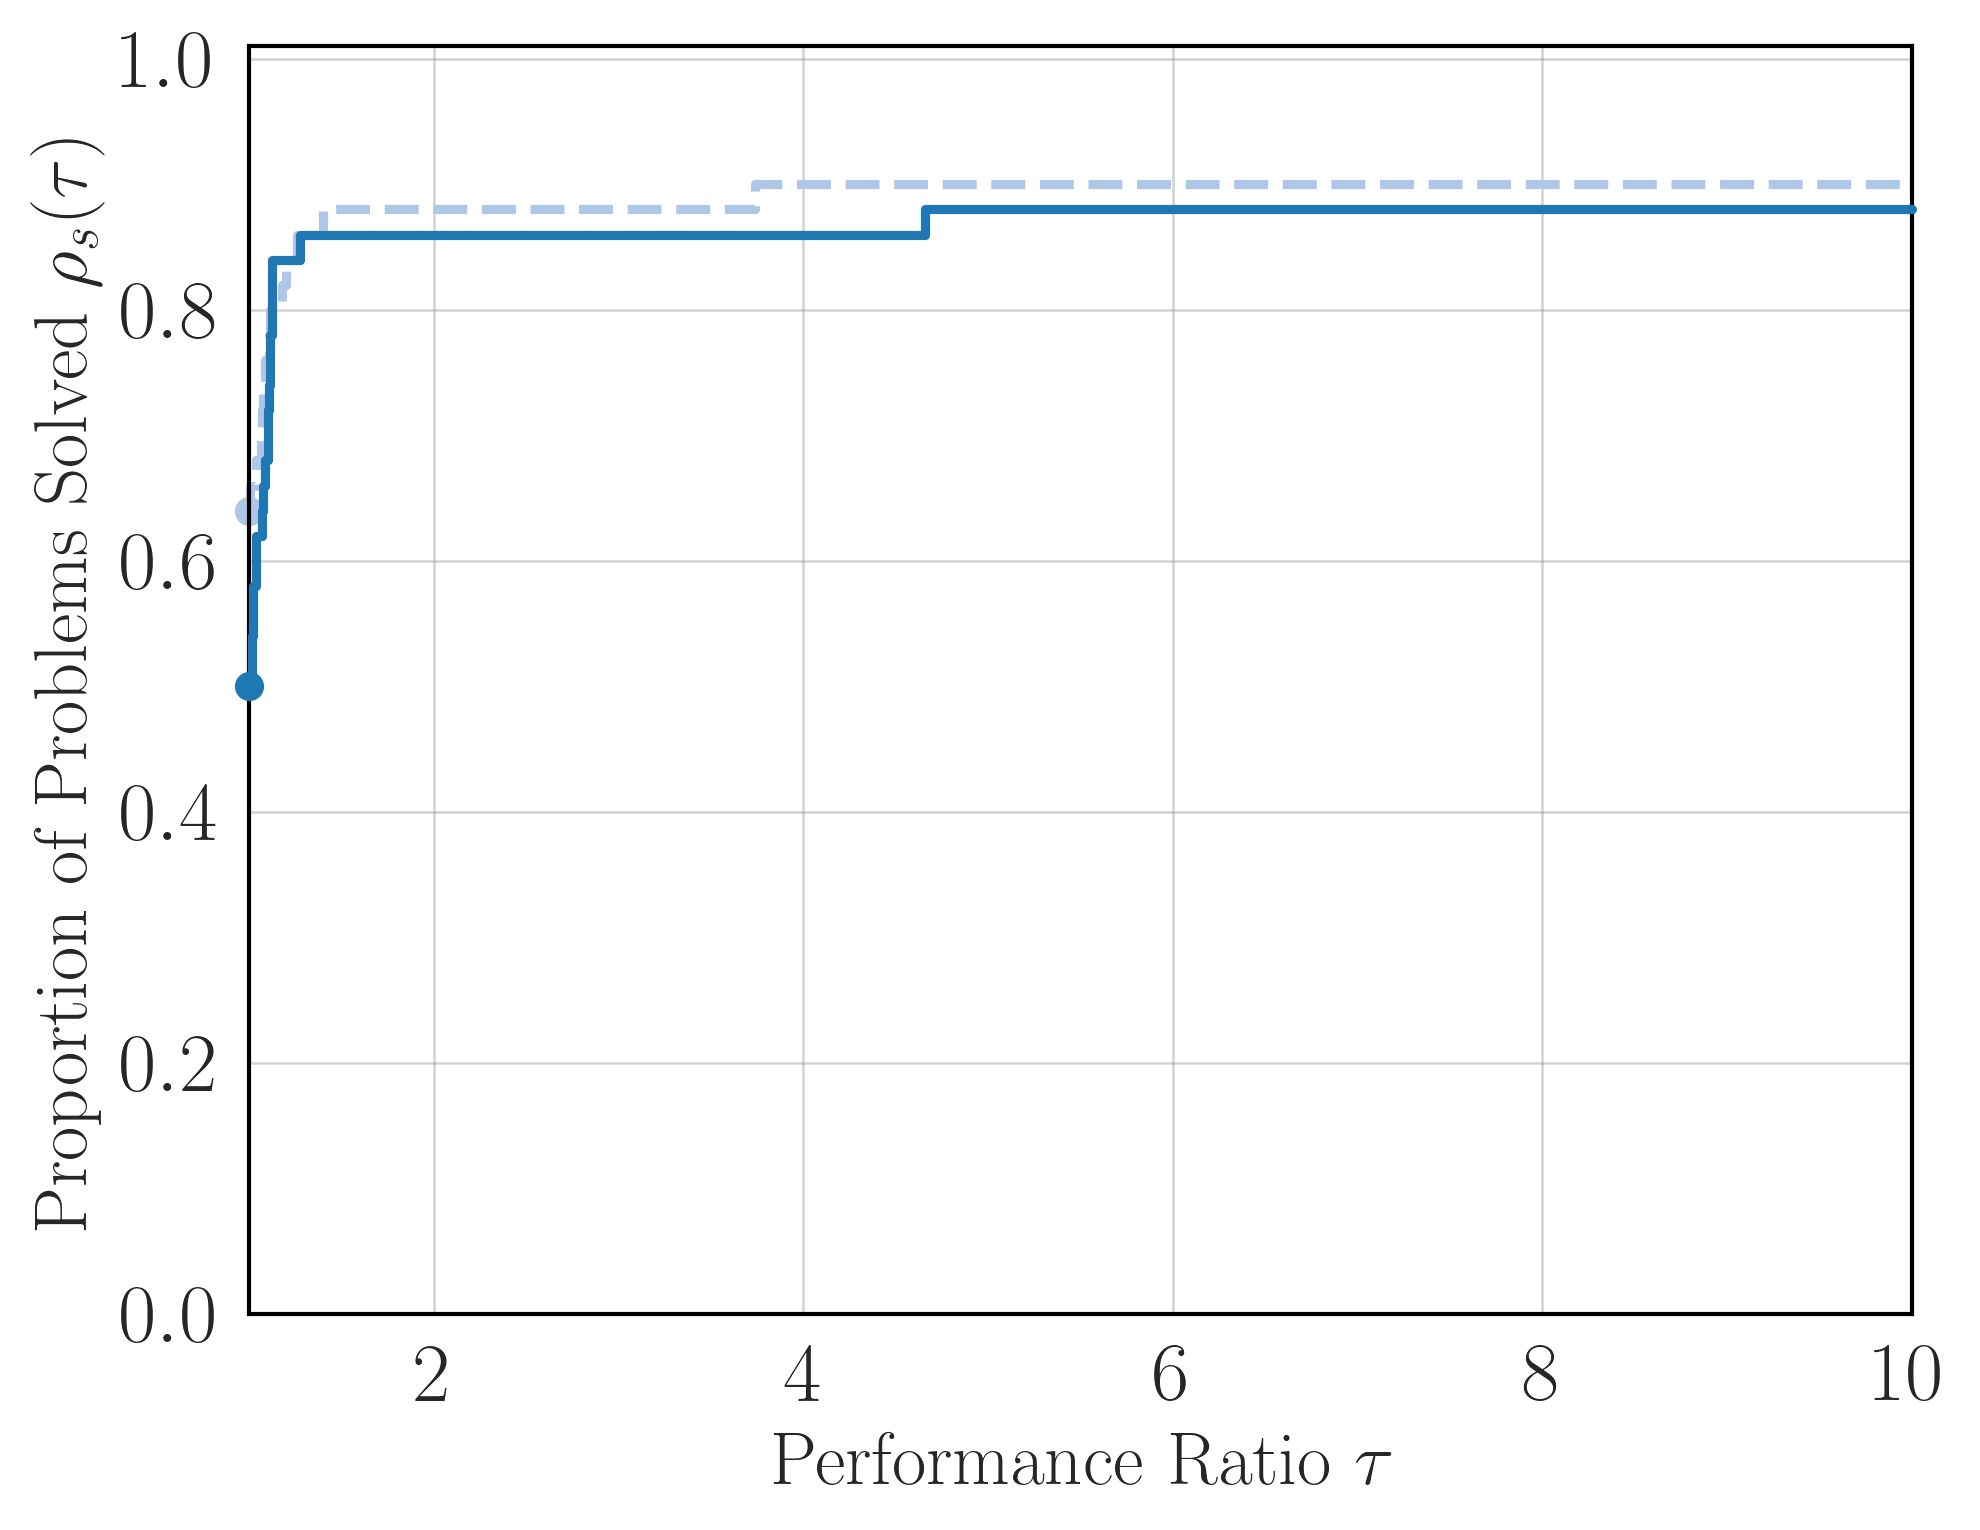

Saved figure to doc/imgs/compare/_dp_eps_nominal_gtol1e-02.pdf


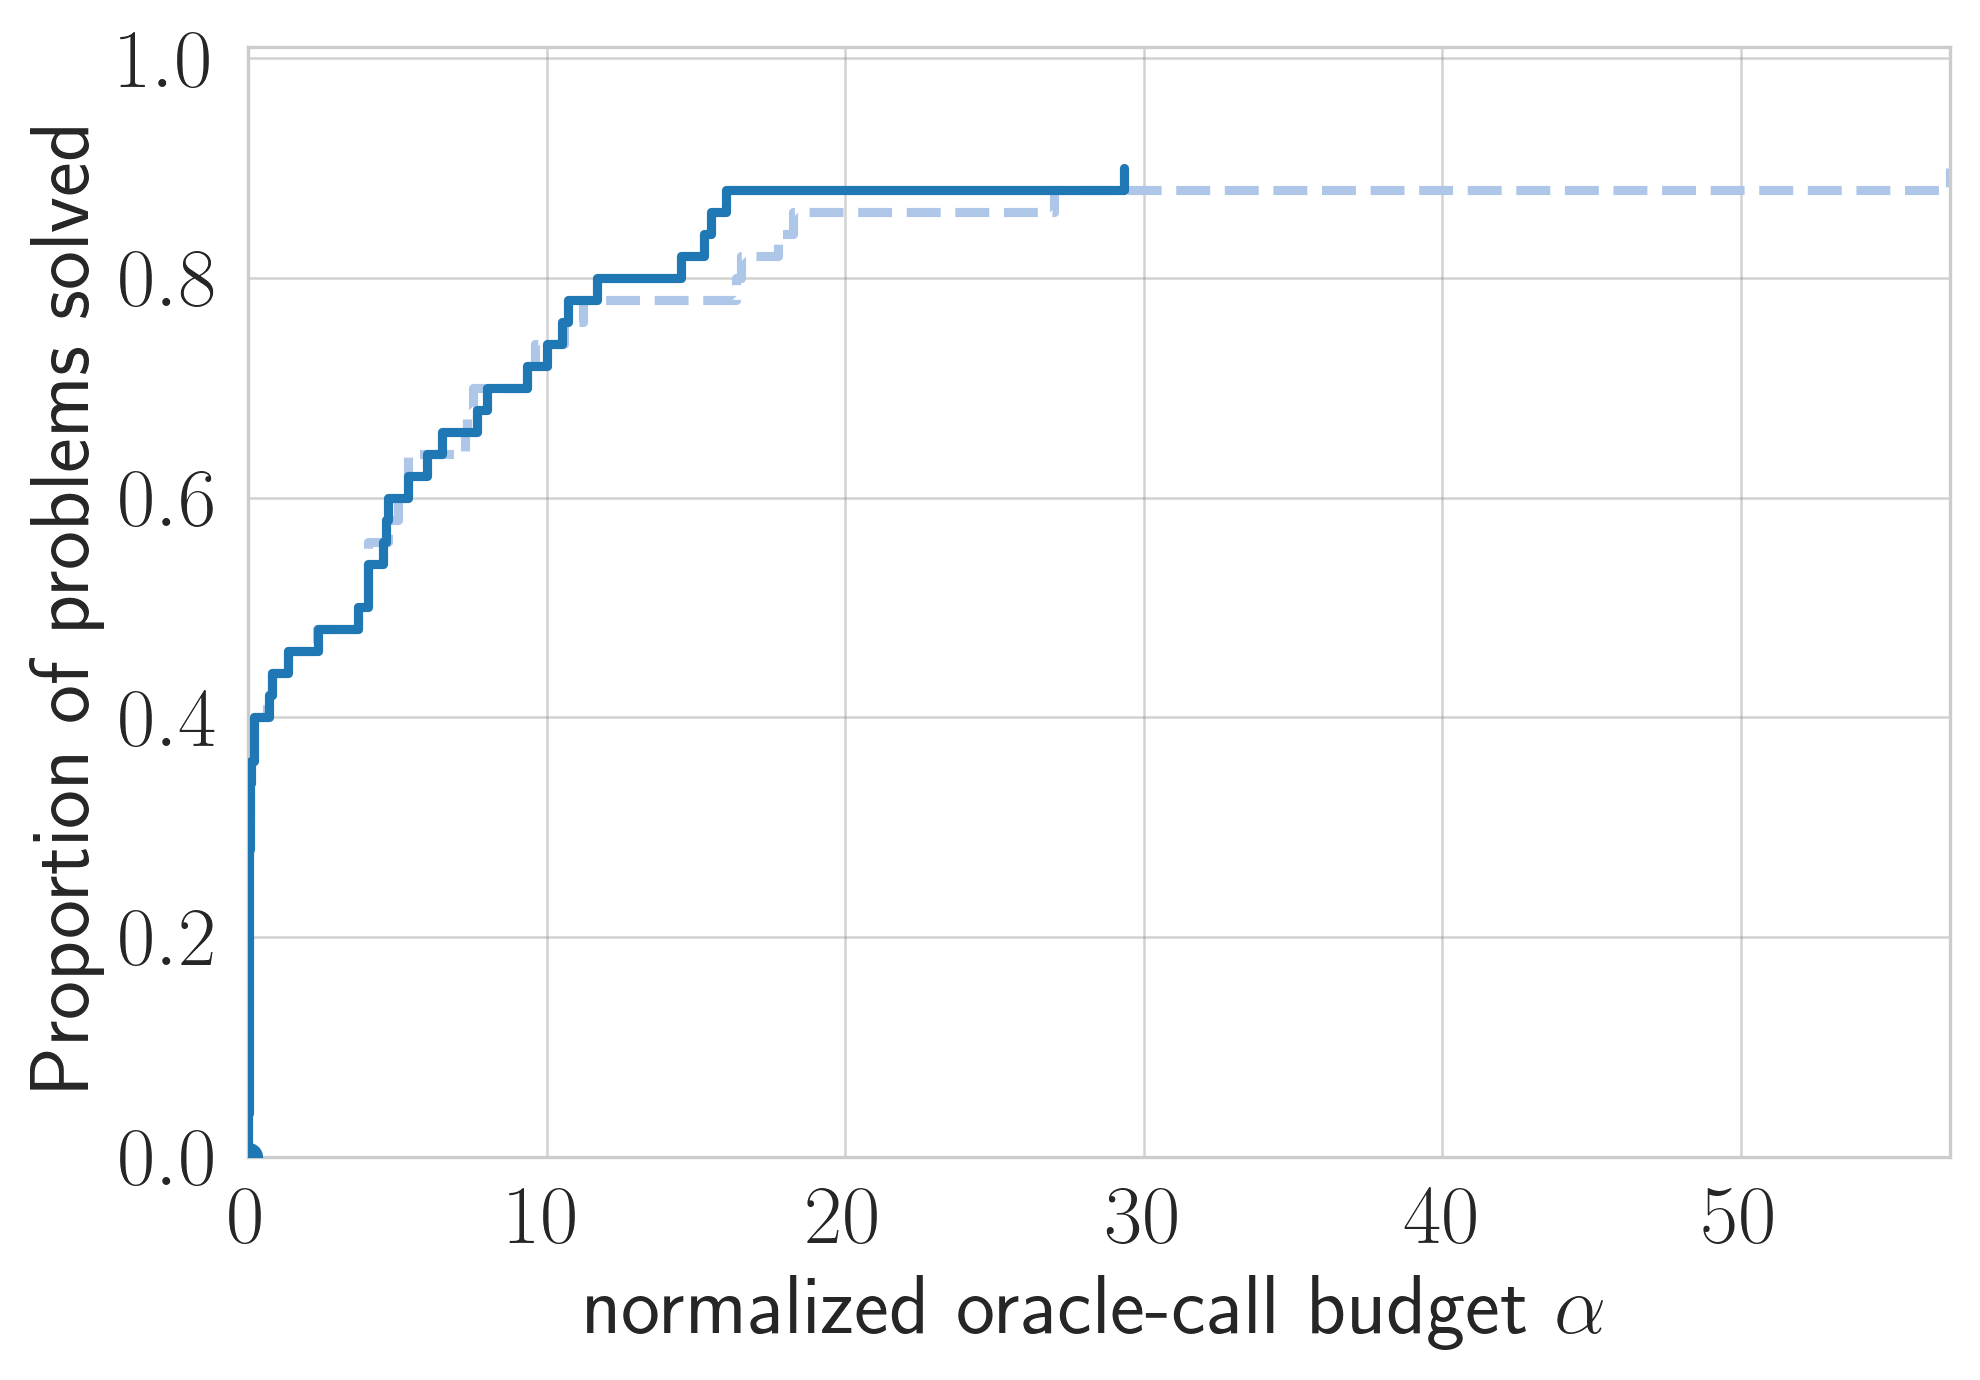

,NTRQN,NTRQN-MS
AKIVA (seed=0),35.0,49.0
ALLINITU (seed=0),23.0,25.0
ARGLINA (seed=0),6.0,6.0
ARGLINB (seed=0),8.0,8.0
ARGLINC (seed=0),8.0,8.0
ARGTRIGLS (seed=0),471.0,465.0
ARWHEAD (seed=0),26.0,28.0
BA-L1LS (seed=0),41.0,37.0
BA-L1SPLS (seed=0),46.0,46.0
BARD (seed=0),18.0,16.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.0,50.0
NTRQN-MS,90.0,64.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,5
NTRQN-MS,50,0,50,0,0,5


Saved figure to doc/imgs/compare/_pp_eps_over_gtol1e-02.pdf


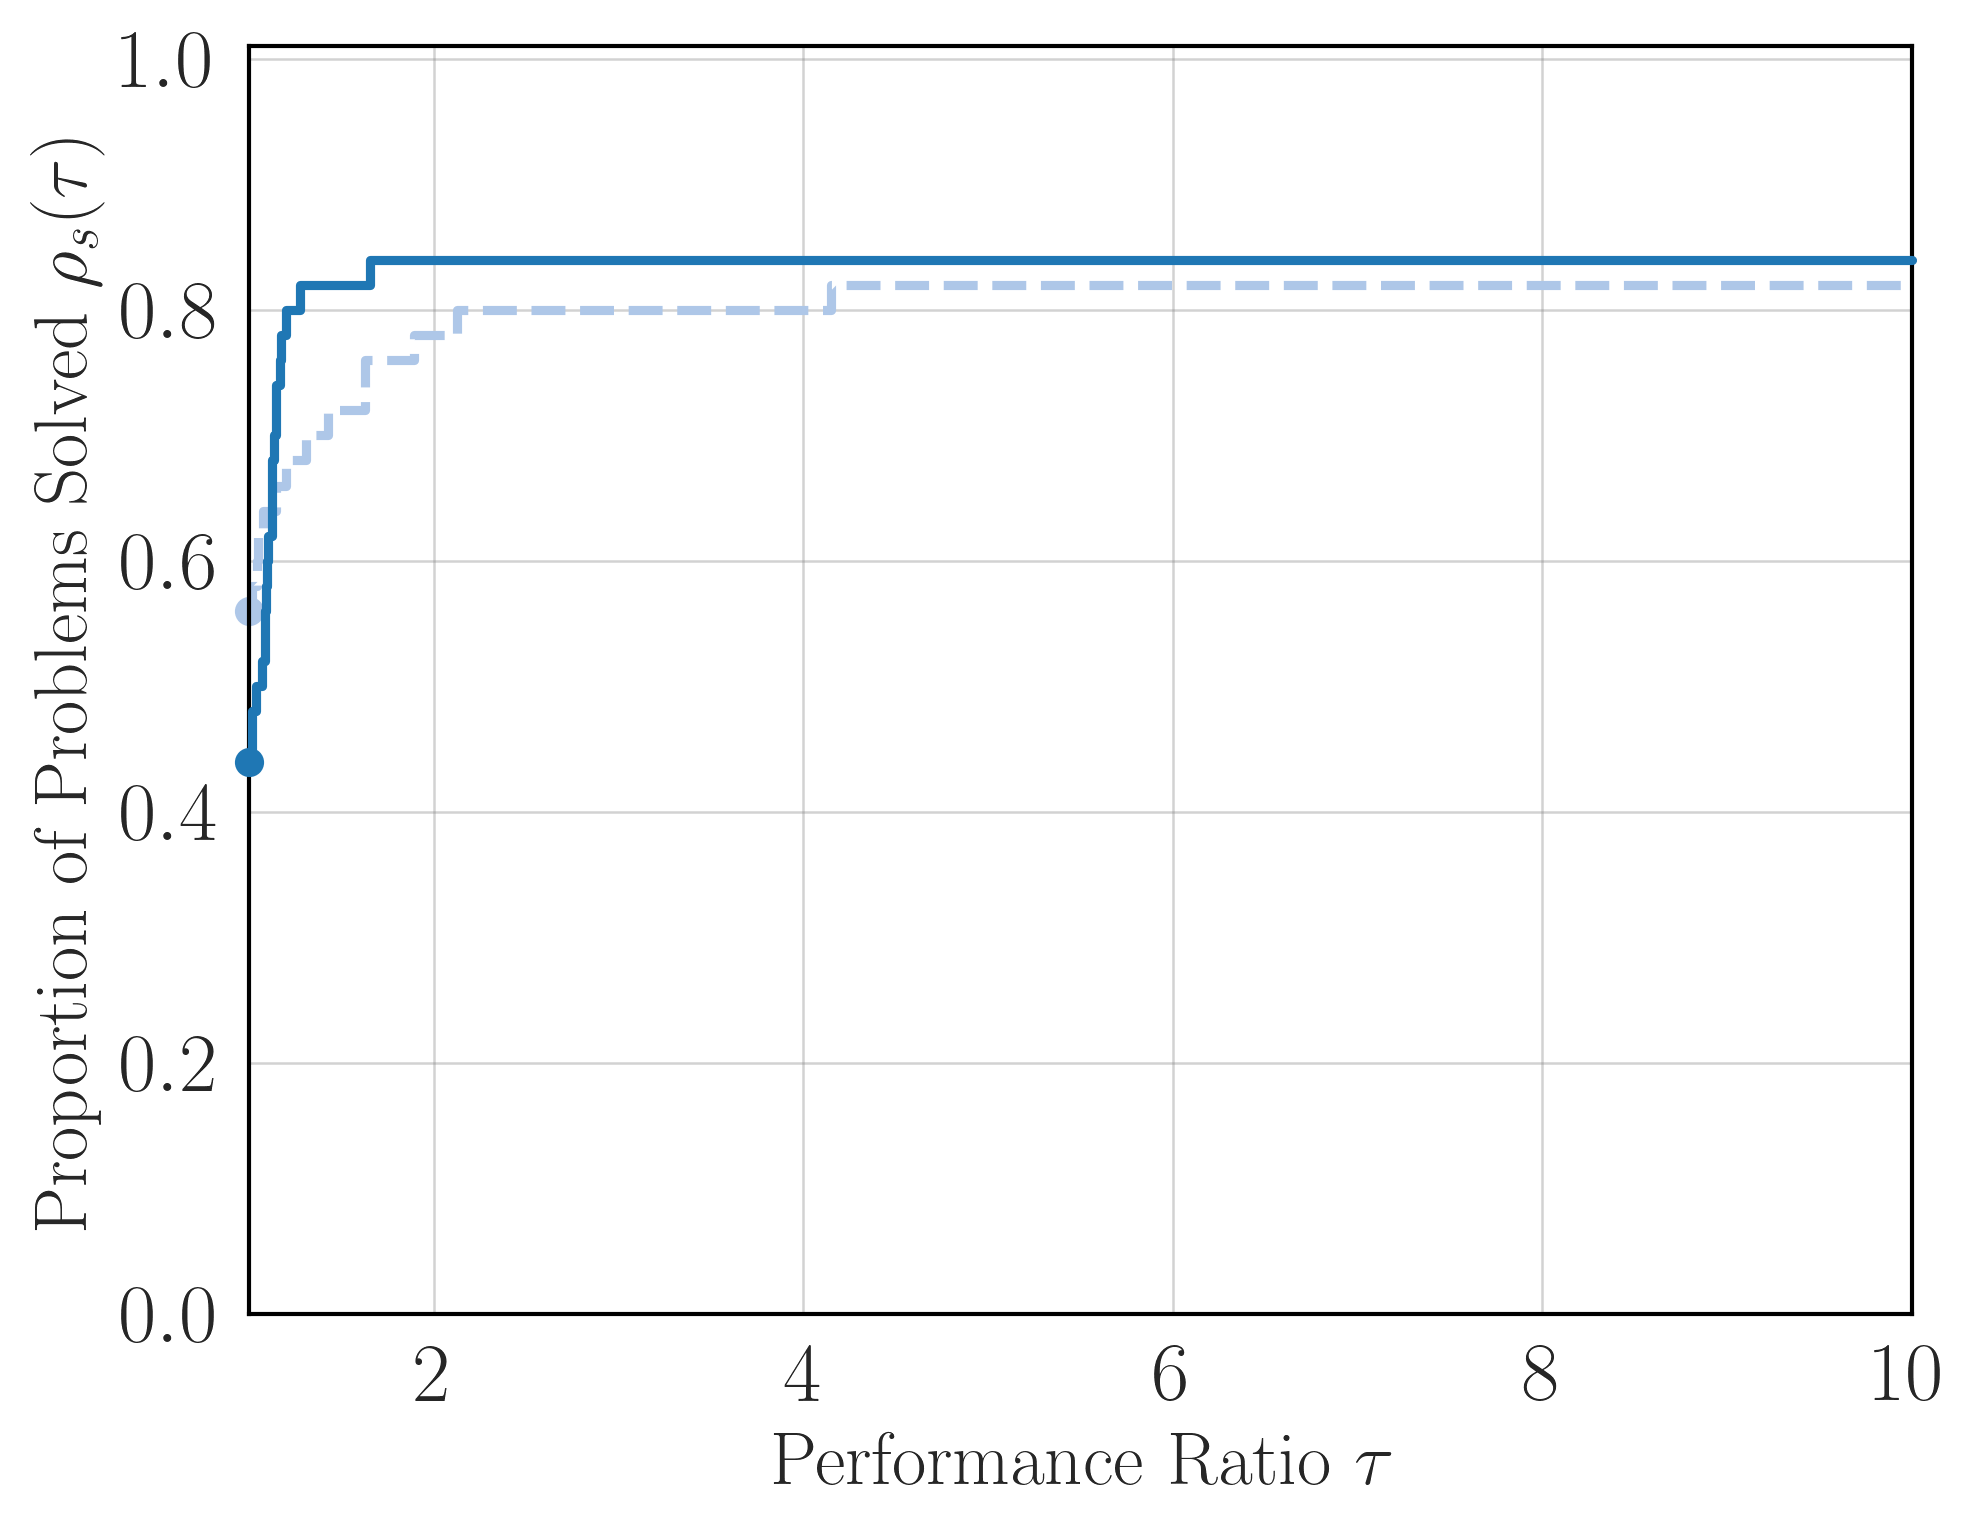

Saved figure to doc/imgs/compare/_dp_eps_over_gtol1e-02.pdf


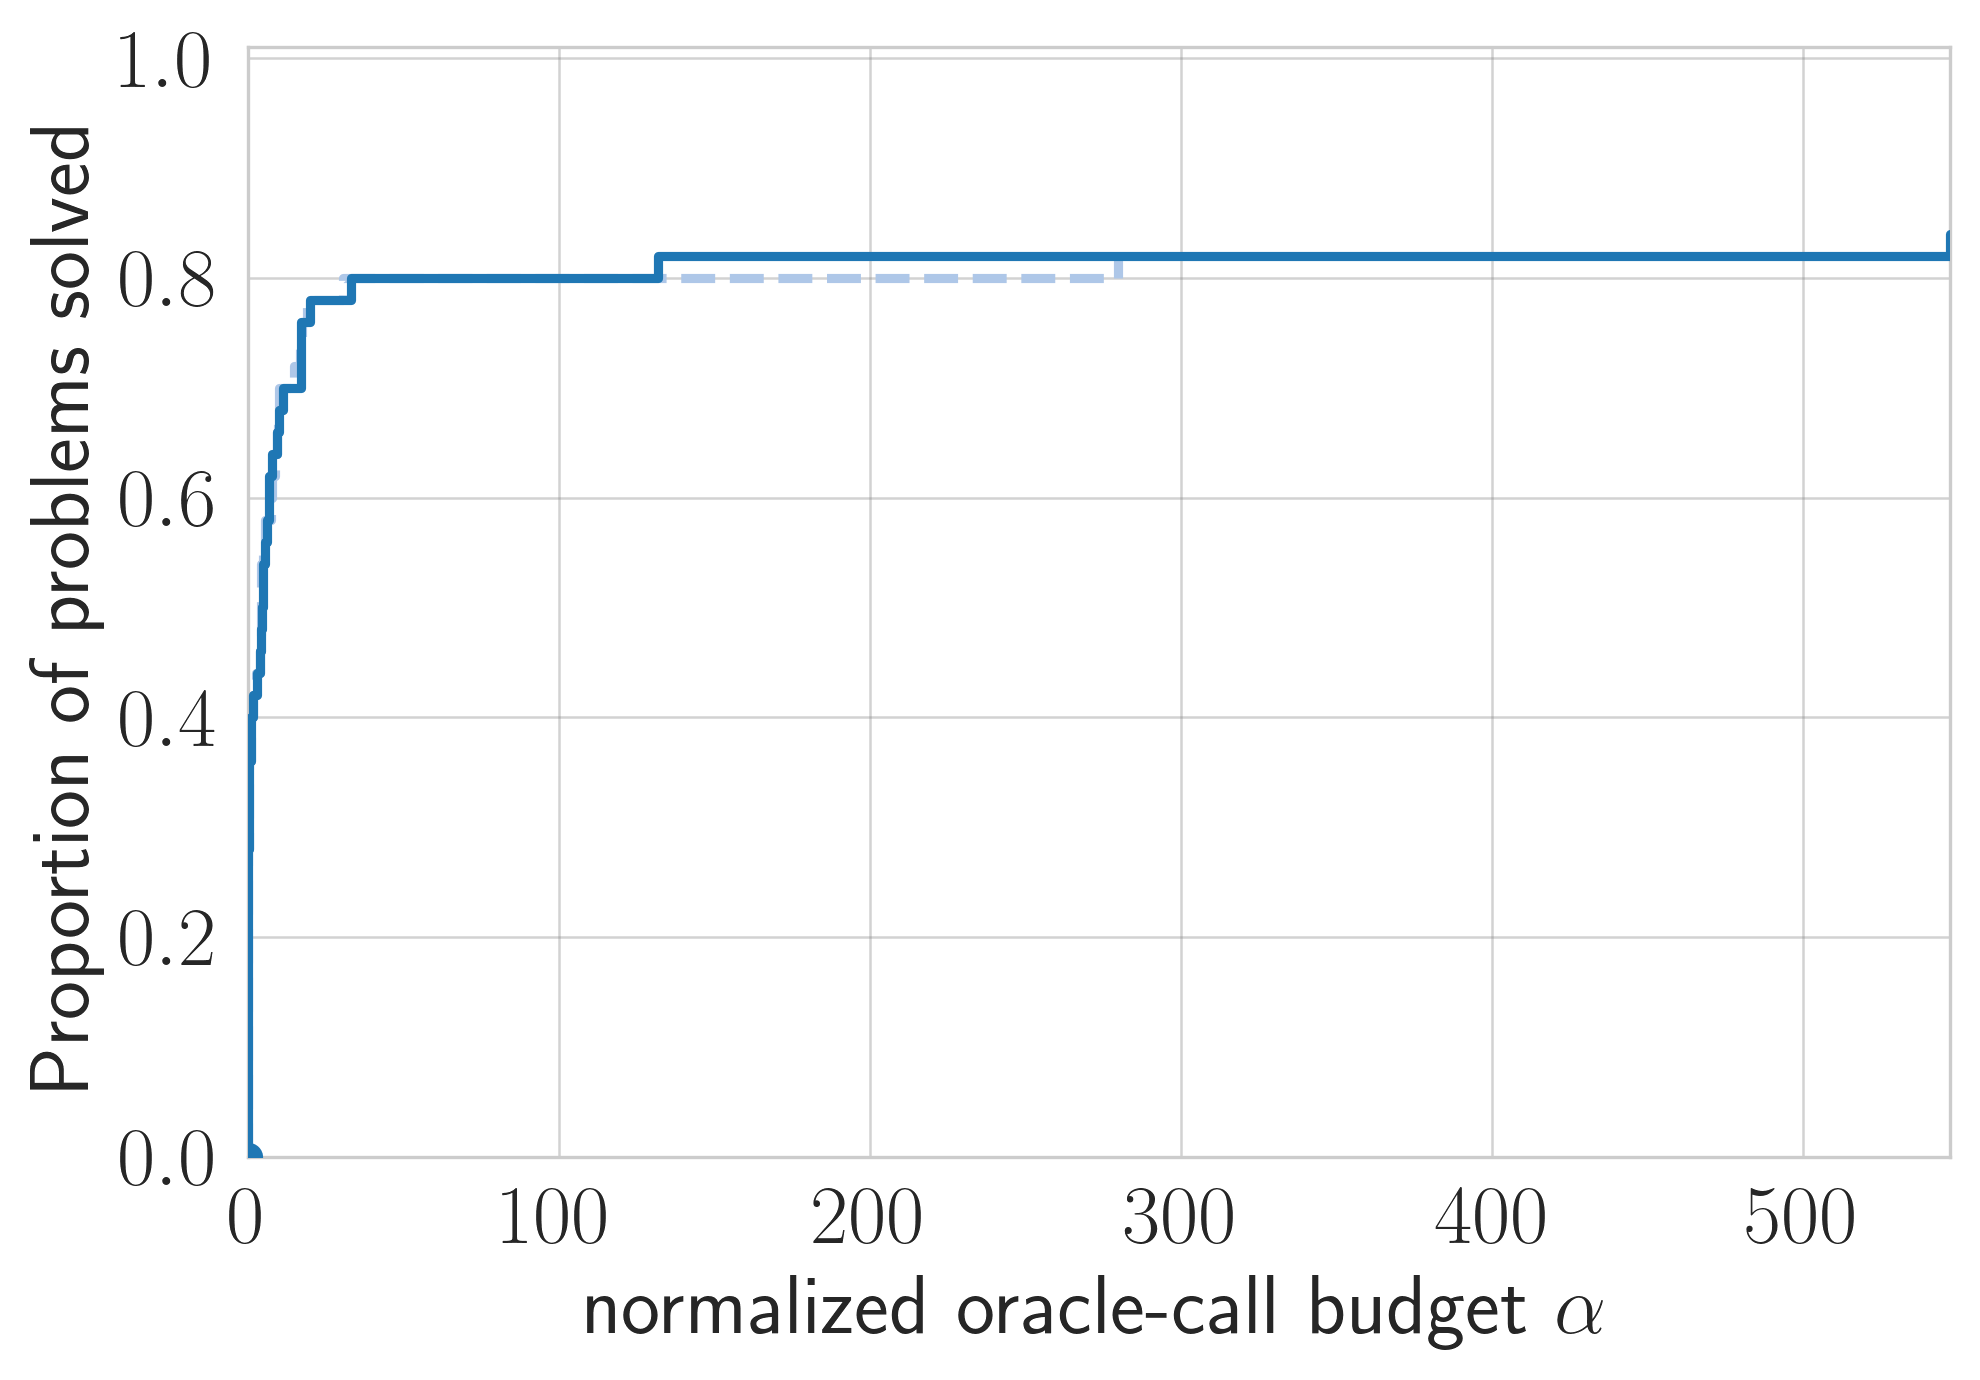

,NTRQN,NTRQN-MS
AKIVA (seed=0),59.0,57.0
ALLINITU (seed=0),23.0,21.0
ARGLINA (seed=0),8.0,8.0
ARGLINB (seed=0),10.0,10.0
ARGLINC (seed=0),10.0,10.0
ARGTRIGLS (seed=0),529.0,471.0
ARWHEAD (seed=0),26.0,28.0
BA-L1LS (seed=0),41.0,43.0
BA-L1SPLS (seed=0),45.0,47.0
BARD (seed=0),18.0,16.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,84.0,44.0
NTRQN-MS,82.0,56.0


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,50,0,50,0,0,8
NTRQN-MS,50,0,50,0,0,9


In [7]:
SCENARIOS_TO_PLOT = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_nominal",
    "eps_over",
]


def display_result_summaries(alg_names, calls, metadata):
    best_calls = calls.min(axis=0)
    fastest = (calls == best_calls) & np.isfinite(best_calls)[None, :]
    display(
        pd.DataFrame(
            {
                "solved (percent)": 100.0 * np.isfinite(calls).mean(axis=1),
                "fastest, ties included (percent)": 100.0 * fastest.mean(axis=1),
            },
            index=alg_names,
        )
    )
    display(summarize_run_metadata(alg_names, metadata))
    restart_summary, ntqn_summary = summarize_diagnostics(alg_names, metadata)
    if not restart_summary.empty:
        display(restart_summary.set_index("method"))
    if not ntqn_summary.empty:
        display(ntqn_summary)


_, ALGORITHM_COLORS, ALGORITHM_LINE_STYLES = get_methods()
ALGORITHM_COLORS["OFFO"] = COLORS["OFFO"]
ALGORITHM_LINE_STYLES["OFFO"] = LINE_STYLES["OFFO"]
for scenario in SCENARIOS_TO_PLOT:
    config = SCENARIOS[scenario]
    for gtol in config["score_gtols"]:
        seeds = get_scenario_seeds(scenario)
        primary_labels = METHODS_TO_RUN or (
            SCENARIO_DEFAULT_LABELS[scenario] - {"NTRQN-Restart"}
        )
        alg_names, calls, instances, dimensions, metadata = load_scenario_results(
            scenario, seeds, gtol, labels=primary_labels
        )
        output_path = None
        if scenario not in {"float64", "float32", "float16", "joint_noise"}:
            gtol_name = f"{gtol:.0e}".replace("+", "")
            output_path = (
                Path("doc/imgs/compare") / f"_pp_{scenario}_gtol{gtol_name}.pdf"
            )
        draw_pp(
            alg_names,
            calls,
            ALGORITHM_COLORS,
            ALGORITHM_LINE_STYLES,
            config["precision"],
            np.float64(max(config["function_noise"], config["gradient_noise"])),
            np.float64(gtol),
            output_path=output_path,
        )
        gtol_name = f"{gtol:.0e}".replace("+", "")
        data_profile_path = (
            Path("doc/imgs/compare") / f"_dp_{scenario}_gtol{gtol_name}.pdf"
        )
        if np.all(np.isfinite(dimensions)):
            draw_data_profile(
                alg_names,
                calls,
                dimensions,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                data_profile_path,
            )
        else:
            print("Skipping data profile because some result metadata lack dimensions.")

        table = pd.DataFrame(calls.T, index=instances, columns=alg_names)
        display(table)

        display_result_summaries(alg_names, calls, metadata)

        if len(seeds) > 1:
            solved_by_seed = []
            for seed in seeds:
                _, seed_calls, _, _, _ = load_scenario_results(
                    scenario, [seed], gtol, labels=primary_labels
                )
                solved_by_seed.append(np.isfinite(seed_calls).mean(axis=1))
            solved_by_seed = np.asarray(solved_by_seed)
            seed_summary = pd.DataFrame(
                {
                    "mean solved fraction": solved_by_seed.mean(axis=0),
                    "std. dev. across seeds": solved_by_seed.std(axis=0, ddof=1),
                },
                index=alg_names,
            )
            display(seed_summary)

        if scenario == "function_only" and METHODS_TO_RUN is None:
            restart_labels = {"NTRQN", "NTRQN-Restart"}
            restart_names, restart_calls, _, restart_dimensions, restart_metadata = (
                load_scenario_results(scenario, seeds, gtol, labels=restart_labels)
            )
            restart_stem = f"function_only_restart_gtol{gtol_name}"
            draw_pp(
                restart_names,
                restart_calls,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                config["precision"],
                np.float64(config["function_noise"]),
                np.float64(gtol),
                output_path=Path("doc/imgs/compare") / f"_pp_{restart_stem}.pdf",
            )
            if np.all(np.isfinite(restart_dimensions)):
                draw_data_profile(
                    restart_names,
                    restart_calls,
                    restart_dimensions,
                    ALGORITHM_COLORS,
                    ALGORITHM_LINE_STYLES,
                    Path("doc/imgs/compare") / f"_dp_{restart_stem}.pdf",
                )
            display_result_summaries(restart_names, restart_calls, restart_metadata)